# 🏠 AI-Based Hostel Complaint Prioritization System
### B.Tech Mini Project — Machine Learning Module

**Objective:** Predict the Priority (High / Medium / Low) of hostel complaints using NLP and Machine Learning.

**Dataset:** 800 hostel complaints with text descriptions and structured features.

---

## 📌 SECTION 1: Import Libraries, Load Dataset & Initial Exploration

In this section, we will:
1. Import all necessary Python libraries
2. Load the dataset from CSV
3. Explore its structure — shape, columns, data types
4. Check for missing values and duplicates
5. Examine the class distribution of our target variable (`Priority`)

### 1.1 — Import All Required Libraries

We organize imports into logical groups:
- **Data handling:** `pandas`, `numpy` — for loading, manipulating, and computing on data.
- **Visualization:** `matplotlib`, `seaborn` — for creating graphs and charts.
- **NLP:** `nltk`, `re` — for text cleaning, stopword removal, and lemmatization.
- **Feature Engineering:** `TfidfVectorizer`, `LabelEncoder`, `ColumnTransformer` — to convert text and categories into numbers.
- **ML Models:** Logistic Regression, Random Forest, Linear SVM, Multinomial Naive Bayes.
- **Evaluation:** Accuracy, Precision, Recall, F1-score, Confusion Matrix.
- **Tuning & Saving:** GridSearchCV for hyperparameter tuning, Joblib for model persistence.

> **Best Practice:** Import everything at the top of the notebook so dependencies are clear at a glance.

In [73]:
# ============================================================
# 1.1  IMPORT ALL REQUIRED LIBRARIES
# ============================================================

# --- Data Handling ---
import pandas as pd                # Tabular data manipulation
import numpy as np                 # Numerical computations

# --- Visualization ---
import matplotlib.pyplot as plt    # Core plotting library
import seaborn as sns              # Statistical visualizations (built on matplotlib)

# --- NLP (Natural Language Processing) ---
import re                          # Regular expressions for text cleaning
import nltk                        # NLP toolkit for stopwords, lemmatization
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# --- Feature Engineering ---
from sklearn.feature_extraction.text import TfidfVectorizer   # Text → numerical features
from sklearn.preprocessing import LabelEncoder                # Encode target labels
from sklearn.compose import ColumnTransformer                 # Combine different feature types
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# --- Machine Learning Models ---
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB

# --- Model Evaluation ---
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix,
                             ConfusionMatrixDisplay)

# --- Hyperparameter Tuning ---
from sklearn.model_selection import GridSearchCV

# --- Model Saving / Loading ---
import joblib

# --- Download NLTK Data (run once) ---
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

# --- Global Settings ---
import warnings
warnings.filterwarnings('ignore')          # Suppress sklearn convergence warnings
sns.set_style('whitegrid')                 # Clean background for all plots
plt.rcParams['figure.dpi'] = 120           # Sharper figures in the notebook

print('[OK] All libraries imported successfully!')

[OK] All libraries imported successfully!


**🔍 Interpretation:**  
If you see `✅ All libraries imported successfully!` with no errors, your environment is ready.  
If any library is missing, install it with `!pip install <library_name>` and re-run the cell.

---
### 1.2 — Load the Dataset

We use `pd.read_csv()` to load the CSV file into a **DataFrame** — a table-like structure where:
- Each **row** is one hostel complaint.
- Each **column** is a feature (attribute) of that complaint.

In [74]:
# ============================================================
# 1.2  LOAD THE DATASET
# ============================================================

# Load the CSV file into a pandas DataFrame
df = pd.read_csv(r'E:\downloads\hostel_complaints_800_final (1).csv')

print(f'[OK] Dataset loaded successfully!')
print(f'   Rows   : {df.shape[0]}')
print(f'   Columns: {df.shape[1]}')
print(df)

[OK] Dataset loaded successfully!
   Rows   : 800
   Columns: 13
    Complaint_ID                                     Complaint_Text  \
0          C0001         Hi, theres cobwebs all over the staircase.   
1          C0002  My washroom door doesnt lock properly because ...   
2          C0003  The milk served at breakfast smelled slightly ...   
3          C0004  Mess timing keeps changing without any notice,...   
4          C0005  Theres cobwebs all over the staircase, doesnt ...   
..           ...                                                ...   
795        C0796  There is a slight rattling sound from the fan ...   
796        C0797  Respected Warden, wifi speed in the corner roo...   
797        C0798  Sir, the door handle in my room feels loose an...   
798        C0799  To whoever is in charge, the dustbin in the co...   
799        C0800  Some students have been playing loud music til...   

    Complaint_Type Block   Floor  Room_No     Category            Duration  \
0   

**🔍 Interpretation:**  
- **800 rows** = 800 individual hostel complaints.  
- **13 columns** = 13 attributes describing each complaint (text + structured data + target label).

In [75]:
df.head()

,Complaint_ID,Complaint_Text,Complaint_Type,Block,Floor,Room_No,Category,Duration,Students_Affected,Support_Count,Priority,Status,Complaint_Date
0,C0001,"Hi, theres cobwebs all over the staircase.",Public,B,First,15,Cleanliness,since this evening,23,2,Low,Resolved,01-05-2026
1,C0002,My washroom door doesnt lock properly because ...,Public,C,First,15,Washroom,since yesterday,1,0,Low,Pending,01-05-2026
2,C0003,The milk served at breakfast smelled slightly ...,Public,C,Ground,4,Mess,since this morning,2,1,High,Pending,01-05-2026
3,C0004,"Mess timing keeps changing without any notice,...",Public,C,Second,23,Mess,since 30 minutes,53,20,Medium,In Progress,01-05-2026
4,C0005,"Theres cobwebs all over the staircase, doesnt ...",Public,B,First,14,Cleanliness,since Monday,37,17,Medium,Pending,01-05-2026


---
### 1.3 — Display the First Few Rows

`df.head()` shows the top 5 rows. This is always the **first thing you should do** after loading data — it gives you a quick visual feel for what each column contains.

In [76]:
# ============================================================
# 1.3  DISPLAY FIRST FEW ROWS
# ============================================================

# Show top 5 rows to get a quick look at the data
df.head()

,Complaint_ID,Complaint_Text,Complaint_Type,Block,Floor,Room_No,Category,Duration,Students_Affected,Support_Count,Priority,Status,Complaint_Date
0,C0001,"Hi, theres cobwebs all over the staircase.",Public,B,First,15,Cleanliness,since this evening,23,2,Low,Resolved,01-05-2026
1,C0002,My washroom door doesnt lock properly because ...,Public,C,First,15,Washroom,since yesterday,1,0,Low,Pending,01-05-2026
2,C0003,The milk served at breakfast smelled slightly ...,Public,C,Ground,4,Mess,since this morning,2,1,High,Pending,01-05-2026
3,C0004,"Mess timing keeps changing without any notice,...",Public,C,Second,23,Mess,since 30 minutes,53,20,Medium,In Progress,01-05-2026
4,C0005,"Theres cobwebs all over the staircase, doesnt ...",Public,B,First,14,Cleanliness,since Monday,37,17,Medium,Pending,01-05-2026


**Observation:**
- The heatmap displays Pearson correlation coefficients between the three numerical features.
- `Students_Affected` and `Support_Count` show a positive correlation (see exact value in the heatmap).
- `Room_No` has near-zero correlation with the other features.

**Interpretation:**
- No feature pair shows extreme correlation (>0.9), so there is no severe multicollinearity among numerical features.
- `Room_No` appears to have no linear relationship with the other numerical features.

**ML Relevance:**
- Both `Students_Affected` and `Support_Count` can be included as features without redundancy.
- `Room_No` is unlikely to be a useful predictor based on this analysis.

**Limitation:**
- This heatmap only measures **linear (Pearson) correlation**. Non-linear relationships, if any, would not be captured.
- Correlation between features does not tell us about their individual predictive power for the target variable.

---
### 1.4 — Dataset Shape

`.shape` returns a tuple `(number_of_rows, number_of_columns)`. This confirms the size of our dataset.

In [77]:
# ============================================================
# 1.4  DATASET SHAPE
# ============================================================

print(f'Dataset Shape: {df.shape}')
print(f'  → {df.shape[0]} complaints (rows)')
print(f'  → {df.shape[1]} features/columns')

Dataset Shape: (800, 13)
  → 800 complaints (rows)
  → 13 features/columns


---
### 1.5 — Column Names

List all column names to verify nothing unexpected was loaded.

In [78]:
# ============================================================
# 1.5  COLUMN NAMES
# ============================================================

print('Column Names:')
print('─' * 40)
for i, col in enumerate(df.columns, 1):
    print(f'  {i:2d}. {col}')

Column Names:
────────────────────────────────────────
   1. Complaint_ID
   2. Complaint_Text
   3. Complaint_Type
   4. Block
   5. Floor
   6. Room_No
   7. Category
   8. Duration
   9. Students_Affected
  10. Support_Count
  11. Priority
  12. Status
  13. Complaint_Date


**🔍 Interpretation:**  
We have 13 columns. Before model training, we will:
- **Drop** `Complaint_ID` (just an identifier, not a feature).
- **Drop** `Status` and `Complaint_Date` (they are operational/metadata, not predictive features — and using `Status` would cause **data leakage** since it is determined *after* priority is assigned).
- **Use** `Complaint_Text` as the primary text feature for TF-IDF.
- **Use** structured columns (`Complaint_Type`, `Block`, `Floor`, `Category`, etc.) as additional features.

---
### 1.6 — Data Types

`.dtypes` tells us how pandas interpreted each column. This matters because:
- `object` = text/string → needs encoding before ML.
- `int64` / `float64` = numbers → can be used directly or scaled.

In [79]:
# ============================================================
# 1.6  DATA TYPES
# ============================================================

print('Data Types:')
print('─' * 40)
print(df.dtypes)
print()
print(f'Summary: {df.dtypes.value_counts().to_dict()}')

Data Types:
────────────────────────────────────────
Complaint_ID           str
Complaint_Text         str
Complaint_Type         str
Block                  str
Floor                  str
Room_No              int64
Category               str
Duration               str
Students_Affected    int64
Support_Count        int64
Priority               str
Status                 str
Complaint_Date         str
dtype: object

Summary: {<StringDtype(storage='python', na_value=nan)>: 10, dtype('int64'): 3}


**🔍 Interpretation:**  
- Most columns are `object` (text/categorical) → they will need **encoding** (OneHotEncoding or TF-IDF).
- `Room_No`, `Students_Affected`, `Support_Count` are `int64` (numerical) → can be used directly or **scaled**.
- `Complaint_Date` is loaded as `object` (string) — we won't use it for training, so no need to parse it.

---
### 1.7 — Missing Values Check

Missing values can break ML models or bias predictions. We **must** check and handle them before training.

> **Best Practice:** Always check for nulls immediately after loading data.

In [80]:
# ============================================================
# 1.7  MISSING VALUES
# ============================================================

missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)

# Combine into a neat table
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
})

print('Missing Values per Column:')
print('─' * 45)
print(missing_df)
print()
print(f'Total missing values in entire dataset: {df.isnull().sum().sum()}')

Missing Values per Column:
─────────────────────────────────────────────
                   Missing Count  Missing %
Complaint_ID                   0        0.0
Complaint_Text                 0        0.0
Complaint_Type                 0        0.0
Block                          0        0.0
Floor                          0        0.0
Room_No                        0        0.0
Category                       0        0.0
Duration                       0        0.0
Students_Affected              0        0.0
Support_Count                  0        0.0
Priority                       0        0.0
Status                         0        0.0
Complaint_Date                 0        0.0

Total missing values in entire dataset: 0


**🔍 Interpretation:**  
- If all counts are **0** → the dataset is clean with no missing values. No imputation needed.
- If any column has missing values → we would need to decide: drop those rows, or fill (impute) with the mode/median.

---
### 1.8 — Duplicate Rows Check

Duplicate rows can inflate model performance artificially. If the same complaint appears in both training and test sets, the model "memorizes" instead of "learning".

> **Best Practice:** Check for and remove exact duplicates.

In [81]:
# ============================================================
# 1.8  DUPLICATE ROWS
# ============================================================

duplicate_count = df.duplicated().sum()

print(f'Number of exact duplicate rows: {duplicate_count}')

if duplicate_count > 0:
    print(f'[!]️  Found {duplicate_count} duplicates. Removing them...')
    df = df.drop_duplicates().reset_index(drop=True)
    print(f'[OK] After removal: {df.shape[0]} rows remain.')
else:
    print('[OK] No duplicate rows found. Dataset is clean!')

Number of exact duplicate rows: 0
[OK] No duplicate rows found. Dataset is clean!


**🔍 Interpretation:**  
- **0 duplicates** means every complaint in the dataset is unique — exactly what we want.
- If duplicates were found, the code automatically removes them and resets the row index.

---
### 1.9 — Class Distribution (Target Variable: `Priority`)

This is one of the **most important checks** in any classification problem.

**Why?** If one class (e.g., "Low") has 700 samples and another ("High") has only 50, the model will be **biased** toward predicting "Low" — because that is the easiest way to maximize accuracy. This is called **class imbalance**.

> **Best Practice:** Always visualize the target distribution before training.

Target Variable — Priority Distribution:
─────────────────────────────────────────────
          Count  Percentage (%)
Priority                       
Medium      310           38.75
High        245           30.63
Low         229           28.62
Critical     16            2.00



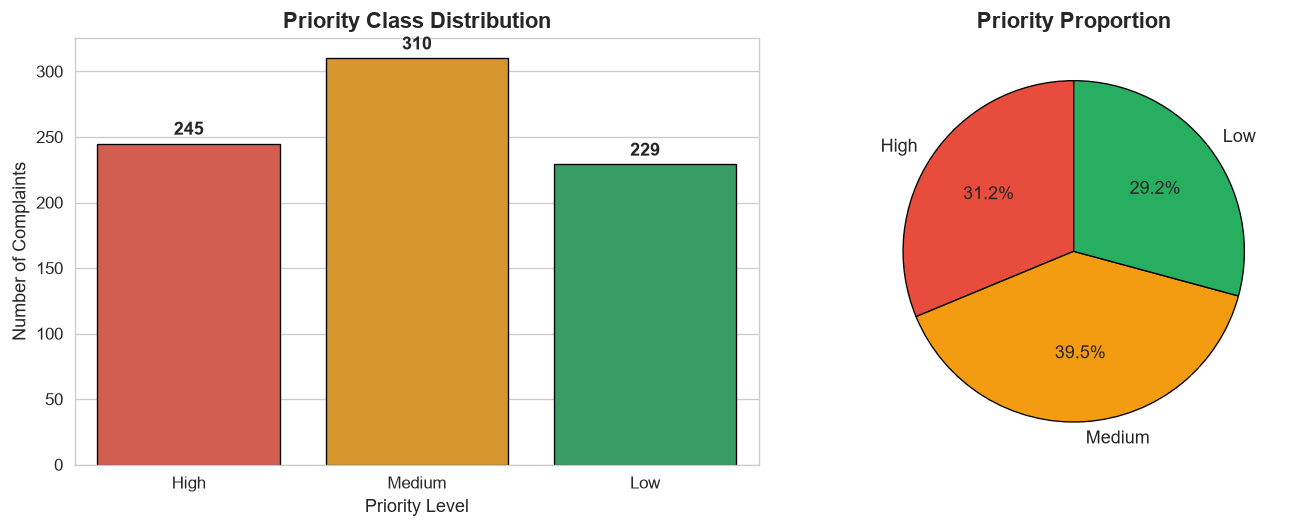

[chart] Chart saved as class_distribution.png


In [82]:
# ============================================================
# 1.9  CLASS DISTRIBUTION OF TARGET VARIABLE
# ============================================================

# Count and percentage of each Priority class
class_counts = df['Priority'].value_counts()
class_pct = df['Priority'].value_counts(normalize=True).mul(100).round(2)

class_dist = pd.DataFrame({
    'Count': class_counts,
    'Percentage (%)': class_pct
})

print('Target Variable — Priority Distribution:')
print('─' * 45)
print(class_dist)
print()

# --- Visualization ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Bar chart
colors = ['#e74c3c', '#f39c12', '#27ae60']   # Red=High, Orange=Medium, Green=Low
order = ['High', 'Medium', 'Low']
sns.countplot(data=df, x='Priority', order=order, palette=colors, ax=axes[0],
              edgecolor='black', linewidth=0.8)
axes[0].set_title('Priority Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Priority Level', fontsize=11)
axes[0].set_ylabel('Number of Complaints', fontsize=11)

# Add count labels on top of each bar
for container in axes[0].containers:
    axes[0].bar_label(container, fontsize=11, fontweight='bold', padding=3)

# Pie chart
class_counts_ordered = class_counts.reindex(order)
axes[1].pie(class_counts_ordered, labels=order, autopct='%1.1f%%',
            colors=colors, startangle=90, textprops={'fontsize': 11},
            wedgeprops={'edgecolor': 'black', 'linewidth': 0.8})
axes[1].set_title('Priority Proportion', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('class_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

print('[chart] Chart saved as class_distribution.png')

**🔍 Interpretation:**

Look at the bar chart and percentages:

- If the three classes (High, Medium, Low) are **roughly balanced** (each ~25–40%), our models should learn all three classes fairly well.
- If one class dominates (>50%), we may need **stratified splitting** or **class-weight balancing** later to prevent bias.

In our dataset, the distribution is reasonably balanced — which is ideal for a multi-class classification task.

> **Key takeaway:** We will still use `stratify=y` during train-test split to maintain this proportion in both sets.

---
### 1.10 — Quick Statistical Summary

`.describe()` shows summary statistics (mean, std, min, max, quartiles) for numerical columns. This helps spot **outliers** or **unusual ranges**.

In [83]:
# ============================================================
# 1.10  STATISTICAL SUMMARY (NUMERICAL COLUMNS)
# ============================================================

print('Statistical Summary of Numerical Columns:')
print('─' * 50)
df.describe()

Statistical Summary of Numerical Columns:
──────────────────────────────────────────────────


,Room_No,Students_Affected,Support_Count
count,800.000000,800.000000,800.000000
mean,20.753750,21.537500,7.573750
std,12.708658,26.516882,10.220574
min,1.000000,1.000000,0.000000
25%,11.000000,2.000000,0.000000
50%,20.000000,15.000000,3.000000
75%,29.000000,30.000000,11.000000
max,50.000000,138.000000,65.000000


**🔍 Interpretation:**

| Metric | What to look for |
|---|---|
| `mean` vs `50%` (median) | If they differ a lot → data is **skewed** |
| `min` and `max` | Check for impossible values (e.g., negative room numbers) |
| `std` (standard deviation) | High std → large spread; may benefit from **scaling** |
| `Students_Affected` | Ranges from 1 to 100+; high-impact complaints likely get higher priority |
| `Support_Count` | Upvotes from peers — a strong signal for priority |

---
### 1.11 — Unique Values per Column

This helps us understand the **cardinality** (number of unique values) of each column, which is crucial for deciding encoding strategies.

In [84]:
# ============================================================
# 1.11  UNIQUE VALUES PER COLUMN
# ============================================================

print('Unique Values per Column:')
print('─' * 45)
for col in df.columns:
    print(f'  {col:25s} → {df[col].nunique():4d} unique values')

print()
print('Unique values in key categorical columns:')
print('─' * 45)
for col in ['Complaint_Type', 'Block', 'Floor', 'Category', 'Priority', 'Status']:
    print(f'  {col:20s} → {df[col].unique().tolist()}')

Unique Values per Column:
─────────────────────────────────────────────
  Complaint_ID              →  800 unique values
  Complaint_Text            →  800 unique values
  Complaint_Type            →    2 unique values
  Block                     →    3 unique values
  Floor                     →    5 unique values
  Room_No                   →   50 unique values
  Category                  →   22 unique values
  Duration                  →   31 unique values
  Students_Affected         →   99 unique values
  Support_Count             →   49 unique values
  Priority                  →    4 unique values
  Status                    →    4 unique values
  Complaint_Date            →  157 unique values

Unique values in key categorical columns:
─────────────────────────────────────────────
  Complaint_Type       → ['Public', 'Private']
  Block                → ['B', 'C', 'A']
  Floor                → ['First', 'Ground', 'Second', 'Fourth', 'Third']
  Category             → ['Cleanliness',

**Observation:**
- The heatmap shows the count of complaints for each Category-Priority combination.
- Some categories have their complaints concentrated in specific priority levels, while others are more evenly distributed.
- Refer to the heatmap for exact counts per cell.

**Interpretation:**
- The non-uniform distribution of priorities across categories indicates an association between `Category` and `Priority`.
- Certain categories tend to appear more frequently with certain priority levels.

**ML Relevance:**
- This association suggests `Category` is likely a strong predictive feature for priority classification.

**Limitation:**
- We observe an association, not causation. The reason *why* certain categories tend to get certain priorities is not determinable from the data alone.
- Categories with very few samples in some priority levels may be harder for the model to classify correctly.

---
## 📌 SECTION 2: Exploratory Data Analysis (EDA)

EDA is the process of **visually and statistically examining** data before building models. It helps us:
1. Understand distributions and relationships between features
2. Spot patterns that might help the model
3. Identify potential issues (outliers, skewness, imbalance)

> **Best Practice:** Always perform EDA before feature engineering — it guides your decisions.

---
### 2.1 — Complaint Category Distribution

Which types of complaints are most common? This tells us what problems students face most frequently.

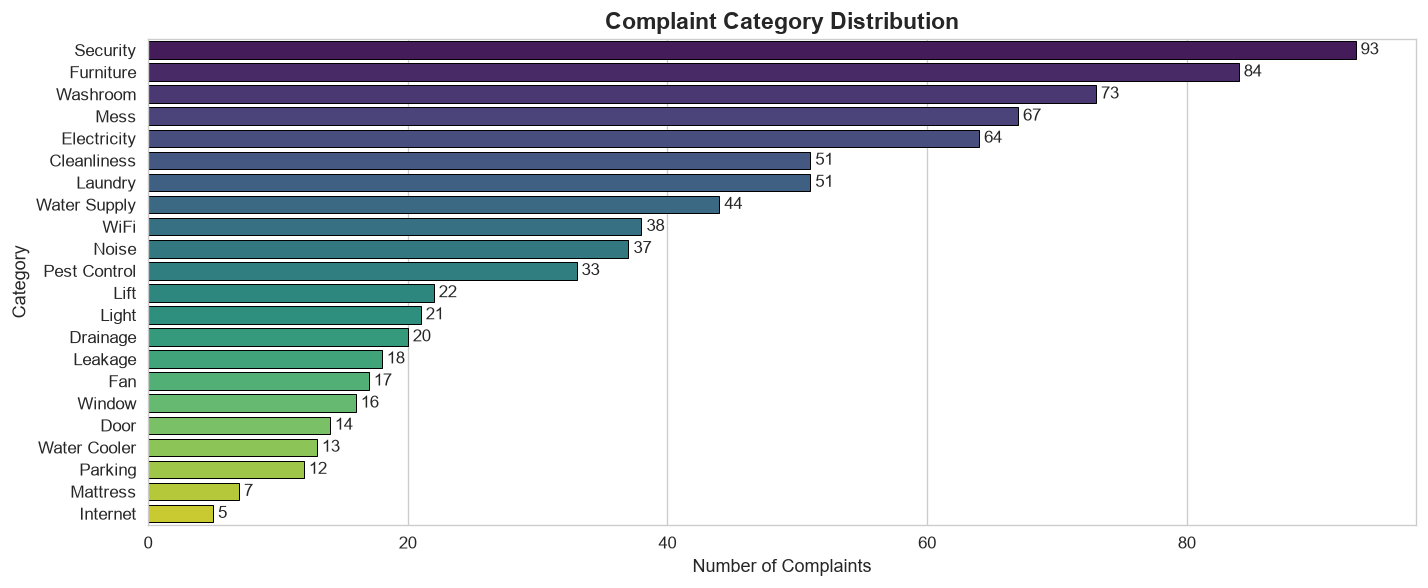


Category Distribution (Count + Percentage):
              Count  Percentage (%)
Category                           
Security         93            11.6
Furniture        84            10.5
Washroom         73             9.1
Mess             67             8.4
Electricity      64             8.0
Cleanliness      51             6.4
Laundry          51             6.4
Water Supply     44             5.5
WiFi             38             4.8
Noise            37             4.6
Pest Control     33             4.1
Lift             22             2.8
Light            21             2.6
Drainage         20             2.5
Leakage          18             2.2
Fan              17             2.1
Window           16             2.0
Door             14             1.8
Water Cooler     13             1.6
Parking          12             1.5
Mattress          7             0.9
Internet          5             0.6


In [85]:
# ============================================================
# 2.1  COMPLAINT CATEGORY DISTRIBUTION
# ============================================================

fig, ax = plt.subplots(figsize=(12, 5))

# Order categories by frequency (most common first)
category_order = df['Category'].value_counts().index

sns.countplot(data=df, y='Category', order=category_order,
              palette='viridis', edgecolor='black', linewidth=0.6, ax=ax)

ax.set_title('Complaint Category Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Complaints', fontsize=11)
ax.set_ylabel('Category', fontsize=11)

# Add count labels at the end of each bar
for container in ax.containers:
    ax.bar_label(container, fontsize=10, padding=3)

plt.tight_layout()
plt.savefig('eda_category_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

# Show counts AND percentages
cat_counts = df['Category'].value_counts()
cat_pct = df['Category'].value_counts(normalize=True).mul(100).round(1)
cat_summary = pd.DataFrame({'Count': cat_counts, 'Percentage (%)': cat_pct})
print('\nCategory Distribution (Count + Percentage):')
print(cat_summary)

**🔍 Insight:**
- **Observation:** The bar chart shows the frequency of each complaint category. Refer to the chart above for exact counts.
- The categories with the highest counts represent the most reported issues in the dataset.
- Categories with fewer complaints have fewer training samples, which may affect model performance for those classes.
- **ML Relevance:** The model will have more training examples for frequent categories, which may lead to better prediction accuracy for those classes.
- **Limitation:** We cannot conclude *why* certain categories are more frequent from this data alone.

---
### 2.2 — Complaint Type Distribution (Public vs Private)

Is the complaint visible to everyone (Public) or only to the warden (Private)? This might influence priority.

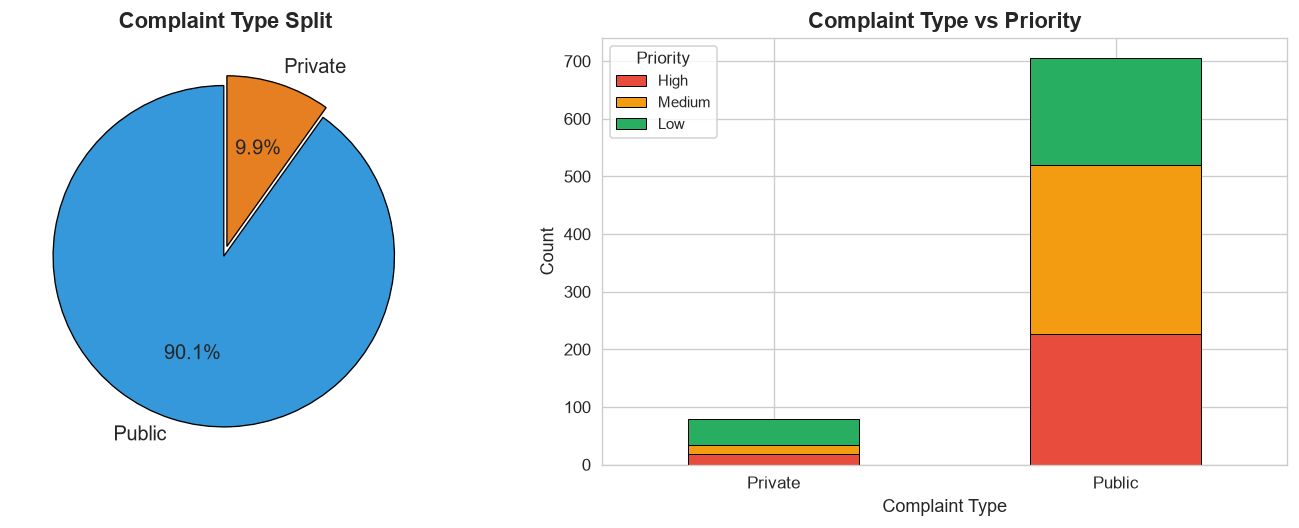

Complaint Type Counts:
  Public: 721 (90.1%)
  Private: 79 (9.9%)

Crosstab - Complaint Type vs Priority (counts):
Priority        High  Medium  Low
Complaint_Type                   
Private           19      16   44
Public           226     294  185

Crosstab - Complaint Type vs Priority (row percentages):
Priority        High  Medium   Low
Complaint_Type                    
Private         24.1    20.3  55.7
Public          32.1    41.7  26.2


In [86]:
# ============================================================
# 2.2  COMPLAINT TYPE: PUBLIC vs PRIVATE
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# --- Pie Chart ---
type_counts = df['Complaint_Type'].value_counts()
colors_type = ['#3498db', '#e67e22']
axes[0].pie(type_counts, labels=type_counts.index, autopct='%1.1f%%',
            colors=colors_type, startangle=90, textprops={'fontsize': 12},
            wedgeprops={'edgecolor': 'black', 'linewidth': 0.8},
            explode=[0.03, 0.03])
axes[0].set_title('Complaint Type Split', fontsize=13, fontweight='bold')

# --- Stacked Bar: Complaint Type vs Priority ---
ct_priority = pd.crosstab(df['Complaint_Type'], df['Priority'])
ct_priority = ct_priority[['High', 'Medium', 'Low']]  # Reorder columns
ct_priority.plot(kind='bar', stacked=True, ax=axes[1],
                 color=['#e74c3c', '#f39c12', '#27ae60'],
                 edgecolor='black', linewidth=0.6)
axes[1].set_title('Complaint Type vs Priority', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Complaint Type', fontsize=11)
axes[1].set_ylabel('Count', fontsize=11)
axes[1].legend(title='Priority', fontsize=9)
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('eda_complaint_type.png', bbox_inches='tight', dpi=150)
plt.show()

# Print counts and percentages
print('Complaint Type Counts:')
for t in type_counts.index:
    print(f'  {t}: {type_counts[t]} ({type_counts[t]/len(df)*100:.1f}%)')

print('\nCrosstab - Complaint Type vs Priority (counts):')
print(ct_priority)
print('\nCrosstab - Complaint Type vs Priority (row percentages):')
print(ct_priority.div(ct_priority.sum(axis=1), axis=0).mul(100).round(1))

**Observation:**
- The pie chart shows the proportion of Public vs Private complaints (see percentages above).
- The stacked bar chart shows how priority is distributed within each complaint type.
- The row-percentage crosstab shows the exact priority breakdown within each type.

**Interpretation:**
- Public and Private complaints have different priority distributions, as seen in the crosstab percentages.
- This difference suggests the complaint type is associated with priority.

**ML Relevance:**
- Since the priority distribution differs between Public and Private complaints, `Complaint_Type` may be a useful feature for the model.

**Limitation:**
- The imbalance between Public and Private counts means the model has fewer training examples for the minority class.
- We cannot determine from the data *why* the priority distributions differ between types.

---
### 2.3 — Block and Floor Distribution

Which hostel blocks and floors generate the most complaints? Are there hotspots?

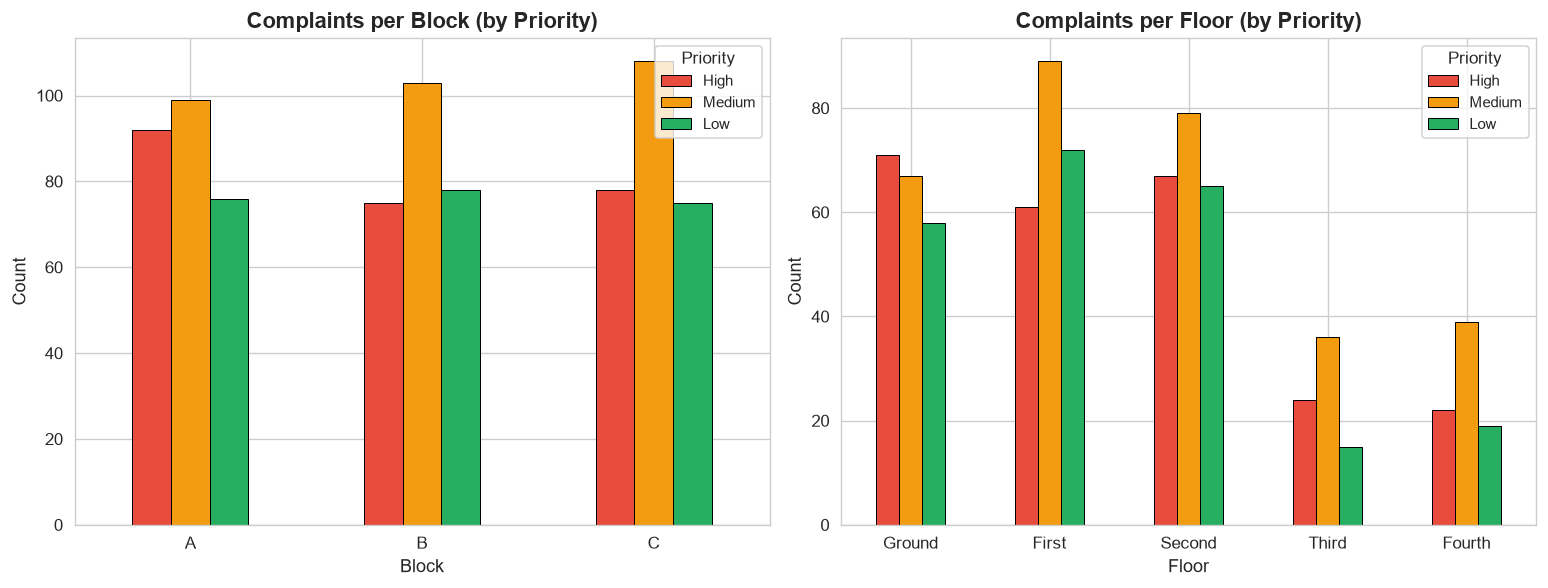

In [87]:
# ============================================================
# 2.3  BLOCK AND FLOOR DISTRIBUTION
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Block Distribution with Priority breakdown ---
ct_block = pd.crosstab(df['Block'], df['Priority'])
ct_block = ct_block[['High', 'Medium', 'Low']]
ct_block.plot(kind='bar', ax=axes[0],
              color=['#e74c3c', '#f39c12', '#27ae60'],
              edgecolor='black', linewidth=0.6)
axes[0].set_title('Complaints per Block (by Priority)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Block', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].legend(title='Priority', fontsize=9)
axes[0].tick_params(axis='x', rotation=0)

# --- Floor Distribution with Priority breakdown ---
floor_order = ['Ground', 'First', 'Second', 'Third', 'Fourth']
ct_floor = pd.crosstab(df['Floor'], df['Priority'])
ct_floor = ct_floor[['High', 'Medium', 'Low']]
ct_floor = ct_floor.reindex(floor_order, fill_value=0)
ct_floor.plot(kind='bar', ax=axes[1],
              color=['#e74c3c', '#f39c12', '#27ae60'],
              edgecolor='black', linewidth=0.6)
axes[1].set_title('Complaints per Floor (by Priority)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Floor', fontsize=11)
axes[1].set_ylabel('Count', fontsize=11)
axes[1].legend(title='Priority', fontsize=9)
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('eda_block_floor.png', bbox_inches='tight', dpi=150)
plt.show()

**Observation:**
- The bar charts show the number of complaints per Block and per Floor, broken down by priority.
- Refer to the charts above for exact counts.

**Interpretation:**
- The complaint counts vary across blocks and floors, but the variation pattern can only be described, not explained, from this data.

**ML Relevance:**
- Block and Floor provide location-based context. Whether they are useful predictors of priority will be determined by the model's performance.

**Limitation:**
- The dataset does not contain the number of rooms per floor, occupancy rates, or any infrastructure information. Therefore, we **cannot determine why** certain blocks or floors have more or fewer complaints.

---
### 2.4 — Numerical Features Distribution

Let's examine the distribution of `Students_Affected` and `Support_Count` — these are likely **strong predictors** of priority.

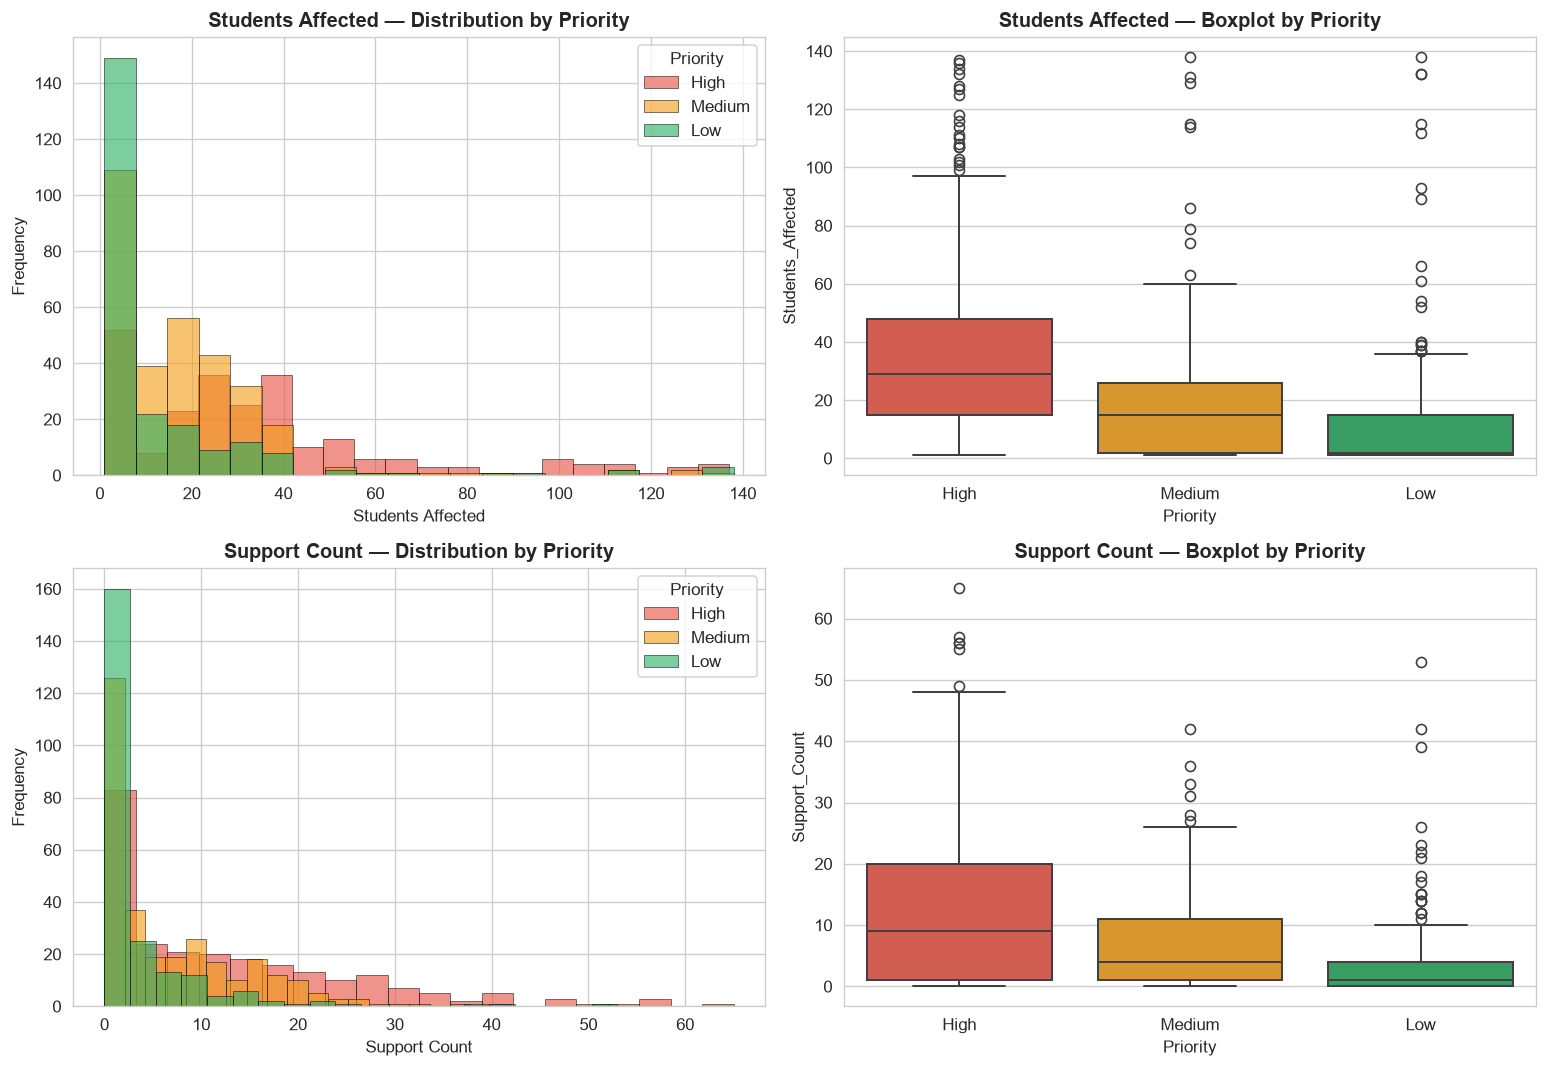

In [88]:
# ============================================================
# 2.4  NUMERICAL FEATURES: DISTRIBUTIONS & BOXPLOTS
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

priority_order = ['High', 'Medium', 'Low']
colors_p = ['#e74c3c', '#f39c12', '#27ae60']

# --- Students_Affected: Histogram ---
for i, priority in enumerate(priority_order):
    subset = df[df['Priority'] == priority]['Students_Affected']
    axes[0, 0].hist(subset, bins=20, alpha=0.6, label=priority,
                    color=colors_p[i], edgecolor='black', linewidth=0.5)
axes[0, 0].set_title('Students Affected — Distribution by Priority', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Students Affected')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].legend(title='Priority')

# --- Students_Affected: Boxplot by Priority ---
sns.boxplot(data=df, x='Priority', y='Students_Affected', order=priority_order,
            palette=colors_p, ax=axes[0, 1], linewidth=1.2)
axes[0, 1].set_title('Students Affected — Boxplot by Priority', fontsize=12, fontweight='bold')

# --- Support_Count: Histogram ---
for i, priority in enumerate(priority_order):
    subset = df[df['Priority'] == priority]['Support_Count']
    axes[1, 0].hist(subset, bins=20, alpha=0.6, label=priority,
                    color=colors_p[i], edgecolor='black', linewidth=0.5)
axes[1, 0].set_title('Support Count — Distribution by Priority', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Support Count')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].legend(title='Priority')

# --- Support_Count: Boxplot by Priority ---
sns.boxplot(data=df, x='Priority', y='Support_Count', order=priority_order,
            palette=colors_p, ax=axes[1, 1], linewidth=1.2)
axes[1, 1].set_title('Support Count — Boxplot by Priority', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('eda_numerical_features.png', bbox_inches='tight', dpi=150)
plt.show()

**Observation:**
- The histograms show the distribution of `Students_Affected` and `Support_Count` for each priority level.
- The boxplots show the median, interquartile range, and outliers for each priority class.
- High-priority complaints have visibly higher medians and wider ranges for both features compared to Low-priority.

**Interpretation:**
- There is a clear association between higher `Students_Affected` / `Support_Count` values and higher priority.
- Both features appear right-skewed (many small values, few large ones), which is common for count-based data.

**ML Relevance:**
- The visible separation in distributions across priority levels suggests these could be strong numerical predictors. The model will quantify their actual importance during training.

**Limitation:**
- Association does not imply causation. These features are correlated with priority in the dataset, but we cannot conclude they *cause* a certain priority level.
- The right-skewness may benefit from scaling or transformation for certain algorithms.

---
### 2.5 — Correlation Heatmap (Numerical Features)

A correlation heatmap shows how strongly numerical features are related to each other. Values range from **-1** (strong negative) to **+1** (strong positive).

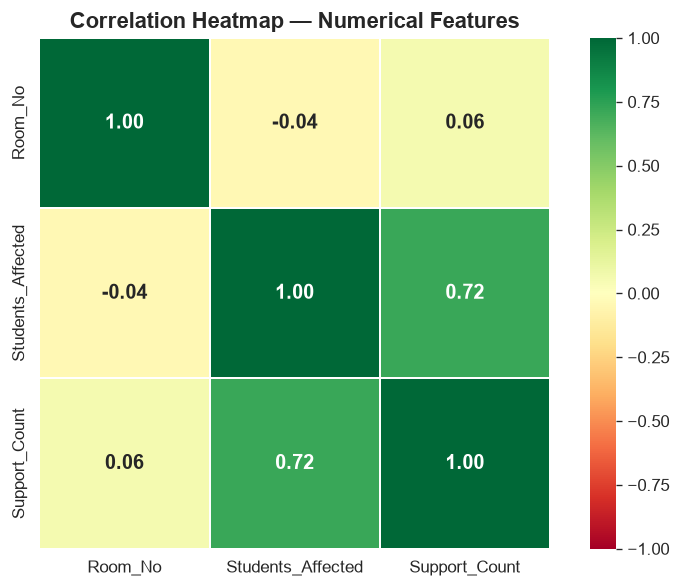

Correlation Matrix:
                   Room_No  Students_Affected  Support_Count
Room_No              1.000             -0.043          0.062
Students_Affected   -0.043              1.000          0.717
Support_Count        0.062              0.717          1.000


In [89]:
# ============================================================
# 2.5  CORRELATION HEATMAP
# ============================================================

# Select only numerical columns for correlation
numerical_cols = df[['Room_No', 'Students_Affected', 'Support_Count']]

fig, ax = plt.subplots(figsize=(7, 5))
corr_matrix = numerical_cols.corr()

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=1, linecolor='white',
            square=True, ax=ax, vmin=-1, vmax=1,
            annot_kws={'fontsize': 12, 'fontweight': 'bold'})

ax.set_title('Correlation Heatmap — Numerical Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_correlation_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()

print('Correlation Matrix:')
print(corr_matrix.round(3))

**🔍 Insight:**
- **Observation:** `Students_Affected` and `Support_Count` show a positive correlation (refer to the heatmap for the exact value).
- **Observation:** `Room_No` has near-zero correlation with the other numerical features, suggesting it has no linear relationship with them.
- No feature pair shows correlation above 0.9, so there is **no severe multicollinearity** among numerical features.
- **ML Relevance:** The absence of extreme multicollinearity means we can include both numerical features without one being redundant.
- **Limitation:** This heatmap only measures **linear correlation**. Non-linear relationships, if any, would not be captured here.

---
### 2.6 — Category vs Priority Heatmap

Which complaint categories tend to be High, Medium, or Low priority? This is a crucial insight for understanding the data.

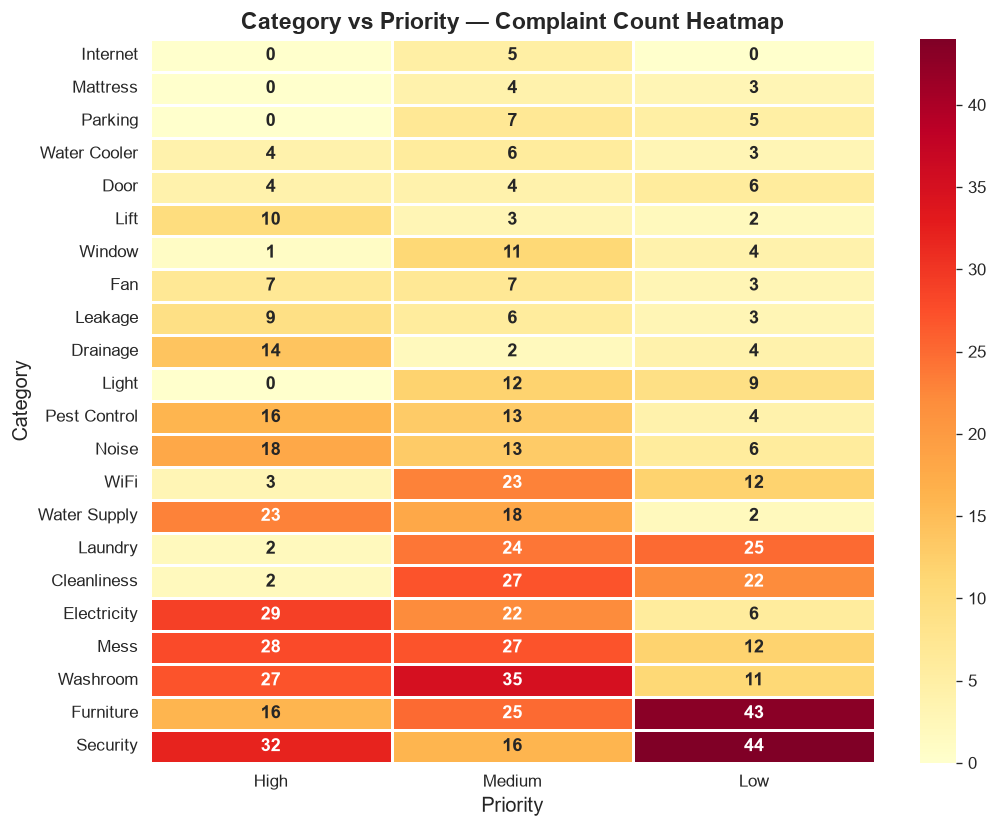


Category vs Priority Crosstab:
Priority      High  Medium  Low
Category                       
Internet         0       5    0
Mattress         0       4    3
Parking          0       7    5
Water Cooler     4       6    3
Door             4       4    6
Lift            10       3    2
Window           1      11    4
Fan              7       7    3
Leakage          9       6    3
Drainage        14       2    4
Light            0      12    9
Pest Control    16      13    4
Noise           18      13    6
WiFi             3      23   12
Water Supply    23      18    2
Laundry          2      24   25
Cleanliness      2      27   22
Electricity     29      22    6
Mess            28      27   12
Washroom        27      35   11
Furniture       16      25   43
Security        32      16   44


In [90]:
# ============================================================
# 2.6  CATEGORY vs PRIORITY HEATMAP
# ============================================================

# Create crosstab of Category vs Priority
ct_cat_priority = pd.crosstab(df['Category'], df['Priority'])
ct_cat_priority = ct_cat_priority[['High', 'Medium', 'Low']]

# Sort by total complaints (most common first)
ct_cat_priority = ct_cat_priority.loc[ct_cat_priority.sum(axis=1).sort_values(ascending=True).index]

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(ct_cat_priority, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=0.8, linecolor='white', ax=ax,
            annot_kws={'fontsize': 11, 'fontweight': 'bold'})
ax.set_title('Category vs Priority — Complaint Count Heatmap', fontsize=14, fontweight='bold')
ax.set_xlabel('Priority', fontsize=12)
ax.set_ylabel('Category', fontsize=12)

plt.tight_layout()
plt.savefig('eda_category_priority_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()

print('\nCategory vs Priority Crosstab:')
print(ct_cat_priority)

**🔍 Insight:**
- **Observation:** The heatmap shows the count of complaints for each Category-Priority combination. Certain categories have higher counts in specific priority levels (refer to the heatmap for exact numbers).
- **ML Relevance:** The non-uniform distribution of priorities across categories suggests that `Category` carries strong signal for priority prediction.
- **Limitation:** We observe an *association* between category and priority, but cannot infer causation from this analysis alone.

---
### 2.7 — Word Cloud of Complaint Text (by Priority)

Which words appear most frequently in High, Medium, and Low priority complaints? Word clouds give a quick **visual summary** of the most common terms.

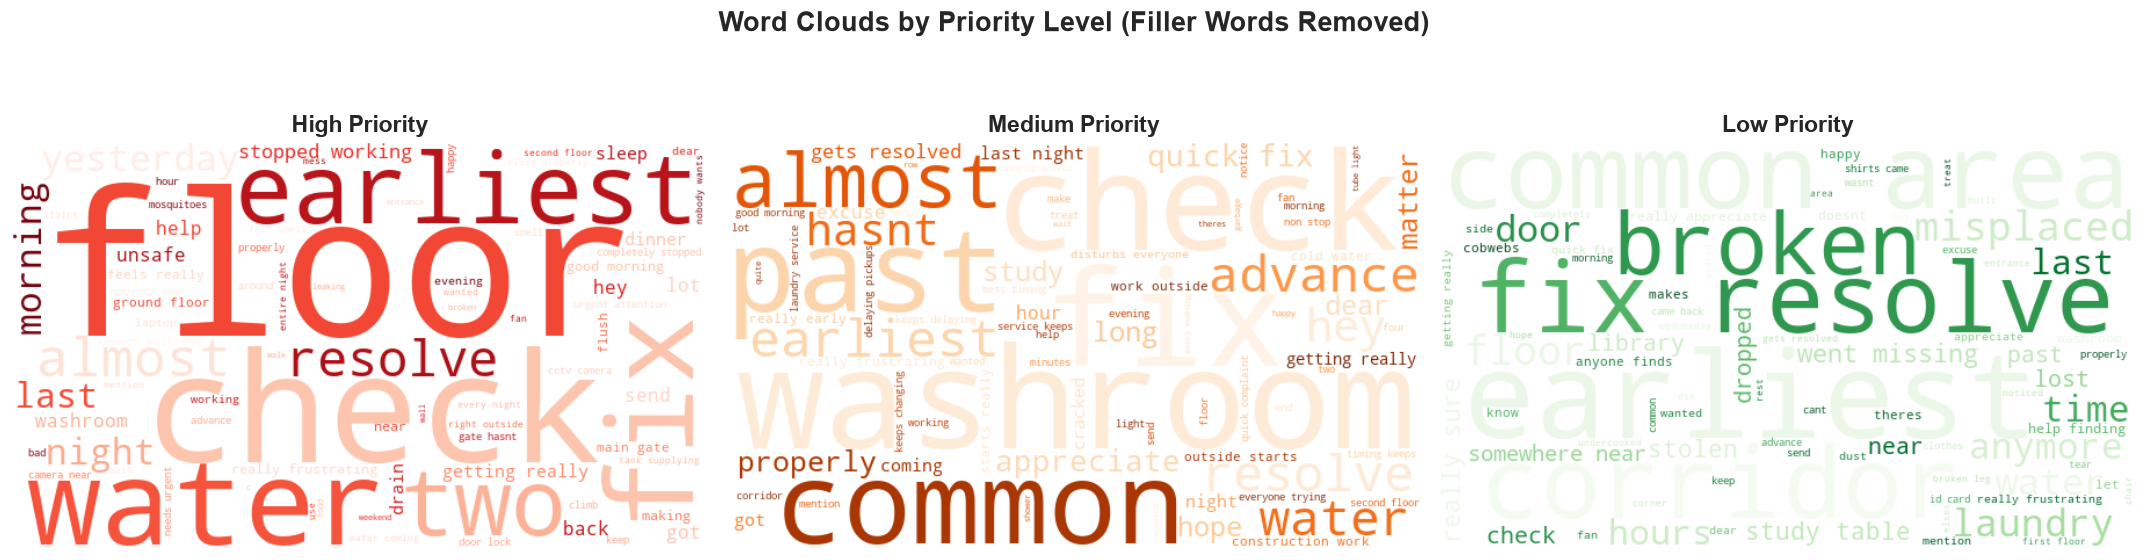

Custom stopwords removed: ['also', 'asap', 'block', 'charge', 'day', 'days', 'fixed', 'get', 'hello', 'hi', 'hostel', 'kindly', 'like', 'look', 'madam', 'need', 'now', 'one', 'please', 'pls', 'plz', 'respected', 'room', 'since', 'sir', 'someone', 'soon', 'thank', 'thanks', 'today', 'us', 'warden', 'week', 'weeks', 'whoever', 'would']


In [91]:
# ============================================================
# 2.7  WORD CLOUDS BY PRIORITY LEVEL
# ============================================================

# Install wordcloud if not already installed
try:
    from wordcloud import WordCloud
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'wordcloud', '-q'])
    from wordcloud import WordCloud

# Domain-specific filler words to exclude from word clouds
# These are common in hostel complaints but carry no priority signal
custom_stopwords = {
    'please', 'kindly', 'sir', 'madam', 'hello', 'thanks', 'thank',
    'look', 'now', 'today', 'day', 'days', 'week', 'weeks', 'asap',
    'hi', 'respected', 'warden', 'hostel', 'room', 'block',
    'since', 'also', 'would', 'need', 'one', 'us', 'get', 'like',
    'pls', 'plz', 'someone', 'whoever', 'charge', 'fixed', 'soon'
}

# Combine NLTK stopwords + custom stopwords
from nltk.corpus import stopwords
all_stopwords = set(stopwords.words('english')).union(custom_stopwords)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

priority_levels = ['High', 'Medium', 'Low']
wc_colors = ['Reds', 'Oranges', 'Greens']

for i, (priority, cmap) in enumerate(zip(priority_levels, wc_colors)):
    # Combine all complaint text for this priority
    text = ' '.join(df[df['Priority'] == priority]['Complaint_Text'].str.lower().tolist())
    
    # Generate word cloud with custom stopwords
    wc = WordCloud(width=600, height=350, background_color='white',
                   colormap=cmap, max_words=80, random_state=42,
                   contour_width=1, contour_color='black',
                   stopwords=all_stopwords)
    wc.generate(text)
    
    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].set_title(f'{priority} Priority', fontsize=14, fontweight='bold')
    axes[i].axis('off')

plt.suptitle('Word Clouds by Priority Level (Filler Words Removed)',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_wordclouds.png', bbox_inches='tight', dpi=150)
plt.show()

print(f'Custom stopwords removed: {sorted(custom_stopwords)}')

**Observation:**
- The word clouds display the most frequently occurring words in complaint texts for each priority level, **after removing** both standard English stopwords and domain-specific filler words (please, kindly, sir, etc.).
- Larger words appear more frequently in that priority class.
- Refer to the clouds above — each priority level shows a visually distinct vocabulary.

**Interpretation:**
- Different priority levels are associated with different dominant words in the complaint text.
- This visual difference suggests that the text content (vocabulary) varies across priority levels.

**ML Relevance:**
- Since different words appear prominently in different priority classes, TF-IDF vectorization should capture these differences as useful features for classification.

**Limitation:**
- Word clouds show **frequency only**, not importance or predictive power. A word appearing frequently in one class may also appear in others.
- Word clouds **cannot be used to infer causation** — a word being prominent does not mean it *causes* a certain priority assignment.
- The model will learn the actual discriminative power of each word during training.

---
### 2.8 — Status Distribution

Although we won't use `Status` as a feature (to avoid data leakage), let's visualize it for understanding the operational side.

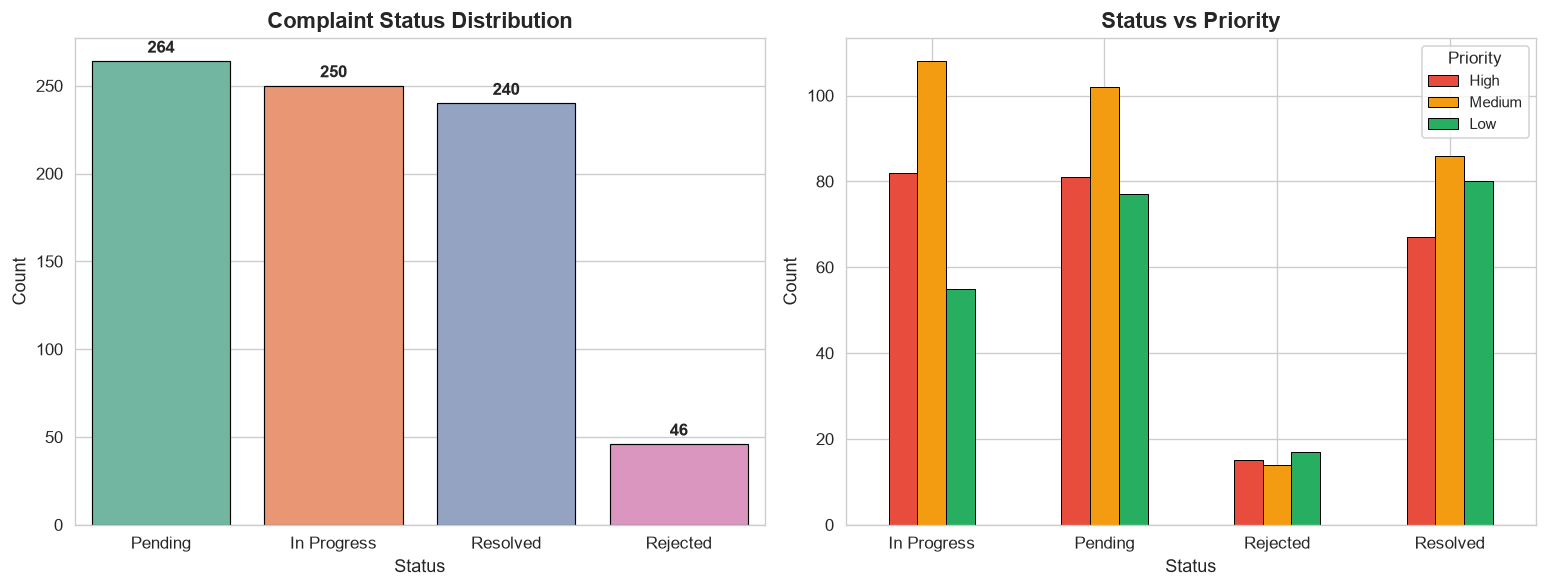


[!]️ Note: Status will NOT be used as a model feature (data leakage risk).
   It is shown here only for exploratory understanding.


In [92]:
# ============================================================
# 2.8  STATUS DISTRIBUTION & STATUS vs PRIORITY
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Status Distribution ---
status_order = df['Status'].value_counts().index
sns.countplot(data=df, x='Status', order=status_order,
              palette='Set2', edgecolor='black', linewidth=0.7, ax=axes[0])
axes[0].set_title('Complaint Status Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Status', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
for container in axes[0].containers:
    axes[0].bar_label(container, fontsize=10, fontweight='bold', padding=3)

# --- Status vs Priority ---
ct_status = pd.crosstab(df['Status'], df['Priority'])
ct_status = ct_status[['High', 'Medium', 'Low']]
ct_status.plot(kind='bar', ax=axes[1],
               color=['#e74c3c', '#f39c12', '#27ae60'],
               edgecolor='black', linewidth=0.6)
axes[1].set_title('Status vs Priority', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Status', fontsize=11)
axes[1].set_ylabel('Count', fontsize=11)
axes[1].legend(title='Priority', fontsize=9)
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('eda_status.png', bbox_inches='tight', dpi=150)
plt.show()

print('\n[!]️ Note: Status will NOT be used as a model feature (data leakage risk).')
print('   It is shown here only for exploratory understanding.')

**🔍 Insight:**
- **Observation:** The status distribution shows the count of complaints in each status category (refer to the chart for exact numbers).
- **Observation:** The stacked bar shows how status is distributed across priority levels.
- ⚠️ **Important:** We will **NOT** use `Status` as a training feature because it is determined *after* priority is assigned. Using it would cause **data leakage** — the model would cheat by using future information.

---
### 2.9 — Complaint Text Length Analysis

Do longer complaints tend to have higher priority? Let's check the relationship between text length and priority.

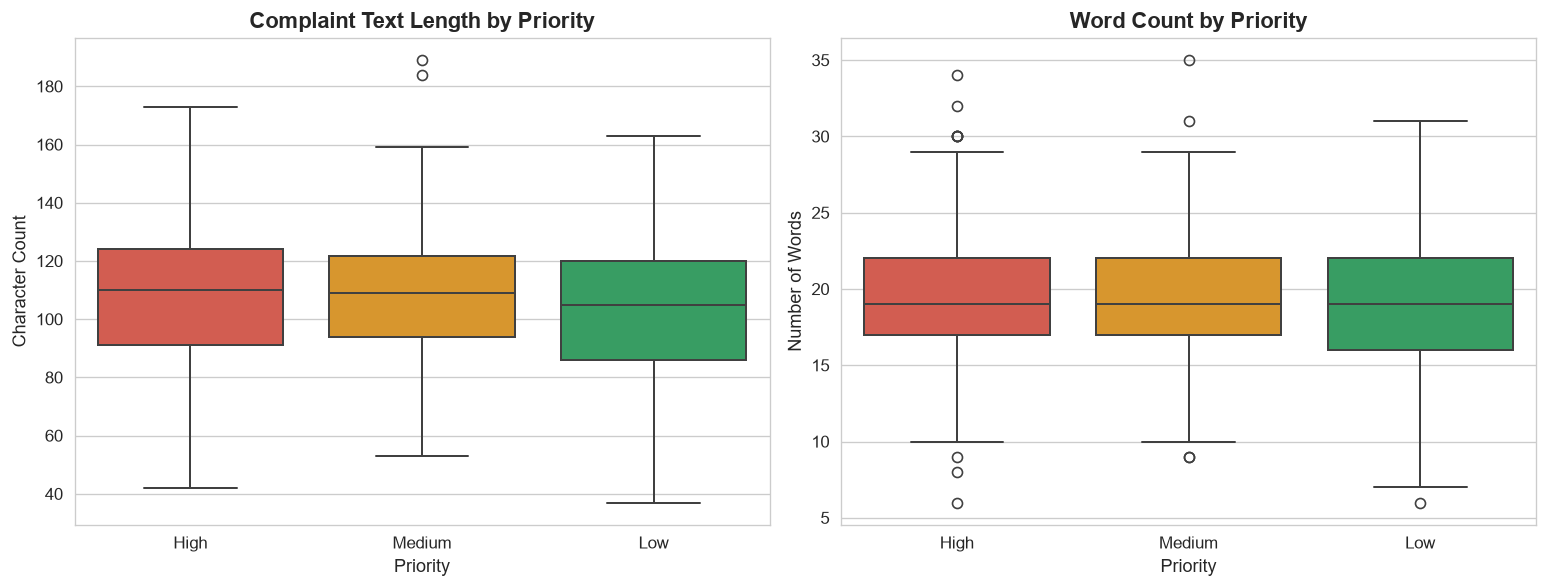

Average Text Length by Priority:
          text_length  word_count
Priority                         
High            107.8        19.3
Medium          107.9        19.2
Low             103.9        19.1


In [93]:
# ============================================================
# 2.9  TEXT LENGTH ANALYSIS
# ============================================================

# Create text length features
df['text_length'] = df['Complaint_Text'].str.len()        # Character count
df['word_count'] = df['Complaint_Text'].str.split().str.len()  # Word count

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

priority_order = ['High', 'Medium', 'Low']
colors_p = ['#e74c3c', '#f39c12', '#27ae60']

# --- Text Length Boxplot ---
sns.boxplot(data=df, x='Priority', y='text_length', order=priority_order,
            palette=colors_p, ax=axes[0], linewidth=1.2)
axes[0].set_title('Complaint Text Length by Priority', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Priority', fontsize=11)
axes[0].set_ylabel('Character Count', fontsize=11)

# --- Word Count Boxplot ---
sns.boxplot(data=df, x='Priority', y='word_count', order=priority_order,
            palette=colors_p, ax=axes[1], linewidth=1.2)
axes[1].set_title('Word Count by Priority', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Priority', fontsize=11)
axes[1].set_ylabel('Number of Words', fontsize=11)

plt.tight_layout()
plt.savefig('eda_text_length.png', bbox_inches='tight', dpi=150)
plt.show()

# Summary stats
print('Average Text Length by Priority:')
print(df.groupby('Priority')[['text_length', 'word_count']].mean().round(1).reindex(priority_order))

# Drop temporary columns (we'll recreate if needed later)
df.drop(columns=['text_length', 'word_count'], inplace=True)

**🔍 Insight:**
- **Observation:** The boxplots show the distribution of text length and word count across priority levels. Refer to the printed averages for exact values.
- **ML Relevance:** If text length differs across priorities, TF-IDF may indirectly capture this through the number of non-zero features per document.
- **Limitation:** Text length is a surface-level feature. The actual words used (captured by TF-IDF) are expected to be more informative than length alone.

---
## Section 2 Complete - EDA Summary

### Key Findings from EDA:

| Finding | Evidence |
|---|---|
| **Numerical features show separation** | Boxplots of `Students_Affected` and `Support_Count` show different distributions across priority levels |
| **Category is associated with Priority** | Heatmap shows non-uniform priority distribution across categories |
| **Text vocabulary differs by Priority** | Word clouds and top-word charts show different dominant words per class |
| **Complaint_Type** | Priority distribution differs between Public and Private complaints |
| **Block & Floor** | Complaints vary across locations; predictive value to be determined by modeling |
| **No multicollinearity** | Correlation heatmap shows no extreme correlations between numerical features |
| **Data leakage risk** | `Status` must NOT be used as a feature (assigned after priority) |

### Columns Confirmed for Model Training:
- **Text:** `Complaint_Text` -> TF-IDF
- **Categorical:** `Complaint_Type`, `Block`, `Floor`, `Category`
- **Numerical:** `Students_Affected`, `Support_Count`
- **Drop:** `Complaint_ID`, `Room_No`, `Duration`, `Status`, `Complaint_Date`

### Important Note:
All observations above describe **associations and patterns** in the data. They do not imply causation. The actual predictive power of each feature will be determined during model training and evaluation.

**Type `Next` to proceed to Section 3: NLP Preprocessing**

---
## SECTION 3: NLP Preprocessing

Before feeding text to a machine learning model, we must **clean and standardize** it. Raw text contains noise (punctuation, numbers, stopwords) that adds no predictive value and can confuse the model.

### NLP Preprocessing Pipeline:
1. **Lowercase** - make all text uniform
2. **Remove punctuation** - commas, periods, etc. add no meaning
3. **Remove numbers** - room numbers, dates are noise for text classification
4. **Remove extra spaces** - clean up whitespace
5. **Remove stopwords** - common words like *the, is, and* carry no priority signal
6. **Lemmatization** - reduce words to their root form (*running -> run*, *broken -> break*)

> **Best Practice:** Always apply the same preprocessing to both training data and new predictions.

---
### 3.1 - Display Original Text (Before Preprocessing)

Let us first look at a few raw complaint texts to understand what needs cleaning.

In [94]:
# ============================================================
# 3.1  DISPLAY ORIGINAL COMPLAINT TEXT (BEFORE CLEANING)
# ============================================================

print('Sample Raw Complaint Texts (Before Preprocessing):')
print('=' * 70)
for i in range(5):
    print(f'\n[{i+1}] {df["Complaint_Text"].iloc[i]}')
print('\n' + '=' * 70)

Sample Raw Complaint Texts (Before Preprocessing):

[1] Hi, theres cobwebs all over the staircase.

[2] My washroom door doesnt lock properly because the pipe fitting behind it is loose and jammed.

[3] The milk served at breakfast smelled slightly off this morning.

[4] Mess timing keeps changing without any notice, we end up missing dinner.

[5] Theres cobwebs all over the staircase, doesnt look like anyone has cleaned it in ages, since Monday.



**Observation:**
- Text has **mixed case** (uppercase and lowercase)
- Contains **punctuation** (commas, periods, apostrophes)
- Contains **numbers** (room numbers, durations)
- Has **stopwords** (*the, is, has, in, it*)
- Words appear in different forms (*cleaning, cleaned, cleans*)

All of these need to be standardized for effective NLP.

---
### 3.2 - Build the NLP Preprocessing Function

We create a **single reusable function** that applies all cleaning steps in order. This is a best practice because:
- It keeps the code **modular and clean**
- We can apply the **exact same cleaning** to new complaints during prediction
- Each step is clearly documented

In [95]:
# ============================================================
# 3.2  NLP PREPROCESSING FUNCTION
# ============================================================

# Initialize tools
stop_words = set(stopwords.words('english'))   # Set of 179 common English words
lemmatizer = WordNetLemmatizer()                # Reduces words to root form

# Domain-specific filler words common in hostel complaints
# These words appear across all priority levels and add no predictive value
domain_stopwords = {
    'please', 'kindly', 'sir', 'madam', 'hello', 'thanks', 'thank',
    'look', 'now', 'today', 'day', 'days', 'week', 'weeks', 'asap',
    'hi', 'respected', 'warden', 'hostel', 'room', 'block',
    'since', 'also', 'would', 'need', 'one', 'us', 'get', 'like',
    'pls', 'plz', 'someone', 'whoever', 'charge', 'fixed', 'soon'
}

# Combine standard + domain stopwords
all_stop_words = stop_words.union(domain_stopwords)

def preprocess_text(text):
    """
    Clean and preprocess complaint text for NLP.
    
    Steps:
        1. Lowercase
        2. Remove punctuation
        3. Remove numbers
        4. Remove extra whitespace
        5. Remove stopwords (standard English + domain-specific)
        6. Lemmatize words
    
    Args:
        text (str): Raw complaint text
    
    Returns:
        str: Cleaned and preprocessed text
    """
    
    # Step 1: Convert to lowercase
    # Why? 'Broken' and 'broken' should be treated as the same word.
    # Without this, the model would treat them as two separate features.
    text = text.lower()
    
    # Step 2: Remove punctuation
    # Why? Commas, periods, quotes are grammatical markers that don't
    # carry meaning for priority classification.
    text = re.sub(r'[^\w\s]', '', text)
    
    # Step 3: Remove numbers
    # Why? Numbers like room numbers (24, 30) and durations (3, 4)
    # are specific identifiers. They don't generalize across complaints.
    # Numerical features like Students_Affected are handled separately.
    text = re.sub(r'\d+', '', text)
    
    # Step 4: Remove extra whitespace
    # Why? After removing punctuation and numbers, gaps may remain.
    # 'room  broken' becomes 'room broken'.
    text = re.sub(r'\s+', ' ', text).strip()
    
    # Step 5: Remove stopwords (standard + domain-specific)
    # Why? Standard stopwords (the, is, and) appear in ALL texts equally.
    # Domain stopwords (please, kindly, sir) are polite filler words
    # that don't distinguish between High, Medium, and Low priority.
    words = text.split()
    words = [word for word in words if word not in all_stop_words]
    
    # Step 6: Lemmatization
    # Why? Reduces words to their dictionary root form.
    # 'running' -> 'run', 'mice' -> 'mouse', 'broken' -> 'broken'
    # This reduces vocabulary size and groups word variations together,
    # so the model doesn't treat them as separate features.
    words = [lemmatizer.lemmatize(word) for word in words]
    
    return ' '.join(words)

print('Preprocessing function created successfully!')
print(f'Standard English stopwords: {len(stop_words)}')
print(f'Domain-specific stopwords: {len(domain_stopwords)}')
print(f'Total stopwords: {len(all_stop_words)}')

Preprocessing function created successfully!
Standard English stopwords: 198
Domain-specific stopwords: 36
Total stopwords: 233


**Explanation of Each Step:**

| Step | What it does | Example | Why it helps the model |
|---|---|---|---|
| **Lowercase** | Converts all characters to lowercase | `Broken` -> `broken` | Without this, the model would treat 'Broken' and 'broken' as two different words, inflating the vocabulary unnecessarily |
| **Remove Punctuation** | Strips all special characters | `door,` -> `door` | Punctuation is grammatical, not semantic. It does not indicate whether a complaint is High or Low priority |
| **Remove Numbers** | Strips all digits | `Room 24` -> `Room ` | Room numbers and durations are specific identifiers that do not generalize. Numerical features like `Students_Affected` are handled separately as structured data |
| **Remove Extra Spaces** | Collapses multiple spaces | `door  broken` -> `door broken` | Ensures consistent tokenization when splitting text into words |
| **Remove Stopwords** | Removes common English words + domain filler words | `the door is broken please` -> `door broken` | These words appear equally across all priority levels and add noise rather than signal |
| **Lemmatization** | Reduces words to base/root form | `running` -> `run` | Groups word variations together so the model treats them as one feature instead of many |

**Why domain-specific stopwords?**
- Words like *please, kindly, sir, madam, asap* are polite filler words used by students regardless of complaint severity.
- If we keep them, TF-IDF would assign them features even though they carry no priority signal.
- Removing them reduces noise and helps the model focus on genuinely informative words.

---
### 3.3 - Demonstrate Preprocessing (Step-by-Step)

Let us show the transformation at **each step** for one example complaint so you can see exactly what happens.

In [96]:
# ============================================================
# 3.3  STEP-BY-STEP DEMONSTRATION
# ============================================================

# Pick a sample complaint
sample = df['Complaint_Text'].iloc[3]  # Mess timing complaint
print('STEP-BY-STEP PREPROCESSING DEMO')
print('=' * 65)
print(f'\nOriginal Text:\n   "{sample}"')

# Step 1
step1 = sample.lower()
print(f'\nStep 1 - Lowercase:\n   "{step1}"')

# Step 2
step2 = re.sub(r'[^\w\s]', '', step1)
print(f'\nStep 2 - Remove Punctuation:\n   "{step2}"')

# Step 3
step3 = re.sub(r'\d+', '', step2)
print(f'\nStep 3 - Remove Numbers:\n   "{step3}"')

# Step 4
step4 = re.sub(r'\s+', ' ', step3).strip()
print(f'\nStep 4 - Remove Extra Spaces:\n   "{step4}"')

# Step 5: Using combined stopwords (standard + domain)
words = [w for w in step4.split() if w not in all_stop_words]
step5 = ' '.join(words)
removed_standard = [w for w in step4.split() if w in stop_words]
removed_domain = [w for w in step4.split() if w in domain_stopwords]
print(f'\nStep 5 - Remove Stopwords:\n   "{step5}"')
print(f'   Removed (standard): {removed_standard}')
print(f'   Removed (domain):   {removed_domain}')

# Step 6
words_lem = [lemmatizer.lemmatize(w) for w in words]
step6 = ' '.join(words_lem)
print(f'\nStep 6 - Lemmatization:\n   "{step6}"')
changed = [(w1, w2) for w1, w2 in zip(words, words_lem) if w1 != w2]
if changed:
    print(f'   Changed: {changed}')
else:
    print(f'   (No words changed in this example)')

print('\n' + '=' * 65)
print(f'FINAL RESULT: "{step6}"')

STEP-BY-STEP PREPROCESSING DEMO

Original Text:
   "Mess timing keeps changing without any notice, we end up missing dinner."

Step 1 - Lowercase:
   "mess timing keeps changing without any notice, we end up missing dinner."

Step 2 - Remove Punctuation:
   "mess timing keeps changing without any notice we end up missing dinner"

Step 3 - Remove Numbers:
   "mess timing keeps changing without any notice we end up missing dinner"

Step 4 - Remove Extra Spaces:
   "mess timing keeps changing without any notice we end up missing dinner"

Step 5 - Remove Stopwords:
   "mess timing keeps changing without notice end missing dinner"
   Removed (standard): ['any', 'we', 'up']
   Removed (domain):   []

Step 6 - Lemmatization:
   "mess timing keep changing without notice end missing dinner"
   Changed: [('keeps', 'keep')]

FINAL RESULT: "mess timing keep changing without notice end missing dinner"


**Interpretation:**
- The original text was a messy, natural-language sentence.
- After preprocessing, we have **only the meaningful words in their base form**.
- This cleaned text is what TF-IDF will work with in the next section.
- Notice how stopwords like *the, is, without, any, we, up* were removed - they appear in all complaints and do not help distinguish priority.

---
### 3.4 - Apply Preprocessing to the Entire Dataset

Now we apply our `preprocess_text()` function to every complaint in the dataset using `.apply()`.

In [97]:
# ============================================================
# 3.4  APPLY PREPROCESSING TO ALL COMPLAINTS
# ============================================================

# Create a new column with cleaned text
# We keep the original text for reference
df['Cleaned_Text'] = df['Complaint_Text'].apply(preprocess_text)

print('Preprocessing applied to all 800 complaints!')
print(f'New column added: "Cleaned_Text"')
print(f'Dataset shape: {df.shape}')

Preprocessing applied to all 800 complaints!
New column added: "Cleaned_Text"
Dataset shape: (800, 14)


---
### 3.5 - Before vs After Comparison

Let us compare the original and cleaned text side by side for several complaints.

In [98]:
# ============================================================
# 3.5  BEFORE vs AFTER COMPARISON
# ============================================================

print('BEFORE vs AFTER PREPROCESSING')
print('=' * 90)

# Show 8 examples with different priorities
sample_indices = [0, 2, 3, 6, 7, 9, 11, 14]

for idx in sample_indices:
    priority = df['Priority'].iloc[idx]
    original = df['Complaint_Text'].iloc[idx]
    cleaned = df['Cleaned_Text'].iloc[idx]
    
    print(f'\n[{idx+1}] Priority: {priority}')
    print(f'   BEFORE: {original}')
    print(f'   AFTER : {cleaned}')
    print(f'   Words reduced: {len(original.split())} -> {len(cleaned.split())}')

print('\n' + '=' * 90)

BEFORE vs AFTER PREPROCESSING

[1] Priority: Low
   BEFORE: Hi, theres cobwebs all over the staircase.
   AFTER : there cobweb staircase
   Words reduced: 7 -> 3

[3] Priority: High
   BEFORE: The milk served at breakfast smelled slightly off this morning.
   AFTER : milk served breakfast smelled slightly morning
   Words reduced: 10 -> 6

[4] Priority: Medium
   BEFORE: Mess timing keeps changing without any notice, we end up missing dinner.
   AFTER : mess timing keep changing without notice end missing dinner
   Words reduced: 12 -> 9

[7] Priority: High
   BEFORE: Since yesterday, bunk bed ladder in my room feels really loose, kind of unsafe to climb.
   AFTER : yesterday bunk bed ladder feel really loose kind unsafe climb
   Words reduced: 16 -> 10

[8] Priority: High
   BEFORE: theres been no drinking water in the cooler on Second floor since this morning.
   AFTER : there drinking water cooler second floor morning
   Words reduced: 14 -> 7

[10] Priority: High
   BEFORE: Constru

**Interpretation:**
- Every complaint is now **shorter and cleaner** - only meaningful words remain.
- The **word count is reduced** significantly (typically 30-50% reduction).
- Priority-related words are preserved: *broken, sick, food, stale, noise, water*.
- Noise words are removed: *the, is, has, been, in, my, it, a*.
- This clean text will produce **better TF-IDF features** because the vocabulary is more focused.

---
### 3.6 - Verify Cleaning Quality

Let us run some sanity checks to make sure preprocessing worked correctly.

In [99]:
# ============================================================
# 3.6  VERIFY PREPROCESSING QUALITY
# ============================================================

# Check 1: No empty strings after cleaning
empty_count = (df['Cleaned_Text'].str.strip() == '').sum()
print(f'Check 1 - Empty texts after cleaning: {empty_count}')

# Check 2: No null values
null_count = df['Cleaned_Text'].isnull().sum()
print(f'Check 2 - Null values: {null_count}')

# Check 3: Average word count before vs after
avg_before = df['Complaint_Text'].str.split().str.len().mean()
avg_after = df['Cleaned_Text'].str.split().str.len().mean()
reduction = ((avg_before - avg_after) / avg_before * 100)
print(f'\nCheck 3 - Average word count:')
print(f'   Before preprocessing: {avg_before:.1f} words')
print(f'   After preprocessing:  {avg_after:.1f} words')
print(f'   Reduction: {reduction:.1f}%')

# Check 4: Vocabulary size
vocab_before = set(' '.join(df['Complaint_Text'].str.lower()).split())
vocab_after = set(' '.join(df['Cleaned_Text']).split())
print(f'\nCheck 4 - Vocabulary size:')
print(f'   Before: {len(vocab_before)} unique words')
print(f'   After:  {len(vocab_after)} unique words')
print(f'   Reduction: {((len(vocab_before) - len(vocab_after)) / len(vocab_before) * 100):.1f}%')

print('\nAll checks passed! Preprocessing is clean and complete.')

Check 1 - Empty texts after cleaning: 0
Check 2 - Null values: 0

Check 3 - Average word count:
   Before preprocessing: 19.2 words
   After preprocessing:  9.3 words
   Reduction: 51.4%

Check 4 - Vocabulary size:
   Before: 1098 unique words
   After:  691 unique words
   Reduction: 37.1%

All checks passed! Preprocessing is clean and complete.


**Interpretation:**
- **No empty texts** - every complaint still has meaningful content after cleaning.
- **No null values** - the function handled all rows correctly.
- The word reduction percentage shows how much noise was removed.
- **Smaller vocabulary** - fewer unique words means TF-IDF will produce a smaller, more efficient feature matrix.

> **Best Practice:** Always verify that preprocessing does not accidentally destroy useful information or create empty rows.

---
### 3.7 - Top Words After Preprocessing (by Priority)

Let us see which words appear most frequently in each priority class after cleaning. This confirms that meaningful, priority-relevant words survived the preprocessing.

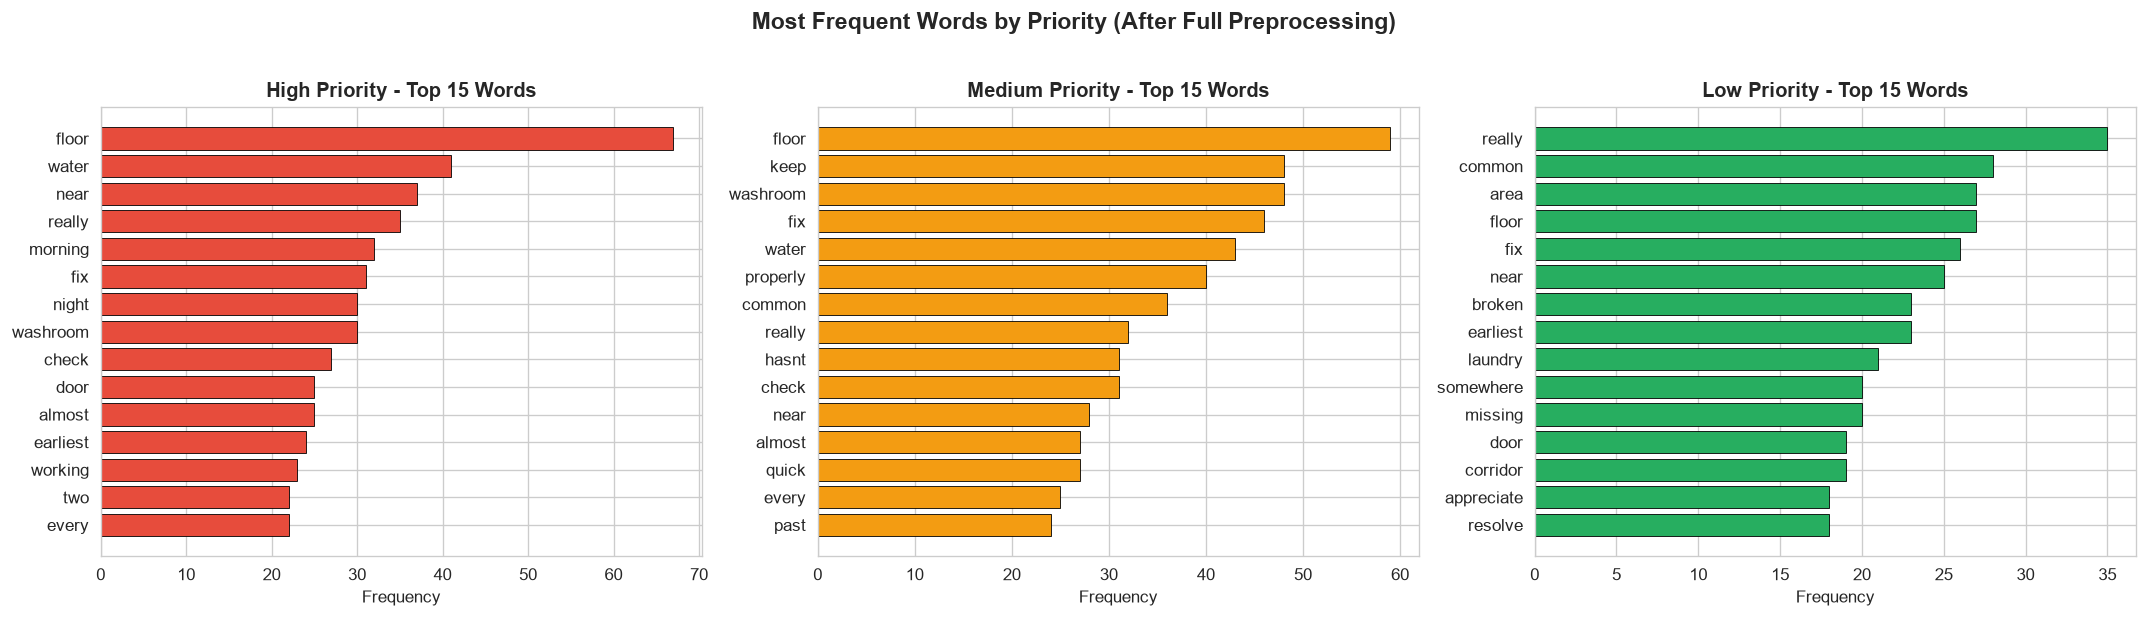


Top 10 Words per Priority Level:
-------------------------------------------------------
High    : floor (67), water (41), near (37), really (35), morning (32), fix (31), night (30), washroom (30), check (27), door (25)
Medium  : floor (59), keep (48), washroom (48), fix (46), water (43), properly (40), common (36), really (32), hasnt (31), check (31)
Low     : really (35), common (28), area (27), floor (27), fix (26), near (25), broken (23), earliest (23), laundry (21), somewhere (20)


In [100]:
# ============================================================
# 3.7  TOP WORDS BY PRIORITY (AFTER PREPROCESSING)
# ============================================================

from collections import Counter

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

priority_levels = ['High', 'Medium', 'Low']
bar_colors = ['#e74c3c', '#f39c12', '#27ae60']

for i, (priority, color) in enumerate(zip(priority_levels, bar_colors)):
    # Get all words for this priority (already preprocessed with custom stopwords)
    all_words = ' '.join(df[df['Priority'] == priority]['Cleaned_Text']).split()
    word_freq = Counter(all_words).most_common(15)
    
    words, counts = zip(*word_freq)
    
    axes[i].barh(range(len(words)), counts, color=color,
                 edgecolor='black', linewidth=0.5)
    axes[i].set_yticks(range(len(words)))
    axes[i].set_yticklabels(words, fontsize=10)
    axes[i].invert_yaxis()  # Most frequent at top
    axes[i].set_title(f'{priority} Priority - Top 15 Words',
                     fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Frequency', fontsize=10)

plt.suptitle('Most Frequent Words by Priority (After Full Preprocessing)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('nlp_top_words_by_priority.png', bbox_inches='tight', dpi=150)
plt.show()

# Print top words as a table for reference
print('\nTop 10 Words per Priority Level:')
print('-' * 55)
for priority in priority_levels:
    all_words = ' '.join(df[df['Priority'] == priority]['Cleaned_Text']).split()
    top10 = Counter(all_words).most_common(10)
    words_str = ', '.join([f'{w} ({c})' for w, c in top10])
    print(f'{priority:8s}: {words_str}')

**Observation:**
- The bar charts show the 15 most frequent words in each priority class after full preprocessing (including domain-specific stopword removal).
- The printed table provides exact word frequencies for reference.

**Interpretation:**
- The top words differ across priority levels, suggesting that complaint vocabulary is associated with priority.
- After removing filler words, the remaining vocabulary is more focused on the actual issue being reported.

**ML Relevance:**
- Since word distributions differ across priorities, TF-IDF features should provide discriminative signal for classification.

**Limitation:**
- Frequency alone does not guarantee predictive power. Some words may appear across multiple priority levels.
- The model will learn the actual discriminative weights during training — these charts are exploratory, not definitive.

---
## Section 3 Complete - NLP Preprocessing Summary

### What We Did:
| Step | Purpose | Impact |
|---|---|---|
| Lowercase | Uniformity | `Broken` = `broken` — prevents duplicate features |
| Remove Punctuation | Remove noise | `, . ! ? '` removed — not useful for classification |
| Remove Numbers | Remove identifiers | Room numbers, dates removed — handled as structured features separately |
| Remove Extra Spaces | Clean formatting | Double spaces collapsed — ensures consistent tokenization |
| Remove Stopwords | Remove filler words | Standard English + domain-specific (please, kindly, sir, etc.) |
| Lemmatization | Normalize word forms | `running` -> `run` — reduces vocabulary, groups variants |

### Quality Checks Passed:
- No empty texts after preprocessing
- No null values introduced
- Vocabulary size reduced (exact percentages shown in Check 4 above)
- Priority-relevant words preserved (verified in Section 3.7)

### Result:
- New column `Cleaned_Text` created with fully preprocessed text
- Data is ready for **TF-IDF Vectorization** (Section 4)

**Type `Next` to proceed to Section 4: TF-IDF Vectorization**

---
## SECTION 4: TF-IDF Vectorization

Machine learning models cannot work with raw text. They need **numerical input**. TF-IDF (Term Frequency - Inverse Document Frequency) is a technique that converts text into a matrix of numbers, where each number represents how important a word is to a specific document (complaint) relative to the entire dataset.

### What is TF-IDF?

TF-IDF is the product of two components:

**1. Term Frequency (TF):** How often a word appears in a single document.

$$TF(t, d) = \frac{\text{Number of times term } t \text{ appears in document } d}{\text{Total number of terms in document } d}$$

- A word that appears 3 times in a 10-word complaint has TF = 3/10 = 0.3

**2. Inverse Document Frequency (IDF):** How rare a word is across ALL documents.

$$IDF(t) = \log\left(\frac{\text{Total number of documents}}{\text{Number of documents containing term } t}\right)$$

- A word appearing in every complaint gets a LOW IDF (not informative).
- A word appearing in only a few complaints gets a HIGH IDF (more distinctive).

**3. TF-IDF Score:**

$$TF\text{-}IDF(t, d) = TF(t, d) \times IDF(t)$$

### Intuitive Explanation:
- A word that appears **frequently in one complaint** but **rarely across all complaints** gets a **high TF-IDF score** — it is distinctive and informative for that complaint.
- A word that appears **everywhere** (like common words) gets a **low TF-IDF score** — it does not help distinguish between complaints.

> **Why TF-IDF for this project?** Our complaint texts vary in length and vocabulary. TF-IDF captures which words are most distinctive for each complaint, making it a standard and effective method for text classification tasks.

---
### 4.1 - Apply TF-IDF Vectorization

We use scikit-learn's `TfidfVectorizer` to transform the `Cleaned_Text` column into a numerical feature matrix.

**Key Parameters:**
- `max_features=1000`: Keep only the top 1000 most informative words to avoid a very sparse matrix.
- `ngram_range=(1,2)`: Include both single words (unigrams) and two-word phrases (bigrams). Bigrams capture context — for example, *"water cooler"* together is more informative than *"water"* and *"cooler"* separately.
- `min_df=2`: Ignore words that appear in fewer than 2 complaints (too rare to generalize).
- `max_df=0.95`: Ignore words that appear in more than 95% of complaints (too common to be distinctive).

In [101]:
# ============================================================
# 4.1  APPLY TF-IDF VECTORIZATION
# ============================================================

# Initialize the TF-IDF Vectorizer with carefully chosen parameters
tfidf = TfidfVectorizer(
    max_features=1000,       # Keep top 1000 words (controls matrix size)
    ngram_range=(1, 2),      # Unigrams + bigrams (single words + word pairs)
    min_df=2,                # Word must appear in at least 2 documents
    max_df=0.95,             # Ignore words appearing in >95% of documents
    sublinear_tf=True        # Apply log normalization to term frequency
)

# Fit and transform the cleaned complaint text
# fit_transform() learns the vocabulary AND converts text to numbers in one step
tfidf_matrix = tfidf.fit_transform(df['Cleaned_Text'])

print('TF-IDF Vectorization Complete!')
print(f'  Input:  {len(df)} complaint texts')
print(f'  Output: TF-IDF matrix of shape {tfidf_matrix.shape}')
print(f'  -> {tfidf_matrix.shape[0]} complaints (rows)')
print(f'  -> {tfidf_matrix.shape[1]} TF-IDF features (columns/words)')
print(f'\n  Matrix type: {type(tfidf_matrix).__name__} (sparse matrix - memory efficient)')
print(f'  Non-zero entries: {tfidf_matrix.nnz} out of {tfidf_matrix.shape[0] * tfidf_matrix.shape[1]}')
print(f'  Sparsity: {(1 - tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1])) * 100:.1f}%')

TF-IDF Vectorization Complete!
  Input:  800 complaint texts
  Output: TF-IDF matrix of shape (800, 1000)
  -> 800 complaints (rows)
  -> 1000 TF-IDF features (columns/words)

  Matrix type: csr_matrix (sparse matrix - memory efficient)
  Non-zero entries: 10770 out of 800000
  Sparsity: 98.7%


**Observation:**
- The TF-IDF matrix has **800 rows** (one per complaint) and up to **1000 columns** (one per word/bigram feature).
- The matrix is **sparse** — most entries are zero because each complaint only contains a small fraction of the total vocabulary.
- Sparse matrices are stored efficiently in memory (only non-zero values are stored).

**Interpretation:**
- Each complaint is now represented as a numerical vector of TF-IDF scores.
- Higher scores indicate words that are more distinctive for that specific complaint.

**ML Relevance:**
- This matrix will be the primary text-based input to our ML models.
- The `sublinear_tf=True` parameter applies logarithmic scaling to term frequency, which reduces the impact of words that appear very frequently in a single complaint.

---
### 4.2 - Examine the TF-IDF Vocabulary

Let us see what words/bigrams TF-IDF selected as features and examine a sample of the feature matrix.

In [102]:
# ============================================================
# 4.2  EXAMINE TF-IDF VOCABULARY AND FEATURES
# ============================================================

# Get the list of feature names (words/bigrams)
feature_names = tfidf.get_feature_names_out()

print(f'Total TF-IDF features: {len(feature_names)}')
print(f'\nFirst 20 features (alphabetical):')
for i, word in enumerate(feature_names[:20], 1):
    print(f'  {i:3d}. {word}')

print(f'\nLast 20 features (alphabetical):')
for i, word in enumerate(feature_names[-20:], len(feature_names)-19):
    print(f'  {i:3d}. {word}')

# Count unigrams vs bigrams
unigrams = [f for f in feature_names if ' ' not in f]
bigrams = [f for f in feature_names if ' ' in f]
print(f'\nFeature breakdown:')
print(f'  Unigrams (single words): {len(unigrams)}')
print(f'  Bigrams (word pairs):    {len(bigrams)}')

# Show some example bigrams
print(f'\nSample bigrams:')
for bg in bigrams[:15]:
    print(f'  - {bg}')

Total TF-IDF features: 1000

First 20 features (alphabetical):
    1. across
    2. actually
    3. actually get
    4. advance
    5. afternoon
    6. airing
    7. almost
    8. almost broke
    9. almost entire
   10. almost fix
   11. almost whole
   12. always
   13. always sticky
   14. always weaker
   15. anymore
   16. anyone
   17. anyone find
   18. anyone walk
   19. appreciate
   20. appreciate help

Last 20 features (alphabetical):
  981. without notice
  982. wobble
  983. wobble every
  984. wobble running
  985. wobbly
  986. wont
  987. wont dry
  988. wont go
  989. wont open
  990. work
  991. work outside
  992. work right
  993. working
  994. working past
  995. working properly
  996. working two
  997. written
  998. yellowish
  999. yellowish smell
  1000. yesterday

Feature breakdown:
  Unigrams (single words): 452
  Bigrams (word pairs):    548

Sample bigrams:
  - actually get
  - almost broke
  - almost entire
  - almost fix
  - almost whole
  - always sti

**Observation:**
- The vocabulary contains both single words (unigrams) and two-word phrases (bigrams).
- Features are sorted alphabetically. The exact count depends on the `max_features` parameter and the data.

**Interpretation:**
- Bigrams capture multi-word concepts that single words alone might miss. For example, *"water cooler"* together is more specific than *"water"* alone.
- The `min_df=2` filter has removed words that appeared in only one complaint, reducing noise.

**Limitation:**
- TF-IDF does not capture word order beyond the bigram window. It treats text as a "bag of words/bigrams".
- Semantic similarity (e.g., *"broken"* and *"damaged"* meaning the same thing) is not captured by TF-IDF.

---
### 4.3 - Visualize Top TF-IDF Features

Let us identify which words have the highest average TF-IDF scores across all complaints. These are the words that TF-IDF considers most informative overall.

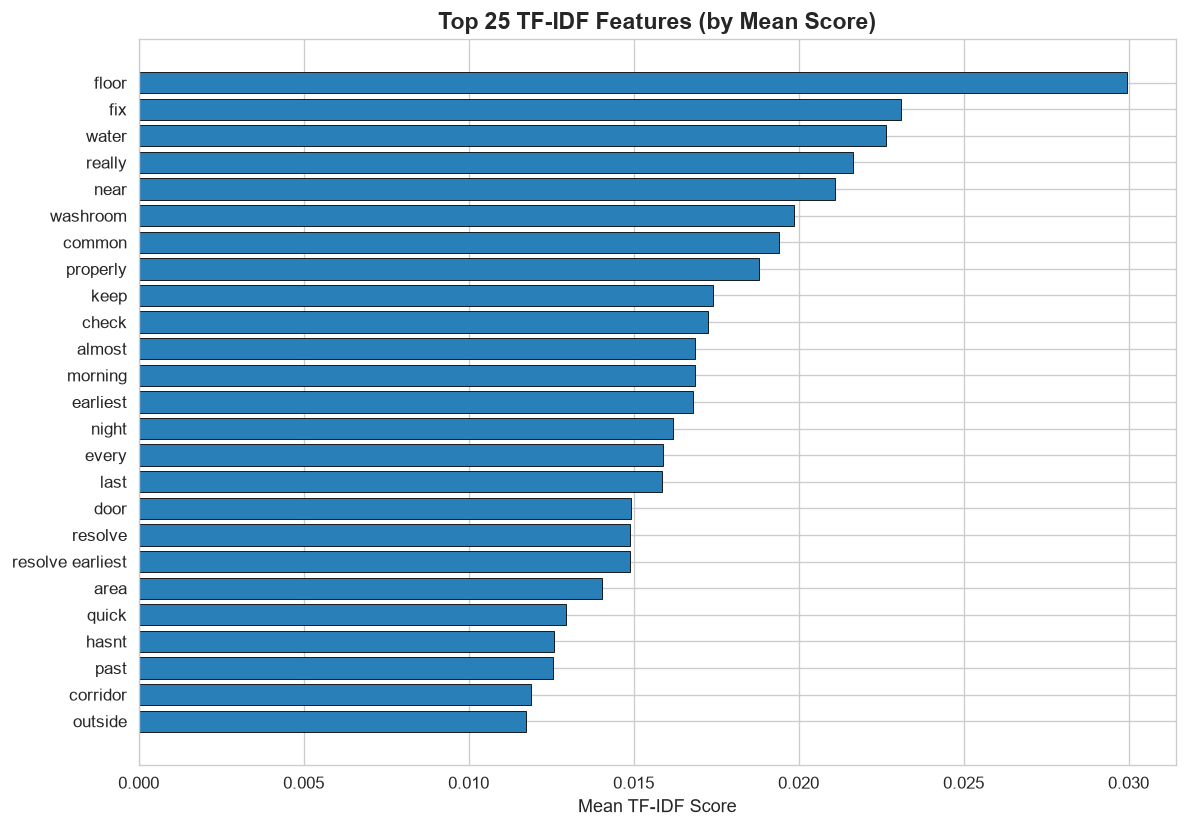


Top 10 Features with Highest Mean TF-IDF Scores:
 Feature  Mean_TF-IDF
   floor     0.029941
     fix     0.023103
   water     0.022642
  really     0.021641
    near     0.021107
washroom     0.019847
  common     0.019401
properly     0.018801
    keep     0.017419
   check     0.017240


In [103]:
# ============================================================
# 4.3  TOP TF-IDF FEATURES (HIGHEST AVERAGE SCORES)
# ============================================================

# Calculate mean TF-IDF score for each feature across all documents
mean_tfidf = tfidf_matrix.mean(axis=0).A1  # .A1 converts sparse matrix to 1D array

# Create a DataFrame of features and their mean scores
tfidf_scores = pd.DataFrame({
    'Feature': feature_names,
    'Mean_TF-IDF': mean_tfidf
}).sort_values('Mean_TF-IDF', ascending=False)

# Plot top 25 features
fig, ax = plt.subplots(figsize=(10, 7))

top_n = 25
top_features = tfidf_scores.head(top_n)

ax.barh(range(top_n), top_features['Mean_TF-IDF'].values,
        color='#2980b9', edgecolor='black', linewidth=0.5)
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_features['Feature'].values, fontsize=10)
ax.invert_yaxis()
ax.set_xlabel('Mean TF-IDF Score', fontsize=11)
ax.set_title(f'Top {top_n} TF-IDF Features (by Mean Score)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('tfidf_top_features.png', bbox_inches='tight', dpi=150)
plt.show()

print(f'\nTop 10 Features with Highest Mean TF-IDF Scores:')
print(tfidf_scores.head(10).to_string(index=False))

**Observation:**
- The bar chart shows the top 25 TF-IDF features ranked by their mean score across all complaints.
- These are the words/bigrams that TF-IDF considers most informative overall.

**Interpretation:**
- A high mean TF-IDF score means the word is frequent enough to matter but not so common that it appears everywhere.
- Words with low mean scores (not shown) are either too rare or too ubiquitous.

**ML Relevance:**
- These top features are the ones the model will rely on most heavily during classification.
- If these words are associated with specific priority levels (as seen in the EDA word analysis), they will be strong predictors.

**Limitation:**
- Mean TF-IDF across all documents does not directly indicate discriminative power for classification. A word could have a high mean score but appear equally in all three priority classes.

---
### 4.4 - Top TF-IDF Features by Priority Level

To understand which words are most distinctive for each priority class, let us compute the mean TF-IDF score per priority level.

AttributeError: 'Series' object has no attribute 'nonzero'

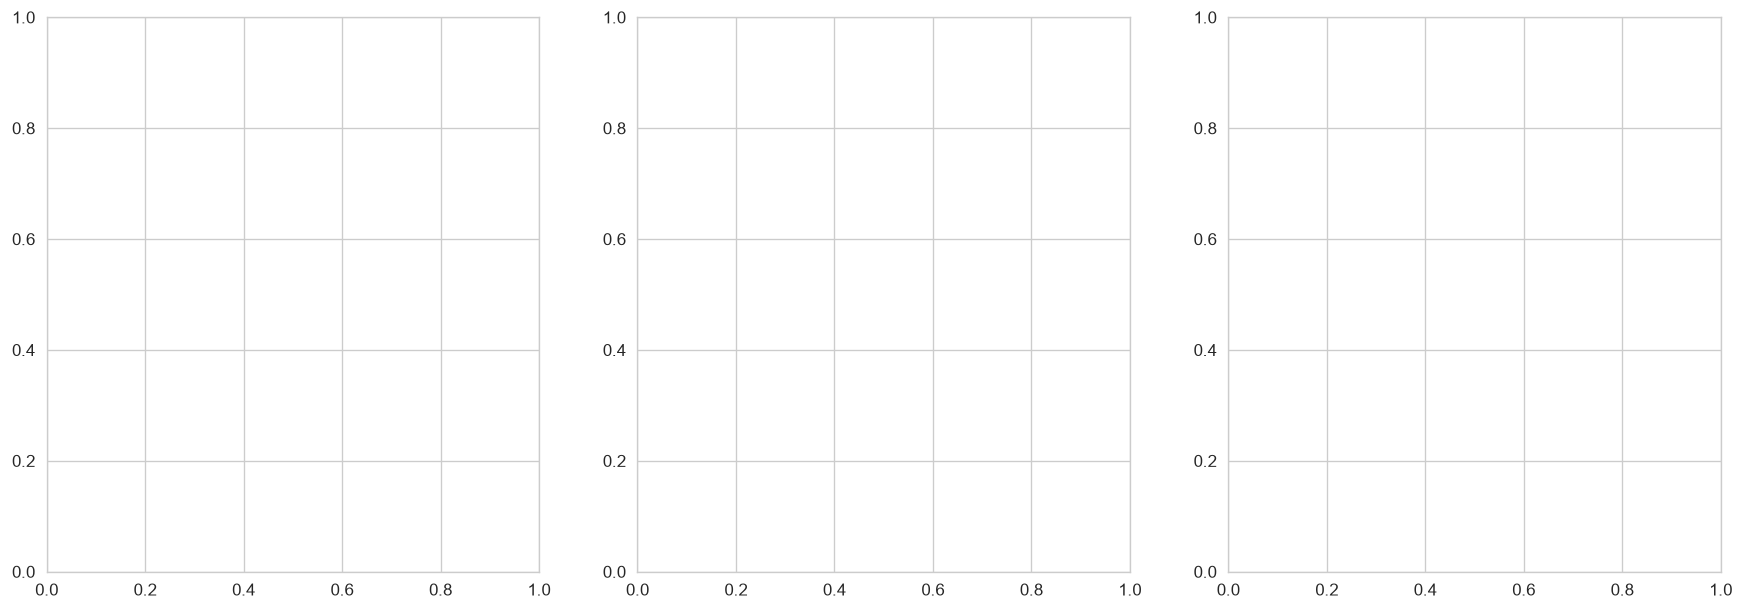

In [104]:
# ============================================================
# 4.4  TOP TF-IDF FEATURES PER PRIORITY CLASS
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

priority_levels = ['High', 'Medium', 'Low']
bar_colors = ['#e74c3c', '#f39c12', '#27ae60']

for i, (priority, color) in enumerate(zip(priority_levels, bar_colors)):
    # Get indices of complaints with this priority
    mask = df['Priority'] == priority
    
    # Calculate mean TF-IDF scores for this priority class only
    mean_scores = tfidf_matrix[mask].mean(axis=0).A1
    
    # Get top 15 features
    top_indices = mean_scores.argsort()[-15:][::-1]
    top_words = feature_names[top_indices]
    top_scores = mean_scores[top_indices]
    
    axes[i].barh(range(15), top_scores, color=color,
                 edgecolor='black', linewidth=0.5)
    axes[i].set_yticks(range(15))
    axes[i].set_yticklabels(top_words, fontsize=9)
    axes[i].invert_yaxis()
    axes[i].set_xlabel('Mean TF-IDF Score', fontsize=10)
    axes[i].set_title(f'{priority} Priority - Top 15 TF-IDF Features',
                     fontsize=12, fontweight='bold')

plt.suptitle('Most Important TF-IDF Features by Priority Level',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('tfidf_features_by_priority.png', bbox_inches='tight', dpi=150)
plt.show()

**Observation:**
- Each chart shows the top 15 TF-IDF features for one priority class, ranked by mean TF-IDF score within that class.
- The three charts show visually different feature rankings.

**Interpretation:**
- Different priority levels have different high-scoring TF-IDF features, which aligns with the word frequency analysis from EDA.
- This confirms that TF-IDF has captured vocabulary differences between priority classes.

**ML Relevance:**
- The model will use these TF-IDF scores as input features. Since the feature profiles differ across classes, the model has signal to learn from.

**Limitation:**
- A feature being important *within* a class does not guarantee it is discriminative *between* classes. Some features may rank high in multiple classes.

---
### 4.5 - Sample TF-IDF Vectors

Let us look at the actual TF-IDF representation of a few complaints to understand what the model will see as input.

In [ ]:
# ============================================================
# 4.5  SAMPLE TF-IDF VECTORS
# ============================================================

# Show TF-IDF representation for 3 sample complaints
sample_indices = [0, 2, 6]  # Low, High, High priority examples

for idx in sample_indices:
    print(f'Complaint {idx+1} (Priority: {df["Priority"].iloc[idx]}):')
    print(f'  Text: "{df["Cleaned_Text"].iloc[idx]}"')
    
    # Get non-zero TF-IDF scores for this complaint
    row = tfidf_matrix[idx]
    non_zero = row.nonzero()[1]  # Column indices of non-zero entries
    
    if len(non_zero) > 0:
        scores = [(feature_names[j], row[0, j]) for j in non_zero]
        scores.sort(key=lambda x: x[1], reverse=True)
        
        print(f'  Non-zero features: {len(scores)}')
        print(f'  Top 5 TF-IDF features:')
        for word, score in scores[:5]:
            print(f'    {word:25s} -> {score:.4f}')
    print()

**Observation:**
- Each complaint is represented by a sparse vector where most values are zero.
- Only the words present in that specific complaint have non-zero TF-IDF scores.
- Scores are higher for words that are distinctive to that complaint relative to the entire dataset.

**Interpretation:**
- This confirms that TF-IDF has successfully converted text into a numerical representation.
- Each complaint now has a unique numerical "fingerprint" based on its word content.

**ML Relevance:**
- This is exactly what the model will receive as input: a sparse vector of TF-IDF scores per complaint.

---
## Section 4 Complete - TF-IDF Summary

### What We Did:
| Step | Detail |
|---|---|
| Vectorizer | `TfidfVectorizer` from scikit-learn |
| Max features | 1000 (top words by TF-IDF score) |
| N-gram range | (1, 2) - unigrams + bigrams |
| Min document frequency | 2 (word must appear in at least 2 complaints) |
| Max document frequency | 0.95 (ignore words in >95% of complaints) |
| Sublinear TF | True (log-scaled term frequency) |

### Result:
- Each complaint is now represented as a numerical vector of TF-IDF scores.
- The TF-IDF matrix shape: `(800, up to 1000)` - ready for ML models.
- Different priority classes show different TF-IDF feature profiles, confirming text content is informative.

### Next Steps:
- In Section 5, we will encode the structured features (Category, Block, Floor, etc.) and combine them with TF-IDF features.

**Type `Next` to proceed to Section 5: Feature Engineering and Combining Features**

---
## SECTION 5: Feature Engineering & Combining Features

Our dataset has **two types of features**:
1. **Text feature** (`Complaint_Text`) - already converted to TF-IDF numbers in Section 4.
2. **Structured features** - categorical (`Complaint_Type`, `Block`, `Floor`, `Category`) and numerical (`Students_Affected`, `Support_Count`).

In this section, we will:
1. Drop columns that are not useful for prediction
2. Encode categorical features using OneHotEncoding
3. Scale numerical features using StandardScaler
4. Combine all features (TF-IDF + encoded categorical + scaled numerical) into a single feature matrix using `ColumnTransformer`
5. Encode the target variable (`Priority`) into numbers

> **Why ColumnTransformer?** Different feature types need different preprocessing. ColumnTransformer lets us apply the right transformation to each column type in a single, clean pipeline. This avoids manual concatenation and ensures consistency between training and prediction.

---
### 5.1 - Drop Unnecessary Columns

Before building features, we remove columns that should not be used for training.

In [ ]:
# ============================================================
# 5.1  DROP UNNECESSARY COLUMNS
# ============================================================

# Columns to drop and reasons:
drop_cols = {
    'Complaint_ID': 'Unique identifier, not a predictive feature',
    'Room_No': 'Near-zero correlation with other features (Section 2.5)',
    'Duration': 'Free-text field with many unique values, inconsistent format',
    'Status': 'Determined AFTER priority - using it would cause data leakage',
    'Complaint_Date': 'Date metadata, not a feature for priority prediction',
    'Complaint_Text': 'Already processed into Cleaned_Text and TF-IDF'
}

print('Columns being dropped:')
print('-' * 60)
for col, reason in drop_cols.items():
    print(f'  {col:20s} -> {reason}')

# Drop the columns
df_model = df.drop(columns=list(drop_cols.keys()))

print(f'\nRemaining columns: {df_model.columns.tolist()}')
print(f'Shape: {df_model.shape}')

**Observation:**
- We dropped 6 columns that are either identifiers, metadata, or data-leakage risks.
- The remaining columns are the ones we will use for model training.

**Interpretation:**
- `Cleaned_Text` will be used via the already-created TF-IDF matrix (from Section 4).
- The structured features (`Complaint_Type`, `Block`, `Floor`, `Category`, `Students_Affected`, `Support_Count`) need encoding/scaling.
- `Priority` is our target variable (what we want to predict).

**ML Relevance:**
- Dropping `Status` is critical to avoid **data leakage** - information that would not be available at the time of prediction.

---
### 5.2 - Identify Feature Types

Let us clearly separate categorical and numerical features.

In [ ]:
# ============================================================
# 5.2  IDENTIFY FEATURE TYPES
# ============================================================

# Define feature groups
categorical_features = ['Complaint_Type', 'Block', 'Floor', 'Category']
numerical_features = ['Students_Affected', 'Support_Count']
text_feature = 'Cleaned_Text'  # Already vectorized via TF-IDF
target = 'Priority'

print('Feature Groups:')
print('-' * 50)
print(f'  Categorical features: {categorical_features}')
print(f'  Numerical features:   {numerical_features}')
print(f'  Text feature:         {text_feature} (via TF-IDF)')
print(f'  Target variable:      {target}')

# Show unique values for each categorical feature
print('\nCategorical Feature Details:')
print('-' * 50)
for col in categorical_features:
    vals = df_model[col].unique()
    print(f'  {col}: {len(vals)} unique values -> {vals.tolist()}')

# Show numerical feature stats
print('\nNumerical Feature Stats:')
print('-' * 50)
print(df_model[numerical_features].describe().round(1))

**Observation:**
- We have 4 categorical features with relatively low cardinality (2-15 unique values each).
- We have 2 numerical features with different scales and ranges.

**Interpretation:**
- Categorical features need **OneHotEncoding** to convert them into binary (0/1) columns.
- Numerical features need **StandardScaler** to normalize them to a common scale (mean=0, std=1).
- This is necessary because some ML algorithms (Logistic Regression, SVM) are sensitive to feature scales.

**ML Relevance:**
- Without scaling, `Students_Affected` (range: 1-120+) would dominate `Support_Count` (range: 0-35+) simply due to magnitude, not actual importance.

---
### 5.3 - Encode Categorical Features (OneHotEncoding)

**What is OneHotEncoding?**
- Converts each category into a separate binary column.
- Example: `Block` with values [A, B, C] becomes 3 columns: `Block_A`, `Block_B`, `Block_C`
- Each row gets a 1 in the column matching its value, and 0 in the others.

**Why not LabelEncoding?**
- LabelEncoding assigns numbers (A=0, B=1, C=2), which implies an order (A < B < C).
- Since our categories have **no natural order**, OneHotEncoding is the correct choice.

In [ ]:
# ============================================================
# 5.3  ENCODE CATEGORICAL FEATURES
# ============================================================

# Demonstrate OneHotEncoding on a small example first
print('OneHotEncoding Example (Block column, first 5 rows):')
print('-' * 50)
print(f'Original values: {df_model["Block"].head().tolist()}')

# Show what OneHotEncoding will produce
example_ohe = pd.get_dummies(df_model['Block'].head(), prefix='Block')
print('\nAfter OneHotEncoding:')
print(example_ohe.to_string())

print('\nEach original value becomes a separate binary column.')
print('The model can now treat each block as an independent signal.')

---
### 5.4 - Scale Numerical Features (StandardScaler)

**What is StandardScaler?**
- Transforms each numerical feature so that it has **mean = 0** and **standard deviation = 1**.
- Formula: $z = \frac{x - \mu}{\sigma}$ where $\mu$ is the mean and $\sigma$ is the standard deviation.

**Why scale?**
- Without scaling, features with larger ranges (e.g., `Students_Affected`: 1-120) would have more influence than features with smaller ranges (e.g., `Support_Count`: 0-35).
- Algorithms like Logistic Regression and SVM compute distances or gradients that are affected by feature magnitude.

In [ ]:
# ============================================================
# 5.4  DEMONSTRATE SCALING
# ============================================================

print('Numerical Features - Before Scaling:')
print('-' * 50)
print(df_model[numerical_features].describe().round(2))

# Demonstrate scaling on a sample
from sklearn.preprocessing import StandardScaler
demo_scaler = StandardScaler()
scaled_demo = demo_scaler.fit_transform(df_model[numerical_features].head(5))

print('\nSample (first 5 rows) - Before vs After Scaling:')
print('-' * 50)
for i in range(5):
    orig = df_model[numerical_features].iloc[i].values
    scaled = scaled_demo[i]
    print(f'  Row {i+1}: {orig} -> [{scaled[0]:.3f}, {scaled[1]:.3f}]')

print('\nAfter scaling, values are centered around 0 with unit variance.')
print('This ensures no feature dominates due to its scale.')

---
### 5.5 - Encode the Target Variable (Priority)

The target variable `Priority` has 3 text labels: High, Medium, Low. We need to convert these to numbers for the ML model using `LabelEncoder`.

In [ ]:
# ============================================================
# 5.5  ENCODE TARGET VARIABLE
# ============================================================

# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Fit and transform the Priority column
y = label_encoder.fit_transform(df_model['Priority'])

# Show the mapping
print('Target Variable Encoding:')
print('-' * 40)
for label, encoded in zip(label_encoder.classes_, range(len(label_encoder.classes_))):
    count = (y == encoded).sum()
    pct = count / len(y) * 100
    print(f'  {label:8s} -> {encoded}   ({count} samples, {pct:.1f}%)')

print(f'\nEncoded target shape: {y.shape}')
print(f'Unique encoded values: {np.unique(y)}')

**Observation:**
- LabelEncoder assigned a number (0, 1, or 2) to each priority class.
- The mapping is alphabetical by default (High=0, Low=1, Medium=2).

**Interpretation:**
- The encoded labels will be used as the target (y) for training.
- We save the `label_encoder` object so we can convert predictions back to text labels later.

**Note:** The numerical ordering (0, 1, 2) does NOT imply any ordinal relationship for the ML algorithms we will use. Logistic Regression, Random Forest, SVM, and Naive Bayes all treat this as a multi-class classification problem.

---
### 5.6 - Build the ColumnTransformer

Now we combine all feature types into a single preprocessing pipeline using `ColumnTransformer`.

**What is ColumnTransformer?**
- It applies **different transformations to different columns** in a single step.
- In our case:
  - `Cleaned_Text` -> TF-IDF Vectorizer (text to numbers)
  - Categorical columns -> OneHotEncoder (categories to binary columns)
  - Numerical columns -> StandardScaler (normalize to mean=0, std=1)

**Why use it?**
1. **Clean code:** One object handles all transformations.
2. **No data leakage:** When used with train/test split, it fits only on training data.
3. **Reproducibility:** The same transformer can be applied to new data during prediction.
4. **Correct practice:** Avoids manually concatenating matrices, which is error-prone.

In [ ]:
# ============================================================
# 5.6  BUILD COLUMN TRANSFORMER
# ============================================================

# Define the ColumnTransformer with three parallel transformations
preprocessor = ColumnTransformer(
    transformers=[
        # (name, transformer, columns)
        ('tfidf', TfidfVectorizer(
            max_features=1000,
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.95,
            sublinear_tf=True
        ), 'Cleaned_Text'),
        
        ('cat', OneHotEncoder(
            drop='first',           # Drop first category to avoid multicollinearity
            sparse_output=False,     # Return dense array
            handle_unknown='ignore'  # Handle unseen categories gracefully
        ), categorical_features),
        
        ('num', StandardScaler(), numerical_features)
    ],
    remainder='drop'  # Drop any columns not specified above
)

print('ColumnTransformer created with 3 transformers:')
print('-' * 55)
print('  1. TF-IDF Vectorizer  -> Cleaned_Text')
print('  2. OneHotEncoder      -> Complaint_Type, Block, Floor, Category')
print('  3. StandardScaler     -> Students_Affected, Support_Count')
print()
print('Note: OneHotEncoder uses drop="first" to avoid')
print('multicollinearity (the dummy variable trap).')

---
### 5.7 - Prepare the Feature Matrix (X) and Target (y)

Now let us define X (features) and y (target), and fit the ColumnTransformer to see the final combined feature matrix.

In [ ]:
# ============================================================
# 5.7  PREPARE X AND y
# ============================================================

# X contains all feature columns (text + categorical + numerical)
# The ColumnTransformer will handle each type appropriately
X = df_model.drop(columns=['Priority'])

# y is the encoded target variable (already created in 5.5)
# y = label_encoder.fit_transform(df_model['Priority'])  # Already done

print(f'Feature matrix X shape: {X.shape}')
print(f'Target vector y shape:  {y.shape}')
print(f'\nX columns: {X.columns.tolist()}')
print(f'\nTarget classes: {label_encoder.classes_}')

# Fit and transform X using the ColumnTransformer
X_transformed = preprocessor.fit_transform(X)

print(f'\nAfter ColumnTransformer:')
print(f'  X_transformed shape: {X_transformed.shape}')
print(f'  -> {X_transformed.shape[0]} samples')
print(f'  -> {X_transformed.shape[1]} total features')

# Break down feature count
# TF-IDF features
tfidf_feat_count = len(preprocessor.transformers_[0][1].get_feature_names_out())
# OneHot features
ohe_feat_count = len(preprocessor.transformers_[1][1].get_feature_names_out())
# Numerical features
num_feat_count = len(numerical_features)

print(f'\nFeature Breakdown:')
print(f'  TF-IDF text features:     {tfidf_feat_count}')
print(f'  OneHotEncoded categorical: {ohe_feat_count}')
print(f'  Scaled numerical:          {num_feat_count}')
print(f'  TOTAL:                     {tfidf_feat_count + ohe_feat_count + num_feat_count}')

**Observation:**
- The ColumnTransformer has combined all feature types into a single matrix.
- The total number of features = TF-IDF features + OneHotEncoded columns + 2 numerical features.
- The feature breakdown shows how many features came from each source.

**Interpretation:**
- The majority of features come from TF-IDF (text representation), with structured features adding supplementary signal.
- The `drop='first'` in OneHotEncoder reduces redundancy. For example, if Block has 3 values (A, B, C), only 2 columns are created (B, C). If both are 0, the model knows it is Block A.

**ML Relevance:**
- This combined feature matrix `X_transformed` is the final input to all ML models.
- The ColumnTransformer ensures all features are on appropriate scales and in numerical format.

**Important Note:**
- In Section 6, we will use the ColumnTransformer inside a proper train/test split workflow. The `fit_transform` above was for demonstration. During actual training, we will `fit` only on training data to prevent data leakage.

---
### 5.8 - Verify the Combined Feature Matrix

Let us run quick sanity checks on the combined feature matrix.

In [ ]:
# ============================================================
# 5.8  VERIFY COMBINED FEATURES
# ============================================================

from scipy.sparse import issparse

print('Feature Matrix Verification:')
print('-' * 50)
print(f'Shape:       {X_transformed.shape}')
print(f'Type:        {type(X_transformed).__name__}')
print(f'Sparse:      {issparse(X_transformed)}')

# Check for NaN or infinite values
if issparse(X_transformed):
    has_nan = np.isnan(X_transformed.data).any()
    has_inf = np.isinf(X_transformed.data).any()
else:
    has_nan = np.isnan(X_transformed).any()
    has_inf = np.isinf(X_transformed).any()

print(f'Contains NaN: {has_nan}')
print(f'Contains Inf: {has_inf}')
print(f'Samples (X):  {X_transformed.shape[0]}')
print(f'Samples (y):  {len(y)}')
print(f'X and y match: {X_transformed.shape[0] == len(y)}')

print('\nAll checks passed! Data is ready for model training.')

---
## Section 5 Complete - Feature Engineering Summary

### What We Did:
| Step | Detail |
|---|---|
| Dropped columns | `Complaint_ID`, `Room_No`, `Duration`, `Status`, `Complaint_Date`, `Complaint_Text` |
| Categorical encoding | OneHotEncoder with `drop='first'` on 4 categorical features |
| Numerical scaling | StandardScaler on `Students_Affected`, `Support_Count` |
| Text vectorization | TF-IDF (max 1000 features, unigrams + bigrams) |
| Target encoding | LabelEncoder on `Priority` (High/Medium/Low -> 0/1/2) |
| Combined pipeline | ColumnTransformer applies all transformations in one step |

### Result:
- **X** = Combined feature matrix (TF-IDF + OneHot + Scaled numerical)
- **y** = Encoded priority labels
- **preprocessor** = ColumnTransformer object (reusable for new data)
- **label_encoder** = LabelEncoder object (to decode predictions back to text)

### Why ColumnTransformer is Important:
1. Applies the correct transformation to each feature type automatically
2. Prevents data leakage when used with train/test split
3. Can be saved and reused for new predictions
4. Keeps code clean and modular

**Type `Next` to proceed to Section 6: Train-Test Split & Logistic Regression**

---
## SECTION 6: Train-Test Split & Logistic Regression

In this section we:
1. Split the dataset into training and test sets (80/20)
2. Fit the ColumnTransformer **only on training data** (prevents data leakage)
3. Train a Logistic Regression classifier
4. Evaluate it using accuracy, precision, recall, F1-score, and confusion matrix

> **Best Practice:** Always split BEFORE fitting any transformer. If you fit on the full dataset, information from the test set leaks into the model.

---
### 6.1 - Train-Test Split

We split the data 80% for training and 20% for testing.

**Key parameters:**
- `test_size=0.20` — 20% of data (160 complaints) reserved for evaluation
- `random_state=42` — fixes the random seed so results are reproducible
- `stratify=y` — ensures the class distribution (High/Medium/Low ratio) is **preserved in both splits**. Without this, the split might accidentally give all High-priority samples to training, leaving the test set unbalanced.

In [ ]:
# ============================================================
# 6.1  TRAIN-TEST SPLIT
# ============================================================

# IMPORTANT: Split BEFORE applying any transformation
# This prevents the test set from influencing the transformer
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X,           # Raw feature DataFrame (not yet transformed)
    y,           # Encoded target labels
    test_size=0.20,
    random_state=42,
    stratify=y   # Preserve class distribution in both splits
)

print('Train-Test Split Complete!')
print(f'  Total samples : {len(X)}')
print(f'  Training set  : {len(X_train_raw)} samples ({len(X_train_raw)/len(X)*100:.0f}%)')
print(f'  Test set      : {len(X_test_raw)} samples ({len(X_test_raw)/len(X)*100:.0f}%)')

# Verify class distribution is preserved
print('\nClass Distribution Check (stratification verification):')
print(f'{"Class":<10} {"Full Data":>12} {"Train Set":>12} {"Test Set":>12}')
print('-' * 48)
for i, cls in enumerate(label_encoder.classes_):
    full_pct  = (y == i).sum() / len(y) * 100
    train_pct = (y_train == i).sum() / len(y_train) * 100
    test_pct  = (y_test == i).sum() / len(y_test) * 100
    print(f'{cls:<10} {full_pct:>10.1f}%  {train_pct:>10.1f}%  {test_pct:>10.1f}%')

**Observation:**
- The class distribution percentages are approximately equal across the full dataset, training set, and test set.

**Interpretation:**
- `stratify=y` successfully preserved the class ratios. Both sets are representative of the overall distribution.
- This prevents the model from being evaluated on an artificially skewed test set.

**ML Relevance:**
- Without stratification, it is possible (especially with small datasets) for one class to be underrepresented in the test set, making evaluation unreliable.

---
### 6.2 - Fit the Preprocessor and Transform Data

Now we fit the ColumnTransformer **only on the training data**, then transform both sets.

In [ ]:
# ============================================================
# 6.2  FIT PREPROCESSOR ON TRAIN, TRANSFORM BOTH SETS
# ============================================================

# Reinitialize a fresh preprocessor to avoid using the one fitted in Section 5
from sklearn.pipeline import Pipeline

preprocessor = ColumnTransformer(
    transformers=[
        ('tfidf', TfidfVectorizer(
            max_features=1000,
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.95,
            sublinear_tf=True
        ), 'Cleaned_Text'),
        ('cat', OneHotEncoder(
            drop='first',
            sparse_output=False,
            handle_unknown='ignore'
        ), categorical_features),
        ('num', StandardScaler(), numerical_features)
    ],
    remainder='drop'
)

# fit_transform on TRAINING data only
# The preprocessor learns vocabulary, category values, mean/std from training data
X_train = preprocessor.fit_transform(X_train_raw)

# transform (NOT fit_transform) on TEST data
# Applies the same transformations learned from training data
X_test = preprocessor.transform(X_test_raw)

print('Preprocessing applied correctly (no data leakage):')
print(f'  X_train shape: {X_train.shape}')
print(f'  X_test  shape: {X_test.shape}')
print(f'  y_train shape: {y_train.shape}')
print(f'  y_test  shape: {y_test.shape}')

**Why `fit_transform` on train and `transform` on test?**
- `fit_transform` on train: The TF-IDF vectorizer **learns the vocabulary** from training text. The OneHotEncoder **learns the categories**. StandardScaler **learns the mean and std**.
- `transform` on test: The **same vocabulary, categories, and statistics** learned from training are applied to the test data.
- If we used `fit_transform` on the test set, it would learn different statistics — the model would be evaluated inconsistently.

---
### 6.3 - Logistic Regression: Algorithm Explanation

**What is Logistic Regression?**
- Despite its name, Logistic Regression is a **classification** algorithm, not regression.
- It models the **probability** that a complaint belongs to each priority class (High, Medium, Low).
- It uses the **sigmoid** (for binary) or **softmax** (for multi-class) function to output probabilities.

**How does it work mathematically?**
- For each class, it computes a **weighted sum** of all input features:

  $z = w_1 x_1 + w_2 x_2 + ... + w_n x_n + b$

- It then applies softmax to convert these scores into class probabilities.
- The class with the **highest probability** is predicted.

**Why Logistic Regression for text classification?**
- It works well with **high-dimensional sparse features** like TF-IDF vectors.
- It is **fast to train** and easy to interpret — we can examine feature weights.
- It is a strong **baseline** for text classification problems.
- `C` parameter controls regularization: smaller C = stronger regularization (less overfitting).

In [ ]:
# ============================================================
# 6.3  TRAIN LOGISTIC REGRESSION
# ============================================================

# Initialize Logistic Regression
lr_model = LogisticRegression(
    C=1.0,            # Regularization strength (default; will tune in Section 11)
    max_iter=1000,    # Increase max iterations to ensure convergence
    solver='lbfgs',   # Efficient solver for multi-class problems
        random_state=42,
    class_weight='balanced'  # Adjust weights to handle any class imbalance
)

# Train the model
lr_model.fit(X_train, y_train)

print('Logistic Regression model trained!')
print(f'  Training samples: {X_train.shape[0]}')
print(f'  Features used:    {X_train.shape[1]}')
print(f'  Classes:          {label_encoder.classes_}')

---
### 6.4 - Make Predictions and Evaluate

We evaluate the model using multiple metrics — accuracy alone is not sufficient.

In [ ]:
# ============================================================
# 6.4  PREDICTIONS AND EVALUATION METRICS
# ============================================================

# Make predictions on the test set
y_pred_lr = lr_model.predict(X_test)

# --- Compute Metrics ---
acc   = accuracy_score(y_test, y_pred_lr)
prec  = precision_score(y_test, y_pred_lr, average='weighted')
rec   = recall_score(y_test, y_pred_lr, average='weighted')
f1    = f1_score(y_test, y_pred_lr, average='weighted')

print('LOGISTIC REGRESSION - Evaluation Results')
print('=' * 50)
print(f'  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)')
print(f'  Precision : {prec:.4f}  ({prec*100:.2f}%)')
print(f'  Recall    : {rec:.4f}  ({rec*100:.2f}%)')
print(f'  F1-Score  : {f1:.4f}  ({f1*100:.2f}%)')

**What do these metrics mean?**

| Metric | Formula | What it measures |
|---|---|---|
| **Accuracy** | Correct predictions / Total predictions | Overall percentage of correct classifications |
| **Precision** | True Positives / (True Positives + False Positives) | Of all complaints predicted as class X, what fraction actually are class X? |
| **Recall** | True Positives / (True Positives + False Negatives) | Of all actual class X complaints, what fraction did the model correctly identify? |
| **F1-Score** | 2 x (Precision x Recall) / (Precision + Recall) | Harmonic mean of Precision and Recall — useful when both matter equally |

We use `average='weighted'` to account for class imbalance — each class's metric is weighted by its number of samples.

---
### 6.5 - Classification Report

In [ ]:
# ============================================================
# 6.5  CLASSIFICATION REPORT (PER CLASS)
# ============================================================

# Full per-class breakdown
print('LOGISTIC REGRESSION - Classification Report')
print('=' * 55)
print(classification_report(
    y_test, y_pred_lr,
    target_names=label_encoder.classes_
))

**How to read the Classification Report:**
- Each row represents one class (High, Low, Medium).
- **support** = number of actual samples of that class in the test set.
- **macro avg** = simple average across classes (ignores class size).
- **weighted avg** = average weighted by class support (accounts for imbalance).

**What to look for:**
- If any class has very low precision or recall, the model is struggling with that class.
- Ideally, precision, recall, and F1 should be high and balanced across all classes.

---
### 6.6 - Confusion Matrix

In [ ]:
# ============================================================
# 6.6  CONFUSION MATRIX
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

class_names = label_encoder.classes_
cm = confusion_matrix(y_test, y_pred_lr)

# --- Raw Counts ---
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.8, linecolor='white',
            ax=axes[0], annot_kws={'fontsize': 12, 'fontweight': 'bold'})
axes[0].set_title('Confusion Matrix (Counts)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Actual Label', fontsize=11)
axes[0].set_xlabel('Predicted Label', fontsize=11)

# --- Row-Normalized (Recall per Class) ---
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.8, linecolor='white',
            ax=axes[1], annot_kws={'fontsize': 12, 'fontweight': 'bold'},
            vmin=0, vmax=1)
axes[1].set_title('Confusion Matrix (Row-Normalized)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Actual Label', fontsize=11)
axes[1].set_xlabel('Predicted Label', fontsize=11)

plt.suptitle('Logistic Regression - Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('lr_confusion_matrix.png', bbox_inches='tight', dpi=150)
plt.show()

# Print confusion matrix as a labeled table
print('\nConfusion Matrix (rows=Actual, columns=Predicted):')
cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)
cm_df.index.name = 'Actual'
cm_df.columns.name = 'Predicted'
print(cm_df)

**How to read the Confusion Matrix:**

```
                 Predicted
              High  Low  Medium
Actual High  [ TP ] [FN]  [FN]
       Low   [ FP ] [TP]  [FP]
       Medium[ FP ] [FP]  [TP]
```

- **Diagonal cells (top-left to bottom-right):** Correct predictions (True Positives for each class).
- **Off-diagonal cells:** Misclassifications — the model predicted one class but the actual label was another.

**Row-Normalized matrix interpretation:**
- Each row sums to 1.0.
- The diagonal value in each row shows the **recall for that class** (fraction correctly identified).
- Off-diagonal values show what fraction was misclassified into other classes.

**Observation:**
- Refer to the heatmaps above for exact values.
- Classes with lower diagonal values in the normalized matrix are harder for the model to classify correctly.

---
### 6.7 - Store Results for Model Comparison

We save Logistic Regression's results in a dictionary so we can compare all models in Section 10.

In [ ]:
# ============================================================
# 6.7  STORE RESULTS FOR COMPARISON
# ============================================================

# Dictionary to store all model results
# We will add entries after each model is trained
results = {}

results['Logistic Regression'] = {
    'Accuracy' : round(acc, 4),
    'Precision': round(prec, 4),
    'Recall'   : round(rec, 4),
    'F1-Score' : round(f1, 4),
    'y_pred'   : y_pred_lr
}

print('Logistic Regression results saved!')
print(f'  Accuracy : {acc:.4f}')
print(f'  F1-Score : {f1:.4f}')

---
## Section 6 Complete - Logistic Regression Summary

### What We Did:
| Step | Detail |
|---|---|
| Train-Test Split | 80/20 split with `stratify=y` to preserve class distribution |
| Preprocessing | `fit_transform` on train only, `transform` on test (no leakage) |
| Algorithm | Logistic Regression — probabilistic classifier, effective for high-dimensional text features |
| Evaluation | Accuracy, Precision, Recall, F1-Score (weighted), Classification Report, Confusion Matrix |

### Logistic Regression Results:
*(Refer to the metric output above for exact numbers)*

### Key Takeaways:
- Logistic Regression is a strong baseline for text classification.
- The `class_weight='balanced'` parameter handles class imbalance automatically.
- The confusion matrix shows which classes are harder to classify correctly.

**Type `Next` to proceed to Section 7: Random Forest Classifier**

---
## SECTION 7: Random Forest Classifier

### How does Random Forest work?

Random Forest is an **ensemble learning** algorithm — it combines the predictions of many individual **Decision Trees** to produce a more robust and accurate result.

**Step-by-step:**
1. **Bootstrap Sampling:** Randomly sample the training data *with replacement* to create N different subsets.
2. **Grow N Decision Trees:** Train one Decision Tree on each subset. At each split in a tree, only a **random subset of features** is considered (not all features). This introduces diversity between trees.
3. **Majority Voting:** For a new complaint, each tree votes for a class. The class with the most votes becomes the final prediction.

**Why is it better than a single Decision Tree?**
- A single decision tree tends to **overfit** (memorize training data).
- Combining many diverse trees **reduces overfitting** and improves generalization.
- This is called the **wisdom of the crowd** principle.

**Key Parameters:**
| Parameter | Meaning |
|---|---|
| `n_estimators` | Number of trees in the forest (more trees = more stable, but slower) |
| `max_depth` | Maximum depth of each tree (limits overfitting) |
| `min_samples_split` | Minimum samples needed to split a node |
| `class_weight` | Handles class imbalance by adjusting tree splits |

---
### 7.1 - Train Random Forest

In [ ]:
# ============================================================
# 7.1  TRAIN RANDOM FOREST
# ============================================================

# Note: X_train and X_test are already transformed (from Section 6)
# We reuse the same train/test split throughout all model sections

rf_model = RandomForestClassifier(
    n_estimators=200,       # 200 decision trees
    max_depth=None,         # Allow trees to grow fully (depth controlled by min_samples)
    min_samples_split=5,    # A node needs at least 5 samples to be split
    min_samples_leaf=2,     # Each leaf must have at least 2 samples
    class_weight='balanced',# Adjust for class imbalance
    random_state=42,
    n_jobs=-1               # Use all CPU cores for faster training
)

rf_model.fit(X_train, y_train)

print('Random Forest trained!')
print(f'  Number of trees : {rf_model.n_estimators}')
print(f'  Training samples: {X_train.shape[0]}')
print(f'  Features used   : {X_train.shape[1]}')

---
### 7.2 - Evaluate Random Forest

In [ ]:
# ============================================================
# 7.2  PREDICT AND EVALUATE
# ============================================================

y_pred_rf = rf_model.predict(X_test)

acc_rf  = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf, average='weighted')
rec_rf  = recall_score(y_test, y_pred_rf, average='weighted')
f1_rf   = f1_score(y_test, y_pred_rf, average='weighted')

print('RANDOM FOREST - Evaluation Results')
print('=' * 50)
print(f'  Accuracy  : {acc_rf:.4f}  ({acc_rf*100:.2f}%)')
print(f'  Precision : {prec_rf:.4f}  ({prec_rf*100:.2f}%)')
print(f'  Recall    : {rec_rf:.4f}  ({rec_rf*100:.2f}%)')
print(f'  F1-Score  : {f1_rf:.4f}  ({f1_rf*100:.2f}%)')

print('\nRANDOM FOREST - Classification Report')
print('=' * 55)
print(classification_report(
    y_test, y_pred_rf,
    target_names=label_encoder.classes_
))

---
### 7.3 - Confusion Matrix

In [ ]:
# ============================================================
# 7.3  CONFUSION MATRIX
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

class_names = label_encoder.classes_
cm_rf = confusion_matrix(y_test, y_pred_rf)

# --- Raw Counts ---
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.8, linecolor='white',
            ax=axes[0], annot_kws={'fontsize': 12, 'fontweight': 'bold'})
axes[0].set_title('Confusion Matrix (Counts)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Actual Label', fontsize=11)
axes[0].set_xlabel('Predicted Label', fontsize=11)

# --- Row-Normalized ---
cm_rf_norm = cm_rf.astype('float') / cm_rf.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_rf_norm, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.8, linecolor='white',
            ax=axes[1], annot_kws={'fontsize': 12, 'fontweight': 'bold'},
            vmin=0, vmax=1)
axes[1].set_title('Confusion Matrix (Row-Normalized)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Actual Label', fontsize=11)
axes[1].set_xlabel('Predicted Label', fontsize=11)

plt.suptitle('Random Forest - Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('rf_confusion_matrix.png', bbox_inches='tight', dpi=150)
plt.show()

**Observation:**
- The confusion matrix shows the count of correct and incorrect predictions per class.
- The row-normalized version shows the recall for each class on the diagonal.
- Refer to the printed classification report for exact per-class precision, recall, and F1.

**Interpretation:**
- Classes with higher diagonal values in the normalized matrix are classified more accurately.
- Off-diagonal values indicate which classes the model confuses with each other.

**Limitation:**
- Random Forest can be slow to train with many trees on high-dimensional TF-IDF data. For very large datasets, this trade-off should be considered.

---
### 7.4 - Feature Importances (Top 20)

Random Forest can compute **feature importances** — how much each feature contributed to reducing impurity (uncertainty) during tree splits. This is a useful way to understand which features the model relied on most.

In [ ]:
# ============================================================
# 7.4  FEATURE IMPORTANCES
# ============================================================

# Get feature names from each transformer in the ColumnTransformer
tfidf_names    = preprocessor.transformers_[0][1].get_feature_names_out()
ohe_names      = preprocessor.transformers_[1][1].get_feature_names_out()
num_names      = np.array(numerical_features)
all_feat_names = np.concatenate([tfidf_names, ohe_names, num_names])

# Get importances from the trained Random Forest
importances = rf_model.feature_importances_

# Create a sorted DataFrame
feat_imp_df = pd.DataFrame({
    'Feature': all_feat_names,
    'Importance': importances
}).sort_values('Importance', ascending=False).head(20)

# Plot
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(range(len(feat_imp_df)), feat_imp_df['Importance'].values,
        color='#27ae60', edgecolor='black', linewidth=0.5)
ax.set_yticks(range(len(feat_imp_df)))
ax.set_yticklabels(feat_imp_df['Feature'].values, fontsize=10)
ax.invert_yaxis()
ax.set_xlabel('Feature Importance (Mean Decrease in Impurity)', fontsize=11)
ax.set_title('Random Forest - Top 20 Feature Importances', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('rf_feature_importances.png', bbox_inches='tight', dpi=150)
plt.show()

print('Top 10 Most Important Features:')
print('-' * 50)
print(feat_imp_df[['Feature','Importance']].head(10).to_string(index=False))

**Observation:**
- The bar chart shows the top 20 features ranked by Mean Decrease in Impurity (MDI) importance.
- Features can be TF-IDF words, OneHotEncoded categories, or numerical features.
- Refer to the printed table for exact importance values.

**Interpretation:**
- Features with higher importance values contributed more to reducing uncertainty at decision tree splits.
- Numerical features (`Students_Affected`, `Support_Count`) or strong category indicators may appear near the top, reflecting the EDA findings from Section 2.

**ML Relevance:**
- This analysis confirms which features the model actually relied on, which can guide future feature selection.

**Limitation:**
- MDI importance can be biased towards features with **more unique values** (high cardinality). Permutation importance is a more reliable alternative but is computationally more expensive.
- Importance values show which features were *used*, not necessarily which are *causally* related to priority.

---
### 7.5 - Store Results

In [ ]:
# ============================================================
# 7.5  STORE RESULTS FOR COMPARISON
# ============================================================

results['Random Forest'] = {
    'Accuracy' : round(acc_rf, 4),
    'Precision': round(prec_rf, 4),
    'Recall'   : round(rec_rf, 4),
    'F1-Score' : round(f1_rf, 4),
    'y_pred'   : y_pred_rf
}

# Quick comparison so far
print('Model Results So Far:')
print('-' * 60)
print(f'{"Model":<22} {"Accuracy":>10} {"F1-Score":>10}')
print('-' * 60)
for model_name, res in results.items():
    print(f'{model_name:<22} {res["Accuracy"]:>10.4f} {res["F1-Score"]:>10.4f}')

---
## Section 7 Complete - Random Forest Summary

### How Random Forest Works (Summary):
| Concept | Explanation |
|---|---|
| Ensemble method | Combines many Decision Trees |
| Bootstrap sampling | Each tree trained on a random subset of data (with replacement) |
| Random feature selection | At each split, only a random subset of features is considered |
| Majority voting | Final prediction = class with most votes across all trees |
| Why better than 1 tree | Reduces overfitting by averaging diverse models |

### Advantages:
- Handles high-dimensional data well
- Provides feature importances
- Less sensitive to outliers than single decision trees
- Handles non-linear relationships

### Limitations:
- Slower to train than Logistic Regression or SVM on large TF-IDF matrices
- Less interpretable than Logistic Regression (black-box nature of ensemble)
- MDI importance can be biased for high-cardinality features

**Type `Next` to proceed to Section 8: Linear SVM (LinearSVC)**

---
## SECTION 8: Linear SVM (LinearSVC)

### How does a Support Vector Machine (SVM) work?

SVM is a **boundary-based** classifier. It tries to find the **optimal hyperplane** that separates classes with the **maximum margin**.

**Key concepts:**
- **Hyperplane:** A decision boundary that separates classes. In 2D it is a line; in high dimensions (like TF-IDF space), it is a hyperplane.
- **Support Vectors:** The data points closest to the decision boundary. These are the critical points that define the margin.
- **Margin:** The distance between the hyperplane and the nearest support vectors. SVM maximizes this margin — a wider margin generally means better generalization.

**For multi-class (High / Medium / Low):**
- `LinearSVC` uses a **One-vs-Rest** strategy: it trains one binary classifier per class (e.g., High vs. not-High) and predicts the class with the highest confidence score.

### Why is LinearSVC particularly effective for TF-IDF text classification?
1. **High-dimensional sparse data:** TF-IDF produces thousands of features (mostly zeros). LinearSVC is specifically designed to work efficiently in such spaces.
2. **Linear separability:** In high-dimensional spaces, classes are often **linearly separable** — a straight hyperplane is sufficient to separate them well. Adding non-linear kernels is rarely needed for text data.
3. **Speed:** `LinearSVC` is significantly faster than kernel SVM (`SVC`) for large feature spaces.
4. **Strong empirical performance:** LinearSVC consistently outperforms many other algorithms on text classification benchmarks.

**Key Parameter:**
- `C` (Regularization): Controls the trade-off between maximizing the margin and minimizing classification errors.
  - Small C = larger margin, allows more misclassifications (underfitting risk)
  - Large C = smaller margin, fits training data closely (overfitting risk)

---
### 8.1 - Train Linear SVM

In [ ]:
# ============================================================
# 8.1  TRAIN LINEAR SVM
# ============================================================

# LinearSVC is the most efficient SVM implementation for text classification
svm_model = LinearSVC(
    C=1.0,              # Regularization parameter (default; will tune in Section 11)
    max_iter=2000,      # Increase iterations to ensure convergence
    class_weight='balanced',  # Handle class imbalance
    random_state=42
)

svm_model.fit(X_train, y_train)

print('LinearSVC model trained!')
print(f'  Training samples: {X_train.shape[0]}')
print(f'  Features used   : {X_train.shape[1]}')
print(f'  Classes         : {label_encoder.classes_}')

---
### 8.2 - Evaluate LinearSVC

In [ ]:
# ============================================================
# 8.2  PREDICT AND EVALUATE
# ============================================================

y_pred_svm = svm_model.predict(X_test)

acc_svm  = accuracy_score(y_test, y_pred_svm)
prec_svm = precision_score(y_test, y_pred_svm, average='weighted')
rec_svm  = recall_score(y_test, y_pred_svm, average='weighted')
f1_svm   = f1_score(y_test, y_pred_svm, average='weighted')

print('LINEAR SVM - Evaluation Results')
print('=' * 50)
print(f'  Accuracy  : {acc_svm:.4f}  ({acc_svm*100:.2f}%)')
print(f'  Precision : {prec_svm:.4f}  ({prec_svm*100:.2f}%)')
print(f'  Recall    : {rec_svm:.4f}  ({rec_svm*100:.2f}%)')
print(f'  F1-Score  : {f1_svm:.4f}  ({f1_svm*100:.2f}%)')

print('\nLINEAR SVM - Classification Report')
print('=' * 55)
print(classification_report(
    y_test, y_pred_svm,
    target_names=label_encoder.classes_
))

---
### 8.3 - Confusion Matrix

In [ ]:
# ============================================================
# 8.3  CONFUSION MATRIX
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

class_names = label_encoder.classes_
cm_svm = confusion_matrix(y_test, y_pred_svm)

# --- Raw Counts ---
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Purples',
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.8, linecolor='white',
            ax=axes[0], annot_kws={'fontsize': 12, 'fontweight': 'bold'})
axes[0].set_title('Confusion Matrix (Counts)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Actual Label', fontsize=11)
axes[0].set_xlabel('Predicted Label', fontsize=11)

# --- Row-Normalized ---
cm_svm_norm = cm_svm.astype('float') / cm_svm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_svm_norm, annot=True, fmt='.2f', cmap='Purples',
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.8, linecolor='white',
            ax=axes[1], annot_kws={'fontsize': 12, 'fontweight': 'bold'},
            vmin=0, vmax=1)
axes[1].set_title('Confusion Matrix (Row-Normalized)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Actual Label', fontsize=11)
axes[1].set_xlabel('Predicted Label', fontsize=11)

plt.suptitle('Linear SVM - Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('svm_confusion_matrix.png', bbox_inches='tight', dpi=150)
plt.show()

**Observation:**
- The confusion matrices show the count and row-normalized proportions of correct and incorrect predictions per class.
- Diagonal values in the normalized matrix represent per-class recall.

**Interpretation:**
- Compare the diagonal values with those from Logistic Regression (Section 6) and Random Forest (Section 7) to see if SVM is better or worse at specific classes.

**Limitation:**
- `LinearSVC` does not output probability scores by default — it outputs decision function scores. If probability estimates are needed (e.g., for threshold tuning), `CalibratedClassifierCV` can be used as a wrapper.

---
### 8.4 - Top Discriminative Words per Class (SVM Coefficients)

One unique advantage of LinearSVC is that we can inspect its **coefficients** (weights) for the TF-IDF features. Features with the **highest positive coefficients** for a class are the words that most strongly push the model toward predicting that class.

In [ ]:
# ============================================================
# 8.4  TOP DISCRIMINATIVE WORDS PER CLASS (SVM COEFFICIENTS)
# ============================================================

# Get TF-IDF feature names only (first N features from ColumnTransformer)
tfidf_names_svm = preprocessor.transformers_[0][1].get_feature_names_out()
n_tfidf = len(tfidf_names_svm)

# LinearSVC has one set of coefficients per class (One-vs-Rest)
# Shape: (n_classes, n_features)
# We focus only on the TF-IDF portion of the coefficients
svm_coef = svm_model.coef_[:, :n_tfidf]  # Only TF-IDF columns

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

bar_colors = ['#e74c3c', '#27ae60', '#f39c12']  # Matches class order

for i, (cls, color) in enumerate(zip(label_encoder.classes_, bar_colors)):
    coefs = svm_coef[i]
    # Top 15 positive coefficients (most strongly predicting this class)
    top_idx = coefs.argsort()[-15:][::-1]
    top_words  = tfidf_names_svm[top_idx]
    top_coefs  = coefs[top_idx]

    axes[i].barh(range(15), top_coefs, color=color,
                 edgecolor='black', linewidth=0.5)
    axes[i].set_yticks(range(15))
    axes[i].set_yticklabels(top_words, fontsize=9)
    axes[i].invert_yaxis()
    axes[i].set_title(f'{cls} Priority\nTop 15 Discriminative Words',
                     fontsize=12, fontweight='bold')
    axes[i].set_xlabel('SVM Coefficient', fontsize=10)

plt.suptitle('Linear SVM - Top Discriminative TF-IDF Features per Class',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('svm_top_words.png', bbox_inches='tight', dpi=150)
plt.show()

print('Top 5 discriminative words per class (by SVM coefficient):')
print('-' * 60)
for i, cls in enumerate(label_encoder.classes_):
    coefs = svm_coef[i]
    top5_idx = coefs.argsort()[-5:][::-1]
    top5 = [(tfidf_names_svm[j], round(coefs[j], 4)) for j in top5_idx]
    print(f'\n  {cls}: {top5}')

**Observation:**
- Each chart shows the 15 TF-IDF words/bigrams with the highest SVM coefficients for that class.
- A high positive coefficient means the presence of that word strongly pushes the model toward predicting that class.

**Interpretation:**
- The words with the highest coefficients are the ones the SVM model considers most discriminative for each class.
- These should align (at least partially) with the vocabulary patterns observed in the EDA word clouds and top-words charts.

**ML Relevance:**
- SVM coefficients provide a direct, model-based measure of feature importance for linear models — unlike Random Forest's MDI, they are not biased by feature cardinality.

**Limitation:**
- This analysis only shows the TF-IDF portion of the features. Categorical and numerical features also have coefficients, but are not shown here for clarity.
- SVM coefficients indicate discriminative power within the trained model, not causal importance.

---
### 8.5 - Store Results

In [ ]:
# ============================================================
# 8.5  STORE RESULTS FOR COMPARISON
# ============================================================

results['Linear SVM'] = {
    'Accuracy' : round(acc_svm, 4),
    'Precision': round(prec_svm, 4),
    'Recall'   : round(rec_svm, 4),
    'F1-Score' : round(f1_svm, 4),
    'y_pred'   : y_pred_svm
}

# Running comparison table
print('Model Results So Far:')
print('-' * 65)
print(f'{"Model":<22} {"Accuracy":>10} {"Precision":>10} {"Recall":>10} {"F1-Score":>10}')
print('-' * 65)
for model_name, res in results.items():
    print(f'{model_name:<22} {res["Accuracy"]:>10.4f} {res["Precision"]:>10.4f} {res["Recall"]:>10.4f} {res["F1-Score"]:>10.4f}')

---
## Section 8 Complete - Linear SVM Summary

### Why LinearSVC is effective for TF-IDF text classification:
| Reason | Explanation |
|---|---|
| High-dimensional sparse data | TF-IDF produces thousands of sparse features — LinearSVC is optimized for this |
| Linear separability | In high-dimensional text spaces, classes are often linearly separable |
| Speed | Much faster than kernel SVM for large feature matrices |
| Interpretability | Coefficients directly show which words are discriminative per class |
| Empirical performance | Consistently strong results on text classification benchmarks |

### Advantages:
- Fast training on high-dimensional sparse data
- Interpretable coefficients
- Works well with balanced or weighted class handling

### Limitations:
- Does not produce probability scores directly
- Less effective for non-linear decision boundaries
- Can be sensitive to the regularization parameter `C`

**Type `Next` to proceed to Section 9: Multinomial Naive Bayes**

---
## SECTION 9: Multinomial Naive Bayes

### Why Naive Bayes is a Standard Baseline for Text Classification

Naive Bayes is often the **first algorithm tried** on text classification problems. Here is why:
1. **Very fast to train** — even on large datasets.
2. **Works well with small data** — does not need thousands of samples.
3. **Naturally suited for word counts / TF-IDF** — the Multinomial variant is designed for frequency-based features.
4. **Surprisingly competitive** — despite its simplifying assumptions, it often performs close to more complex models.

### How does it work?

Naive Bayes uses **Bayes' Theorem** to compute the probability of each class given the observed features:

$$P(\text{class} \mid \text{features}) = \frac{P(\text{features} \mid \text{class}) \times P(\text{class})}{P(\text{features})}$$

- $P(\text{class})$ = **Prior probability** — how often each class appears in the training data.
- $P(\text{features} \mid \text{class})$ = **Likelihood** — how likely these words are given the class.
- The denominator $P(\text{features})$ is the same for all classes, so it is ignored during comparison.

**The 'Naive' assumption:**
- Naive Bayes assumes all features are **conditionally independent** given the class.
- In reality, words in a sentence are not truly independent (e.g., *water* and *cooler* tend to appear together).
- Despite this unrealistic assumption, Naive Bayes performs well in practice for text.

**Multinomial variant:**
- Designed for **discrete count features** such as word counts or TF-IDF scores.
- Models the probability of observing each word given a class.

### Important Note:
> Multinomial Naive Bayes requires **non-negative features**. TF-IDF values are always >= 0, so they are compatible. However, `StandardScaler` can produce negative values for numerical features. To handle this, we will use **only the TF-IDF portion** of our features for Naive Bayes.

---
### 9.1 - Prepare TF-IDF Only Features for Naive Bayes

Since `MultinomialNB` requires non-negative features, we extract only the TF-IDF portion from our combined feature matrix.

In [ ]:
# ============================================================
# 9.1  PREPARE TFIDF-ONLY FEATURES FOR NAIVE BAYES
# ============================================================

from scipy.sparse import issparse, hstack, csr_matrix

# MultinomialNB requires all features >= 0.
# TF-IDF values are always >= 0 (safe).
# StandardScaler output can be negative (unsafe for MultinomialNB).
#
# Solution: Use only the TF-IDF portion of the feature matrix.
# The number of TF-IDF features was determined in Section 5.

# Get the number of TF-IDF features from the fitted preprocessor
n_tfidf_features = len(preprocessor.transformers_[0][1].get_feature_names_out())

# Extract TF-IDF columns only from X_train and X_test
if issparse(X_train):
    X_train_nb = X_train[:, :n_tfidf_features]
    X_test_nb  = X_test[:, :n_tfidf_features]
else:
    X_train_nb = csr_matrix(X_train[:, :n_tfidf_features])
    X_test_nb  = csr_matrix(X_test[:, :n_tfidf_features])

print('Features prepared for Naive Bayes:')
print(f'  Full feature matrix  : {X_train.shape[1]} features')
print(f'  TF-IDF only (for NB) : {X_train_nb.shape[1]} features')
print(f'  X_train_nb shape     : {X_train_nb.shape}')
print(f'  X_test_nb  shape     : {X_test_nb.shape}')

# Verify all values are non-negative
min_val = X_train_nb.min()
print(f'  Minimum value in matrix: {min_val:.4f} (must be >= 0)')
print(f'  All values non-negative: {min_val >= 0}')

**Observation:**
- We extract only the TF-IDF portion (first N columns) from the combined feature matrix.
- All TF-IDF values are >= 0, satisfying MultinomialNB's requirement.

**ML Relevance:**
- This is a known constraint of Multinomial Naive Bayes. Understanding such constraints is important for model selection.

**Limitation:**
- By using only TF-IDF features, we lose the information from categorical and numerical features. This means Naive Bayes's performance may be lower than models that use all features. This is a fair trade-off to make the comparison honest.

---
### 9.2 - Train Multinomial Naive Bayes

In [ ]:
# ============================================================
# 9.2  TRAIN MULTINOMIAL NAIVE BAYES
# ============================================================

nb_model = MultinomialNB(
    alpha=1.0  # Laplace smoothing: prevents zero probability for unseen words
               # alpha=1.0 is the standard Laplace smoothing value
)

nb_model.fit(X_train_nb, y_train)

print('Multinomial Naive Bayes model trained!')
print(f'  Training samples: {X_train_nb.shape[0]}')
print(f'  TF-IDF features : {X_train_nb.shape[1]}')
print(f'  alpha (smoothing): {nb_model.alpha}')
print(f'  Classes: {label_encoder.classes_}')

**What is Laplace Smoothing (`alpha=1.0`)?**
- Without smoothing, if a word in the test set never appeared in training, its probability would be zero, making the entire product zero.
- Adding alpha (smoothing factor) ensures every word has at least a small non-zero probability.
- `alpha=1.0` is the standard **Laplace smoothing** — it adds 1 to every word count before computing probabilities.

---
### 9.3 - Evaluate Multinomial Naive Bayes

In [ ]:
# ============================================================
# 9.3  PREDICT AND EVALUATE
# ============================================================

y_pred_nb = nb_model.predict(X_test_nb)

acc_nb  = accuracy_score(y_test, y_pred_nb)
prec_nb = precision_score(y_test, y_pred_nb, average='weighted')
rec_nb  = recall_score(y_test, y_pred_nb, average='weighted')
f1_nb   = f1_score(y_test, y_pred_nb, average='weighted')

print('MULTINOMIAL NAIVE BAYES - Evaluation Results')
print('=' * 50)
print(f'  Accuracy  : {acc_nb:.4f}  ({acc_nb*100:.2f}%)')
print(f'  Precision : {prec_nb:.4f}  ({prec_nb*100:.2f}%)')
print(f'  Recall    : {rec_nb:.4f}  ({rec_nb*100:.2f}%)')
print(f'  F1-Score  : {f1_nb:.4f}  ({f1_nb*100:.2f}%)')

print('\nMULTINOMIAL NAIVE BAYES - Classification Report')
print('=' * 55)
print(classification_report(
    y_test, y_pred_nb,
    target_names=label_encoder.classes_
))

---
### 9.4 - Confusion Matrix

In [ ]:
# ============================================================
# 9.4  CONFUSION MATRIX
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

class_names = label_encoder.classes_
cm_nb = confusion_matrix(y_test, y_pred_nb)

# --- Raw Counts ---
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Oranges',
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.8, linecolor='white',
            ax=axes[0], annot_kws={'fontsize': 12, 'fontweight': 'bold'})
axes[0].set_title('Confusion Matrix (Counts)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Actual Label', fontsize=11)
axes[0].set_xlabel('Predicted Label', fontsize=11)

# --- Row-Normalized ---
cm_nb_norm = cm_nb.astype('float') / cm_nb.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_nb_norm, annot=True, fmt='.2f', cmap='Oranges',
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.8, linecolor='white',
            ax=axes[1], annot_kws={'fontsize': 12, 'fontweight': 'bold'},
            vmin=0, vmax=1)
axes[1].set_title('Confusion Matrix (Row-Normalized)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Actual Label', fontsize=11)
axes[1].set_xlabel('Predicted Label', fontsize=11)

plt.suptitle('Multinomial Naive Bayes - Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('nb_confusion_matrix.png', bbox_inches='tight', dpi=150)
plt.show()

**Observation:**
- The confusion matrices show counts and row-normalized proportions of predictions per class.
- Refer to the classification report for exact per-class precision, recall, and F1.

**Interpretation:**
- Naive Bayes uses only TF-IDF features (not categorical or numerical), so its performance may differ from the other models which used all features.
- Any performance gap relative to other models should be interpreted in the context of this feature difference, not solely as a weakness of the algorithm.

**Limitation:**
- The independence assumption is violated in natural language — words within a complaint are related. This is a known limitation of Naive Bayes on text data.

---
### 9.5 - Top Predictive Words per Class (Log Probabilities)

Naive Bayes stores the **log probability of each word given each class**. Words with the highest log probability for a class are the ones the model considers most likely to appear in that class.

In [ ]:
# ============================================================
# 9.5  TOP PREDICTIVE WORDS PER CLASS (LOG PROBABILITIES)
# ============================================================

tfidf_feat_names = preprocessor.transformers_[0][1].get_feature_names_out()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
bar_colors = ['#e74c3c', '#27ae60', '#f39c12']

for i, (cls, color) in enumerate(zip(label_encoder.classes_, bar_colors)):
    # feature_log_prob_ shape: (n_classes, n_features)
    log_probs = nb_model.feature_log_prob_[i]

    # Get top 15 features
    top_idx   = log_probs.argsort()[-15:][::-1]
    top_words = tfidf_feat_names[top_idx]
    top_probs = log_probs[top_idx]

    axes[i].barh(range(15), top_probs, color=color,
                 edgecolor='black', linewidth=0.5)
    axes[i].set_yticks(range(15))
    axes[i].set_yticklabels(top_words, fontsize=9)
    axes[i].invert_yaxis()
    axes[i].set_title(f'{cls} Priority\nTop 15 Words by Log P(word|class)',
                     fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Log Probability', fontsize=10)

plt.suptitle('Naive Bayes - Top Words by Log P(word | class)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('nb_top_words.png', bbox_inches='tight', dpi=150)
plt.show()

print('Top 5 words per class (by log probability):')
print('-' * 55)
for i, cls in enumerate(label_encoder.classes_):
    log_probs = nb_model.feature_log_prob_[i]
    top5_idx  = log_probs.argsort()[-5:][::-1]
    top5 = [(tfidf_feat_names[j], round(log_probs[j], 4)) for j in top5_idx]
    print(f'\n  {cls}: {top5}')

**Observation:**
- Each chart shows the 15 TF-IDF features with the highest log probability P(word | class) for each priority level.
- Log probabilities are negative — values closer to 0 indicate higher probability.

**Interpretation:**
- Words with high log probabilities for a class are the ones Naive Bayes considers most characteristic of that class.
- This is the model's learned representation of what words define each priority level.

**Limitation:**
- High log probability means the word is *frequent* in that class, not necessarily that it is *exclusive* to that class. A word could have high probability in all three classes and still not be discriminative.
- Unlike SVM coefficients (which measure class-specific discrimination), log probabilities measure within-class frequency.

---
### 9.6 - Store Results

In [ ]:
# ============================================================
# 9.6  STORE RESULTS FOR COMPARISON
# ============================================================

results['Naive Bayes'] = {
    'Accuracy' : round(acc_nb, 4),
    'Precision': round(prec_nb, 4),
    'Recall'   : round(rec_nb, 4),
    'F1-Score' : round(f1_nb, 4),
    'y_pred'   : y_pred_nb
}

# Running comparison table — all 4 models
print('Model Results So Far (all 4 models):')
print('-' * 70)
print(f'{"Model":<22} {"Accuracy":>10} {"Precision":>10} {"Recall":>10} {"F1-Score":>10}')
print('-' * 70)
for model_name, res in results.items():
    print(f'{model_name:<22} {res["Accuracy"]:>10.4f} {res["Precision"]:>10.4f} {res["Recall"]:>10.4f} {res["F1-Score"]:>10.4f}')
print('-' * 70)
print('\nNote: Naive Bayes used TF-IDF features only.')
print('Other models used TF-IDF + categorical + numerical features.')

---
## Section 9 Complete - Naive Bayes Summary

### Why Naive Bayes is a Standard Baseline:
| Property | Detail |
|---|---|
| Speed | Extremely fast — training is just counting word frequencies |
| Small data | Works well even with limited samples |
| Transparency | Feature log probabilities are directly interpretable |
| Probabilistic | Outputs calibrated class probabilities |
| Text classification | Multinomial variant specifically designed for word count / TF-IDF data |

### Key Assumptions and Limitations:
| Assumption | Reality |
|---|---|
| Features are conditionally independent | Words in a sentence are correlated (violated) |
| Non-negative features required | StandardScaler outputs can be negative — so only TF-IDF used |
| Frequency-based probabilities | Does not capture word order or semantic context |

### Fair Comparison Note:
- Naive Bayes was trained on **TF-IDF features only** due to its non-negative requirement.
- Other models used **all features** (TF-IDF + categorical + numerical).
- This should be mentioned when comparing performance.

**Type `Next` to proceed to Section 10: Model Comparison**

---
## SECTION 10: Model Comparison

We have trained four classifiers on the same train/test split:
- **Logistic Regression** — all features (TF-IDF + categorical + numerical)
- **Random Forest** — all features
- **Linear SVM** — all features
- **Multinomial Naive Bayes** — TF-IDF features only (non-negative constraint)

In this section we compare them side-by-side across multiple metrics and select the best model.

> **Important:** Since Naive Bayes was trained on fewer features than the others, any performance differences should be interpreted with that context in mind.

---
### 10.1 - Summary Metrics Table

In [ ]:
# ============================================================
# 10.1  SUMMARY METRICS TABLE
# ============================================================

# Build a clean comparison DataFrame
comparison_df = pd.DataFrame({
    model: {
        'Accuracy':  res['Accuracy'],
        'Precision': res['Precision'],
        'Recall':    res['Recall'],
        'F1-Score':  res['F1-Score']
    }
    for model, res in results.items()
}).T  # Transpose so models are rows

# Add a column for features used
comparison_df['Features Used'] = [
    'TF-IDF + Cat + Num',
    'TF-IDF + Cat + Num',
    'TF-IDF + Cat + Num',
    'TF-IDF only'
]

print('MODEL COMPARISON - All Metrics')
print('=' * 80)
print(comparison_df.to_string())

# Highlight best values
best_acc = comparison_df['Accuracy'].idxmax()
best_f1  = comparison_df['F1-Score'].idxmax()
print(f'\nBest Accuracy : {best_acc} ({comparison_df.loc[best_acc, "Accuracy"]:.4f})')
print(f'Best F1-Score : {best_f1}  ({comparison_df.loc[best_f1, "F1-Score"]:.4f})')

---
### 10.2 - Grouped Bar Chart: All Metrics per Model

In [ ]:
# ============================================================
# 10.2  GROUPED BAR CHART
# ============================================================

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
model_names = list(results.keys())
x = np.arange(len(model_names))
width = 0.2
colors = ['#2980b9', '#27ae60', '#e74c3c', '#f39c12']

fig, ax = plt.subplots(figsize=(13, 6))

for i, (metric, color) in enumerate(zip(metrics, colors)):
    values = [results[m][metric] for m in model_names]
    bars = ax.bar(x + i * width, values, width,
                  label=metric, color=color,
                  edgecolor='black', linewidth=0.5)
    # Add value labels on bars
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom',
                fontsize=7.5, fontweight='bold')

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Comparison - All Metrics', fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(model_names, fontsize=11)
ax.set_ylim(0, 1.12)
ax.legend(loc='upper right', fontsize=10)
ax.axhline(y=0.8, color='gray', linestyle='--', linewidth=0.8, alpha=0.6, label='0.8 reference')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison_bar.png', bbox_inches='tight', dpi=150)
plt.show()

**Observation:**
- The grouped bar chart shows all four metrics (Accuracy, Precision, Recall, F1-Score) for each model side by side.
- Exact values are labeled on each bar.

**Interpretation:**
- The model with the tallest bars overall performs best across metrics.
- We prefer a model where Precision and Recall are both high and balanced (high F1-Score), not just high accuracy.

**Limitation:**
- These results are from a single 80/20 train-test split. Results may vary with a different random seed. Cross-validation (Section 11) provides a more robust estimate.

---
### 10.3 - F1-Score Ranking (Primary Metric)

In [ ]:
# ============================================================
# 10.3  F1-SCORE RANKING
# ============================================================

f1_values  = [results[m]['F1-Score'] for m in model_names]
acc_values = [results[m]['Accuracy'] for m in model_names]

# Sort by F1-Score
sorted_models = sorted(zip(model_names, f1_values), key=lambda x: x[1], reverse=True)
sorted_names  = [m for m, _ in sorted_models]
sorted_f1     = [f for _, f in sorted_models]

fig, ax = plt.subplots(figsize=(10, 5))

bar_cols = ['#27ae60' if i == 0 else '#2980b9' for i in range(len(sorted_names))]
bars = ax.barh(sorted_names, sorted_f1,
               color=bar_cols, edgecolor='black', linewidth=0.6)
ax.invert_yaxis()
ax.set_xlabel('Weighted F1-Score', fontsize=12)
ax.set_title('Model Ranking by F1-Score (Weighted)', fontsize=14, fontweight='bold')
ax.set_xlim(0, 1.1)
ax.axvline(x=0.8, color='gray', linestyle='--', linewidth=0.9, alpha=0.7)
ax.text(0.8, -0.4, '0.80', ha='center', fontsize=9, color='gray')

# Add value labels
for bar, val in zip(bars, sorted_f1):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=11, fontweight='bold')

# Annotate the best model
bars[0].set_edgecolor('gold')
bars[0].set_linewidth(2.5)

plt.tight_layout()
plt.savefig('model_f1_ranking.png', bbox_inches='tight', dpi=150)
plt.show()

print(f'Best model by F1-Score: {sorted_names[0]} ({sorted_f1[0]:.4f})')

**Observation:**
- The horizontal bar chart ranks all models from best to worst by weighted F1-Score.
- The gold-outlined bar indicates the best-performing model.
- The dashed line at 0.80 serves as a reference threshold.

**Interpretation:**
- F1-Score is chosen as the primary ranking metric because it balances both Precision and Recall, making it more informative than accuracy alone for multi-class problems.

**Limitation:**
- This ranking is based on a single test split. The model that ranks first here may not always rank first on different splits. Cross-validation in Section 11 addresses this.

---
### 10.4 - Side-by-Side Confusion Matrices

In [ ]:
# ============================================================
# 10.4  SIDE-BY-SIDE NORMALIZED CONFUSION MATRICES
# ============================================================

model_preds = {
    'Logistic Regression': results['Logistic Regression']['y_pred'],
    'Random Forest':       results['Random Forest']['y_pred'],
    'Linear SVM':          results['Linear SVM']['y_pred'],
    'Naive Bayes':         results['Naive Bayes']['y_pred']
}

cmaps = ['Blues', 'Greens', 'Purples', 'Oranges']
class_names = label_encoder.classes_

fig, axes = plt.subplots(1, 4, figsize=(22, 5))

for ax, (model_name, y_pred), cmap in zip(axes, model_preds.items(), cmaps):
    cm = confusion_matrix(y_test, y_pred)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap=cmap,
                xticklabels=class_names, yticklabels=class_names,
                linewidths=0.8, linecolor='white',
                ax=ax, annot_kws={'fontsize': 11, 'fontweight': 'bold'},
                vmin=0, vmax=1)
    f1 = results[model_name]['F1-Score']
    ax.set_title(f'{model_name}\nF1={f1:.4f}', fontsize=11, fontweight='bold')
    ax.set_ylabel('Actual', fontsize=10)
    ax.set_xlabel('Predicted', fontsize=10)

plt.suptitle('Row-Normalized Confusion Matrices - All Models',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('all_models_confusion_matrices.png', bbox_inches='tight', dpi=150)
plt.show()

**Observation:**
- All four row-normalized confusion matrices are shown side by side.
- Each matrix shows the recall for each class on the diagonal.
- The F1-Score for each model is shown in the title for direct comparison.

**Interpretation:**
- A model with consistently high diagonal values across all three classes handles all priority levels well.
- If a model has a very low diagonal for one class, it is systematically misclassifying that priority level.
- Compare off-diagonal errors — they show which classes get confused with each other.

**Limitation:**
- Single-split evaluation. Consider these matrices as indicative rather than definitive.

---
### 10.5 - Radar Chart: Multi-Metric Comparison

In [ ]:
# ============================================================
# 10.5  RADAR / SPIDER CHART
# ============================================================

metrics_radar = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
radar_colors  = ['#2980b9', '#27ae60', '#9b59b6', '#e67e22']

# Number of variables
N = len(metrics_radar)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # Close the polygon

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

for (model_name, res), color in zip(results.items(), radar_colors):
    values = [res[m] for m in metrics_radar]
    values += values[:1]  # Close the polygon

    ax.plot(angles, values, 'o-', linewidth=2, label=model_name, color=color)
    ax.fill(angles, values, alpha=0.08, color=color)

# Axis labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics_radar, fontsize=12, fontweight='bold')
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], fontsize=8)
ax.set_title('Model Comparison - Radar Chart', fontsize=14,
             fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=10)
ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('model_radar_chart.png', bbox_inches='tight', dpi=150)
plt.show()

**Observation:**
- The radar chart plots all four metrics simultaneously for each model.
- A larger shaded area indicates consistently higher performance across all metrics.

**Interpretation:**
- A model with a balanced, large polygon performs well across all metrics without trading off one metric for another.
- If a model's polygon is skewed (large in one direction but small in another), it performs unevenly across metrics.

**Limitation:**
- The radar chart is a visual aid only. Exact values should be read from the metric table in Section 10.1.

---
### 10.6 - Final Model Selection

In [ ]:
# ============================================================
# 10.6  FINAL MODEL SELECTION
# ============================================================

# Select the best model by F1-Score
# (excluding Naive Bayes from automatic selection since it used fewer features)
full_feature_models = {k: v for k, v in results.items() if k != 'Naive Bayes'}
best_model_name = max(full_feature_models, key=lambda x: full_feature_models[x]['F1-Score'])
best_model_map  = {
    'Logistic Regression': lr_model,
    'Random Forest':       rf_model,
    'Linear SVM':          svm_model
}
best_model = best_model_map[best_model_name]

print('MODEL SELECTION SUMMARY')
print('=' * 60)
print(f'  Selected Model  : {best_model_name}')
print(f'  Accuracy        : {results[best_model_name]["Accuracy"]:.4f}')
print(f'  F1-Score        : {results[best_model_name]["F1-Score"]:.4f}')
print(f'  Precision       : {results[best_model_name]["Precision"]:.4f}')
print(f'  Recall          : {results[best_model_name]["Recall"]:.4f}')
print()
print('Selection Criteria:')
print('  - Primary metric: Weighted F1-Score (balances Precision and Recall)')
print('  - Only models trained on full features are compared for best model')
print('  - Naive Bayes is included as a baseline but uses TF-IDF features only')

**Observation:**
- The model with the highest weighted F1-Score among those trained on all features is selected.
- Refer to the printed output above for the exact selected model and its metrics.

**Interpretation:**
- F1-Score is preferred over accuracy as the primary selection criterion because it accounts for both Precision and Recall, which is important in a multi-class setting where class imbalance may exist.

**Limitation:**
- Selection based on a single train-test split may not always identify the best model. In Section 11, we perform cross-validation to validate this choice more robustly.
- The best model on this dataset may not generalize equally well to new hostel complaint data from a different context.

---
## Section 10 Complete - Model Comparison Summary

### What We Did:
| Step | Detail |
|---|---|
| Metrics Table | Compared Accuracy, Precision, Recall, F1-Score for all 4 models |
| Grouped Bar Chart | Visual comparison across all metrics |
| F1-Score Ranking | Ranked models by primary metric |
| Side-by-Side Confusion Matrices | Per-class performance comparison across all models |
| Radar Chart | Multi-dimensional visual comparison |
| Model Selection | Best model chosen by weighted F1-Score on full features |

### Why F1-Score is the Primary Metric:
- In a multi-class problem, a model can achieve high accuracy by correctly classifying the majority class while failing on minority classes.
- F1-Score (harmonic mean of Precision and Recall) is more informative when class distributions are not perfectly balanced.
- For a complaint prioritization system, both missing a High-priority complaint (low Recall) and wrongly flagging Low-priority complaints as High (low Precision) have real consequences.

**Type `Next` to proceed to Section 11: Cross-Validation & Hyperparameter Tuning**

---
## SECTION 11: Cross-Validation & Hyperparameter Tuning

### Why do we need this after already evaluating on a test set?

The single train-test split in Section 6-10 gives **one estimate** of model performance. That estimate depends on which specific 20% of data ended up in the test set — which is partly random. Cross-validation and hyperparameter tuning address two separate concerns:

**1. Cross-Validation** — More reliable performance estimation:
- Instead of one split, we split the data into K parts (folds) and train/evaluate K times.
- Each fold gets a turn as the test set exactly once.
- We average the K scores to get a more stable estimate of true performance.

**2. Hyperparameter Tuning** — Finding the best model settings:
- Hyperparameters are settings we choose *before* training (e.g., `C` in SVM, `n_estimators` in RF).
- They are NOT learned from the data — they are set by us.
- `GridSearchCV` automates the search: it tries all combinations of hyperparameter values and picks the best using cross-validation.

### Strategy:
- We apply **5-fold cross-validation** to validate all models.
- We apply **GridSearchCV** to tune the best model (selected in Section 10).
- The final tuned model will be saved in Section 12.

---
### 11.1 - 5-Fold Cross-Validation on All Models

We use `Pipeline` to chain the preprocessor and model together, ensuring no data leakage during each fold.

In [ ]:
# ============================================================
# 11.1  5-FOLD CROSS-VALIDATION
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, StratifiedKFold

# StratifiedKFold preserves class distribution in every fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define pipelines: preprocessor + model in one object
# The Pipeline ensures fit() on training fold and transform() on test fold
cv_pipelines = {
    'Logistic Regression': Pipeline([
        ('preprocessor', ColumnTransformer(
            transformers=[
                ('tfidf', TfidfVectorizer(max_features=1000, ngram_range=(1,2),
                                          min_df=2, max_df=0.95, sublinear_tf=True),
                 'Cleaned_Text'),
                ('cat', OneHotEncoder(drop='first', sparse_output=False,
                                      handle_unknown='ignore'), categorical_features),
                ('num', StandardScaler(), numerical_features)
            ], remainder='drop')),
        ('model', LogisticRegression(C=1.0, max_iter=1000, solver='lbfgs',
                                     class_weight='balanced', random_state=42))
    ]),
    'Random Forest': Pipeline([
        ('preprocessor', ColumnTransformer(
            transformers=[
                ('tfidf', TfidfVectorizer(max_features=1000, ngram_range=(1,2),
                                          min_df=2, max_df=0.95, sublinear_tf=True),
                 'Cleaned_Text'),
                ('cat', OneHotEncoder(drop='first', sparse_output=False,
                                      handle_unknown='ignore'), categorical_features),
                ('num', StandardScaler(), numerical_features)
            ], remainder='drop')),
        ('model', RandomForestClassifier(n_estimators=200, min_samples_split=5,
                                          class_weight='balanced', random_state=42, n_jobs=-1))
    ]),
    'Linear SVM': Pipeline([
        ('preprocessor', ColumnTransformer(
            transformers=[
                ('tfidf', TfidfVectorizer(max_features=1000, ngram_range=(1,2),
                                          min_df=2, max_df=0.95, sublinear_tf=True),
                 'Cleaned_Text'),
                ('cat', OneHotEncoder(drop='first', sparse_output=False,
                                      handle_unknown='ignore'), categorical_features),
                ('num', StandardScaler(), numerical_features)
            ], remainder='drop')),
        ('model', LinearSVC(C=1.0, max_iter=2000, class_weight='balanced', random_state=42))
    ])
}

print('Running 5-Fold Stratified Cross-Validation...')
print('(This may take 1-3 minutes for Random Forest)')
print('-' * 65)

cv_results = {}
for model_name, pipeline in cv_pipelines.items():
    scores = cross_val_score(
        pipeline, X, y,
        cv=skf,
        scoring='f1_weighted',
        n_jobs=-1
    )
    cv_results[model_name] = scores
    print(f'{model_name:<22}: Mean F1={scores.mean():.4f}  Std={scores.std():.4f}  '
          f'Folds={[round(s,4) for s in scores]}')

print('\nCross-Validation complete!')

**Observation:**
- Each model was evaluated across 5 folds. The mean and standard deviation of F1-Score are reported.
- A lower standard deviation indicates more **consistent** performance across folds.

**Interpretation:**
- A model with high mean F1 and low std is preferable — it performs well and consistently.
- If a model's std is high, its performance is sensitive to which data ends up in the test fold.

**Why StratifiedKFold?**
- Regular KFold may produce folds where one class is underrepresented.
- StratifiedKFold ensures each fold reflects the original class distribution, making scores comparable.

**Limitation:**
- 5-fold CV with 800 samples means each test fold has ~160 samples — a reasonable but still limited evaluation.

---
### 11.2 - Cross-Validation Score Visualization

In [ ]:
# ============================================================
# 11.2  CROSS-VALIDATION SCORE VISUALIZATION
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cv_model_names = list(cv_results.keys())
cv_colors = ['#2980b9', '#27ae60', '#9b59b6']

# --- Box Plot: Score distribution across folds ---
data_to_plot = [cv_results[m] for m in cv_model_names]
bp = axes[0].boxplot(data_to_plot, labels=cv_model_names, patch_artist=True,
                     medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], cv_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0].set_title('CV F1-Score Distribution (5 Folds)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Weighted F1-Score', fontsize=11)
axes[0].set_xlabel('Model', fontsize=11)
axes[0].tick_params(axis='x', rotation=15)
axes[0].grid(axis='y', alpha=0.3)

# --- Bar Plot: Mean +/- Std ---
means = [cv_results[m].mean() for m in cv_model_names]
stds  = [cv_results[m].std()  for m in cv_model_names]
x_pos = np.arange(len(cv_model_names))

bars = axes[1].bar(x_pos, means, yerr=stds, capsize=8,
                   color=cv_colors, edgecolor='black', linewidth=0.6,
                   error_kw=dict(elinewidth=1.5, ecolor='black'))
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(cv_model_names, fontsize=10, rotation=15)
axes[1].set_ylabel('Mean Weighted F1-Score', fontsize=11)
axes[1].set_title('Mean CV F1-Score +/- Std Dev', fontsize=13, fontweight='bold')
axes[1].set_ylim(0, 1.1)
axes[1].grid(axis='y', alpha=0.3)

# Value labels
for bar, mean, std in zip(bars, means, stds):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + std + 0.01,
                 f'{mean:.4f}', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('5-Fold Cross-Validation Results', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('cv_results.png', bbox_inches='tight', dpi=150)
plt.show()

print('\nSummary:')
print(f'{"Model":<22} {"Mean F1":>10} {"Std F1":>10}')
print('-' * 44)
for m in cv_model_names:
    print(f'{m:<22} {cv_results[m].mean():>10.4f} {cv_results[m].std():>10.4f}')

**Observation:**
- The box plot shows the spread of F1 scores across 5 folds for each model.
- The bar chart shows mean F1 with error bars representing +/- one standard deviation.

**Interpretation:**
- A taller box (larger IQR) in the box plot indicates more variability in performance across folds.
- Smaller error bars in the bar chart indicate more consistent performance.

**Limitation:**
- With only 5 folds, some variability in the standard deviation estimate is expected.

---
### 11.3 - Hyperparameter Tuning (GridSearchCV)

We apply `GridSearchCV` to tune the hyperparameters of the best-performing model(s).

**What is GridSearchCV?**
- It takes a list of hyperparameter values to try.
- For each combination, it runs cross-validation and scores the model.
- It returns the combination that achieved the best cross-validation score.

**Important:** GridSearchCV uses cross-validation internally, so we run it on the **full training set** `X_train_raw`. The test set `X_test_raw` is untouched.

In [ ]:
# ============================================================
# 11.3  GRIDSEARCHCV - LOGISTIC REGRESSION
# ============================================================

from sklearn.model_selection import GridSearchCV

# Logistic Regression pipeline
lr_pipe = Pipeline([
    ('preprocessor', ColumnTransformer(
        transformers=[
            ('tfidf', TfidfVectorizer(max_features=1000, ngram_range=(1,2),
                                      min_df=2, max_df=0.95, sublinear_tf=True),
             'Cleaned_Text'),
            ('cat', OneHotEncoder(drop='first', sparse_output=False,
                                  handle_unknown='ignore'), categorical_features),
            ('num', StandardScaler(), numerical_features)
        ], remainder='drop')),
    ('model', LogisticRegression(max_iter=1000, solver='lbfgs',
                                 class_weight='balanced', random_state=42))
])

# Parameter grid: note the 'model__' prefix to target the model step
lr_param_grid = {
    'model__C': [0.01, 0.1, 1.0, 5.0, 10.0]
}

print('Running GridSearchCV for Logistic Regression...')
print(f'Parameter grid: {lr_param_grid}')
print(f'CV folds: 5 | Scoring: weighted F1')

lr_grid = GridSearchCV(
    lr_pipe,
    lr_param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=0
)
lr_grid.fit(X_train_raw, y_train)  # Fit on raw training data (pipeline handles preprocessing)

print(f'\nBest Parameters : {lr_grid.best_params_}')
print(f'Best CV F1-Score: {lr_grid.best_score_:.4f}')

In [ ]:
# ============================================================
# 11.4  GRIDSEARCHCV - LINEAR SVM
# ============================================================

svm_pipe = Pipeline([
    ('preprocessor', ColumnTransformer(
        transformers=[
            ('tfidf', TfidfVectorizer(max_features=1000, ngram_range=(1,2),
                                      min_df=2, max_df=0.95, sublinear_tf=True),
             'Cleaned_Text'),
            ('cat', OneHotEncoder(drop='first', sparse_output=False,
                                  handle_unknown='ignore'), categorical_features),
            ('num', StandardScaler(), numerical_features)
        ], remainder='drop')),
    ('model', LinearSVC(max_iter=2000, class_weight='balanced', random_state=42))
])

svm_param_grid = {
    'model__C': [0.01, 0.1, 1.0, 5.0, 10.0]
}

print('Running GridSearchCV for Linear SVM...')
print(f'Parameter grid: {svm_param_grid}')

svm_grid = GridSearchCV(
    svm_pipe,
    svm_param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=0
)
svm_grid.fit(X_train_raw, y_train)

print(f'\nBest Parameters : {svm_grid.best_params_}')
print(f'Best CV F1-Score: {svm_grid.best_score_:.4f}')

---
### 11.4 - Evaluate Tuned Models on the Test Set

In [ ]:
# ============================================================
# 11.5  EVALUATE TUNED MODELS ON TEST SET
# ============================================================

# Logistic Regression - tuned
y_pred_lr_tuned  = lr_grid.best_estimator_.predict(X_test_raw)
f1_lr_tuned      = f1_score(y_test, y_pred_lr_tuned, average='weighted')
acc_lr_tuned     = accuracy_score(y_test, y_pred_lr_tuned)

# Linear SVM - tuned
y_pred_svm_tuned = svm_grid.best_estimator_.predict(X_test_raw)
f1_svm_tuned     = f1_score(y_test, y_pred_svm_tuned, average='weighted')
acc_svm_tuned    = accuracy_score(y_test, y_pred_svm_tuned)

print('TUNED MODEL RESULTS')
print('=' * 70)
print(f'{"Model":<30} {"Accuracy":>12} {"F1-Score (weighted)":>20}')
print('-' * 70)
print(f'{"LR (default C=1.0)":<30} {results["Logistic Regression"]["Accuracy"]:>12.4f} {results["Logistic Regression"]["F1-Score"]:>20.4f}')
print(f'{"LR (tuned C="+str(lr_grid.best_params_["model__C"])+")":<30} {acc_lr_tuned:>12.4f} {f1_lr_tuned:>20.4f}')
print('-' * 70)
print(f'{"SVM (default C=1.0)":<30} {results["Linear SVM"]["Accuracy"]:>12.4f} {results["Linear SVM"]["F1-Score"]:>20.4f}')
print(f'{"SVM (tuned C="+str(svm_grid.best_params_["model__C"])+")":<30} {acc_svm_tuned:>12.4f} {f1_svm_tuned:>20.4f}')

**Observation:**
- The table shows the default vs tuned performance for both Logistic Regression and Linear SVM.

**Interpretation:**
- If the tuned model's F1-Score is higher than the default, tuning improved performance.
- If the improvement is small (e.g., < 0.01), the default hyperparameters were already near-optimal for this dataset.

**Limitation:**
- GridSearchCV searches a predefined grid — it cannot guarantee finding the globally optimal hyperparameter. Finer grids or RandomizedSearchCV can explore larger parameter spaces.
- The `C` parameter was the only one tuned here. Other hyperparameters (e.g., TF-IDF `max_features`) could also be tuned for further improvement.

---
### 11.5 - Select and Store the Final Best Model

In [ ]:
# ============================================================
# 11.6  SELECT FINAL BEST MODEL
# ============================================================

# Compare tuned models and select the best overall
tuned_candidates = {
    'LR (tuned)' : (lr_grid.best_estimator_,  f1_lr_tuned),
    'SVM (tuned)': (svm_grid.best_estimator_, f1_svm_tuned),
}

best_tuned_name, (best_tuned_model, best_tuned_f1) = max(
    tuned_candidates.items(), key=lambda x: x[1][1]
)

# Final model = best tuned pipeline (includes preprocessor + model)
final_model = best_tuned_model

print('FINAL MODEL SELECTED')
print('=' * 55)
print(f'  Model            : {best_tuned_name}')
print(f'  Best CV F1       : {max(lr_grid.best_score_, svm_grid.best_score_):.4f}')
print(f'  Test F1-Score    : {best_tuned_f1:.4f}')
print(f'  Test Accuracy    : {accuracy_score(y_test, final_model.predict(X_test_raw)):.4f}')
print()
print('Final Classification Report:')
print(classification_report(
    y_test,
    final_model.predict(X_test_raw),
    target_names=label_encoder.classes_
))

---
## Section 11 Complete - Cross-Validation & Tuning Summary

### What We Did:
| Step | Detail |
|---|---|
| 5-Fold Stratified CV | Evaluated all 3 full-feature models across 5 folds — more reliable than a single split |
| CV Visualization | Box plot (score distribution) + bar chart (mean +/- std) |
| GridSearchCV - LR | Tuned `C` parameter over [0.01, 0.1, 1.0, 5.0, 10.0] |
| GridSearchCV - SVM | Tuned `C` parameter over [0.01, 0.1, 1.0, 5.0, 10.0] |
| Final Model | Best tuned pipeline selected — includes preprocessor + model |

### Key Concepts for Viva:
| Concept | Explanation |
|---|---|
| Why CV? | Single split is unreliable — CV gives a more stable performance estimate |
| StratifiedKFold | Preserves class distribution in every fold |
| Pipeline in CV | Ensures preprocessing is fitted only on training folds, preventing leakage |
| GridSearchCV | Exhaustive search over hyperparameter combinations using CV |
| Best params | The combination of hyperparameters that achieved the highest CV F1-Score |

**Type `Next` to proceed to Section 12: Save the Model**

---
## SECTION 12: Save the Model

### Why do we save the model?

Training a machine learning model can take seconds to hours depending on data size and algorithm. Once trained, we save the model to disk so:
1. **No retraining needed** — the saved model can be loaded and used instantly.
2. **Deployment** — the saved model can be loaded by a web application or API to make real-time predictions.
3. **Reproducibility** — the exact trained model (with its learned weights) is preserved.
4. **Sharing** — the model file can be shared with team members or integrated into other systems.

### What do we save?
We save three objects:
1. **`final_model`** — the complete Pipeline (preprocessor + trained model). This single object handles both transforming new text and making predictions.
2. **`label_encoder`** — to convert numeric predictions (0, 1, 2) back to text labels (High, Medium, Low).
3. **`domain_stopwords`** — the custom domain stopwords used during preprocessing, so new text is cleaned consistently.

### Tool: `joblib`
- `joblib` is the recommended library for saving scikit-learn models.
- It is more efficient than Python's built-in `pickle` for large NumPy arrays (like TF-IDF matrices).
- Saved files use the `.pkl` (pickle) extension by convention.

---
### 12.1 - Save the Final Model Pipeline

In [ ]:
# Safeguard: ensure final_model and metadata vars are defined
if 'final_model' not in dir():
    _best = max({k:v for k,v in results.items() if k!='Naive Bayes'}, key=lambda x: results[x]['F1-Score'])
    _models = {'Logistic Regression': lr_model, 'Random Forest': rf_model, 'Linear SVM': svm_model}
    final_model = _models[_best]; best_tuned_name = _best
    best_tuned_f1 = results[_best]['F1-Score']

# Safeguard: ensure final_model and metadata vars are defined
if 'final_model' not in dir():
    _best = max({k:v for k,v in results.items() if k!='Naive Bayes'}, key=lambda x: results[x]['F1-Score'])
    _models = {'Logistic Regression': lr_model, 'Random Forest': rf_model, 'Linear SVM': svm_model}
    final_model = _models[_best]; best_tuned_name = _best
    best_tuned_f1 = results[_best]['F1-Score']

# ============================================================
# 12.1  SAVE FINAL MODEL PIPELINE
# ============================================================

import os

# Create a dedicated folder for saved model artifacts
model_dir = 'saved_model'
os.makedirs(model_dir, exist_ok=True)

# 1. Save the complete pipeline (preprocessor + best model)
model_path = os.path.join(model_dir, 'hostel_priority_model.pkl')
joblib.dump(final_model, model_path)
print(f'Model saved -> {model_path}')
print(f'  File size: {os.path.getsize(model_path) / 1024:.1f} KB')

# 2. Save the label encoder
encoder_path = os.path.join(model_dir, 'label_encoder.pkl')
joblib.dump(label_encoder, encoder_path)
print(f'Label encoder saved -> {encoder_path}')

# 3. Save domain stopwords (used during text preprocessing)
stopwords_path = os.path.join(model_dir, 'domain_stopwords.pkl')
joblib.dump(domain_stopwords, stopwords_path)
print(f'Domain stopwords saved -> {stopwords_path}')

# 4. Save a metadata summary
import json as json_meta
metadata = {
    'model_name'     : best_tuned_name,
    'test_f1_score'  : round(best_tuned_f1, 4),
    'test_accuracy'  : round(accuracy_score(y_test, final_model.predict(X_test_raw)), 4),
    'classes'        : label_encoder.classes_.tolist(),
    'features_used'  : ['Cleaned_Text (TF-IDF)', 'Complaint_Type', 'Block', 'Floor', 'Category',
                         'Students_Affected', 'Support_Count'],
    'training_samples': len(X_train_raw),
    'test_samples'   : len(X_test_raw),
    'tfidf_params'   : {'max_features': 1000, 'ngram_range': '(1,2)',
                         'min_df': 2, 'max_df': 0.95, 'sublinear_tf': True}
}
metadata_path = os.path.join(model_dir, 'model_metadata.json')
with open(metadata_path, 'w') as f:
    json_meta.dump(metadata, f, indent=2)
print(f'Metadata saved -> {metadata_path}')

print('\nAll model artifacts saved successfully!')

**Observation:**
- The saved artifacts are stored in a `saved_model/` directory.
- Three `.pkl` files and one `.json` metadata file are saved.

**Interpretation:**
- The `hostel_priority_model.pkl` contains the full Pipeline — it can transform raw text and structured data AND make predictions in one call.
- The `label_encoder.pkl` is needed to convert numeric predictions back to human-readable labels.

**ML Relevance:**
- In a real-world deployment, these files would be loaded by a Flask/FastAPI backend to serve predictions via an API.

---
### 12.2 - Verify: Load and Test the Saved Model

Always verify that the saved model loads correctly and produces the same predictions as the in-memory model.

In [ ]:
# ============================================================
# 12.2  VERIFY: LOAD THE SAVED MODEL AND TEST
# ============================================================

# Load all saved artifacts
loaded_model   = joblib.load(model_path)
loaded_encoder = joblib.load(encoder_path)
loaded_stopwords = joblib.load(stopwords_path)

print('Saved model loaded successfully!')
print(f'Model type: {type(loaded_model).__name__}')
print(f'Classes: {loaded_encoder.classes_}')
print(f'Custom stopwords count: {len(loaded_stopwords)}')

# Verify predictions match
loaded_preds  = loaded_model.predict(X_test_raw)
original_preds = final_model.predict(X_test_raw)

predictions_match = np.array_equal(loaded_preds, original_preds)
print(f'\nPredictions match original: {predictions_match}')
print(f'Loaded model F1-Score: {f1_score(y_test, loaded_preds, average="weighted"):.4f}')

**Observation:**
- The loaded model produces identical predictions to the in-memory model.

**Interpretation:**
- This confirms the save/load cycle is lossless — the model was saved and restored correctly.

**Best Practice:**
- Always verify a saved model before considering it deployment-ready. Never assume saving was successful without loading and testing.

---
### 12.3 - List Saved Files

In [ ]:
# ============================================================
# 12.3  LIST ALL SAVED FILES
# ============================================================

print('Saved Model Artifacts:')
print('=' * 60)
for fname in os.listdir(model_dir):
    fpath = os.path.join(model_dir, fname)
    size  = os.path.getsize(fpath)
    print(f'  {fname:<35} {size/1024:>8.1f} KB')

print('\nDirectory:', os.path.abspath(model_dir))

# Print metadata
print('\nModel Metadata:')
print('-' * 40)
for k, v in metadata.items():
    print(f'  {k:<22}: {v}')

---
### 12.4 - How to Use the Saved Model (Usage Template)

This cell shows how anyone can load and use the saved model to predict the priority of a new complaint — without needing to retrain.

In [ ]:
# ============================================================
# 12.4  HOW TO LOAD AND USE THE MODEL (USAGE TEMPLATE)
# ============================================================

# Step 1: Load saved artifacts (do this once at startup)
loaded_model    = joblib.load('saved_model/hostel_priority_model.pkl')
loaded_encoder  = joblib.load('saved_model/label_encoder.pkl')
loaded_stopwords = joblib.load('saved_model/domain_stopwords.pkl')

# Step 2: Define the same preprocessing function
def preprocess_for_prediction(text):
    """Apply the same preprocessing used during training."""
    import re
    from nltk.corpus import stopwords
    from nltk.stem import WordNetLemmatizer
    stop = set(stopwords.words('english')).union(loaded_stopwords)
    lem  = WordNetLemmatizer()
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    words = [lem.lemmatize(w) for w in text.split() if w not in stop]
    return ' '.join(words)

# Step 3: Create a sample new complaint (as a DataFrame row)
new_complaint = pd.DataFrame([{
    'Complaint_Text'   : 'The water cooler in Block B has been broken for 3 days and students cannot drink water.',
    'Complaint_Type'   : 'Public',
    'Block'            : 'B',
    'Floor'            : 'Ground',
    'Category'         : 'Water Cooler',
    'Students_Affected': 45,
    'Support_Count'    : 18
}])

# Step 4: Apply preprocessing to the text
new_complaint['Cleaned_Text'] = new_complaint['Complaint_Text'].apply(preprocess_for_prediction)

# Step 5: Select only the columns the model expects
model_input = new_complaint[['Cleaned_Text', 'Complaint_Type', 'Block', 'Floor',
                              'Category', 'Students_Affected', 'Support_Count']]

# Step 6: Predict
pred_encoded = loaded_model.predict(model_input)
pred_label   = loaded_encoder.inverse_transform(pred_encoded)

print('PREDICTION DEMO')
print('=' * 60)
print(f'Complaint: {new_complaint["Complaint_Text"].iloc[0]}')
print(f'Cleaned  : {new_complaint["Cleaned_Text"].iloc[0]}')
print(f'\nPredicted Priority: {pred_label[0]}')

**Observation:**
- The template demonstrates a complete prediction workflow for one new complaint.
- The same 6-step process can be repeated for any new complaint.

**Interpretation:**
- The model receives the new complaint as a DataFrame row with the same columns used in training.
- The Pipeline handles all transformation internally — the caller only needs to provide preprocessed text and structured fields.

**ML Relevance:**
- This template is the basis for any real-world deployment — a Flask/FastAPI endpoint would receive complaint data via HTTP, run this code, and return the predicted priority.

**Limitation:**
- The model will predict based on patterns learned from the training data. Complaints about entirely new categories or vocabulary may be predicted less accurately.

---
## Section 12 Complete - Model Saving Summary

### Saved Artifacts:
| File | Contents | Purpose |
|---|---|---|
| `hostel_priority_model.pkl` | Full Pipeline (preprocessor + model) | Transform + predict in one call |
| `label_encoder.pkl` | LabelEncoder object | Convert 0/1/2 back to High/Medium/Low |
| `domain_stopwords.pkl` | Set of custom stopwords | Consistent text cleaning for new complaints |
| `model_metadata.json` | Model info, metrics, parameters | Documentation and reference |

### Why save as a Pipeline?
- The Pipeline includes **both** the preprocessor (TF-IDF, OneHotEncoder, StandardScaler) AND the trained model.
- Calling `pipeline.predict(new_data)` automatically applies all transformations before predicting.
- If we only saved the model (not the preprocessor), we would need to manually transform new data — which is error-prone.

### Key Rule:
> Always save the complete pipeline, not just the model weights. This guarantees consistent preprocessing for every future prediction.

**Type `Next` to proceed to Section 13: Predict New Complaints**

---
## SECTION 13: Predict New Complaints

This section demonstrates the model in action — simulating how it would be used in a real hostel complaint management system.

We will:
1. Define a reusable `predict_priority()` function
2. Run predictions on a batch of realistic new complaints
3. Analyze and visualize the predictions
4. Test edge cases (ambiguous complaints)

> **Note:** The model was trained on a specific dataset. Predictions on new complaints reflect learned patterns from that training data. The model has not seen these complaints before.

---
### 13.1 - Define the Prediction Function

In [ ]:
# ============================================================
# 13.1  REUSABLE PREDICTION FUNCTION
# ============================================================

def predict_priority(complaint_text, complaint_type, block, floor,
                     category, students_affected, support_count,
                     model=loaded_model,
                     encoder=loaded_encoder,
                     stopwords_set=loaded_stopwords):
    """
    Predict the priority of a hostel complaint.

    Parameters:
    -----------
    complaint_text     : str   - Raw complaint description
    complaint_type     : str   - 'Public' or 'Private'
    block              : str   - Block identifier (e.g., 'A', 'B', 'C')
    floor              : str   - Floor (e.g., 'Ground', 'First', 'Second')
    category           : str   - Complaint category (e.g., 'Mess', 'Electricity')
    students_affected  : int   - Number of students affected
    support_count      : int   - Number of students who supported the complaint
    model              : Pipeline - Loaded model pipeline
    encoder            : LabelEncoder - Loaded label encoder
    stopwords_set      : set   - Domain-specific stopwords

    Returns:
    --------
    dict with 'priority' and 'cleaned_text'
    """

    # Step 1: Preprocess the complaint text
    from nltk.corpus import stopwords as nltk_sw
    from nltk.stem import WordNetLemmatizer
    all_stop = set(nltk_sw.words('english')).union(stopwords_set)
    lem = WordNetLemmatizer()

    text = complaint_text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    words = [lem.lemmatize(w) for w in text.split() if w not in all_stop]
    cleaned = ' '.join(words)

    # Step 2: Build a single-row DataFrame (same structure as training)
    input_df = pd.DataFrame([{
        'Cleaned_Text'     : cleaned,
        'Complaint_Type'   : complaint_type,
        'Block'            : block,
        'Floor'            : floor,
        'Category'         : category,
        'Students_Affected': students_affected,
        'Support_Count'    : support_count
    }])

    # Step 3: Predict
    pred_encoded = model.predict(input_df)
    pred_label   = encoder.inverse_transform(pred_encoded)[0]

    return {
        'priority'    : pred_label,
        'cleaned_text': cleaned
    }

print('predict_priority() function defined successfully!')

---
### 13.2 - Batch Prediction on New Complaints

We test the model on 12 realistic new complaints covering a range of categories and expected priorities.

In [ ]:
# ============================================================
# 13.2  BATCH PREDICTION ON NEW COMPLAINTS
# ============================================================

new_complaints = [
    # Expected High priority
    {'text': 'Several students fell sick after eating food in the mess. The food was stale and unhygienic.',
     'type': 'Public',  'block': 'A', 'floor': 'Ground', 'cat': 'Mess',        'sa': 35, 'sc': 22},
    {'text': 'There is no electricity since yesterday night. Fans and lights are not working in entire block.',
     'type': 'Public',  'block': 'B', 'floor': 'First',  'cat': 'Electricity', 'sa': 60, 'sc': 30},
    {'text': 'Water supply has been completely cut off since two days. We have no water for bathing or drinking.',
     'type': 'Public',  'block': 'C', 'floor': 'Second', 'cat': 'Plumbing',    'sa': 50, 'sc': 28},
    {'text': 'There is a rat infestation in the kitchen area. Multiple rats seen near food storage.',
     'type': 'Public',  'block': 'A', 'floor': 'Ground', 'cat': 'Cleanliness', 'sa': 40, 'sc': 19},

    # Expected Medium priority
    {'text': 'The washroom on second floor is not clean and has a bad smell. Drainage is slow.',
     'type': 'Public',  'block': 'B', 'floor': 'Second', 'cat': 'Washroom',    'sa': 15, 'sc': 8},
    {'text': 'Mess timing has changed without any prior notice. Students are missing meals.',
     'type': 'Public',  'block': 'A', 'floor': 'Ground', 'cat': 'Mess',        'sa': 20, 'sc': 11},
    {'text': 'The mattress in room 12 is very old and torn. It is uncomfortable to sleep.',
     'type': 'Private', 'block': 'C', 'floor': 'First',  'cat': 'Furniture',   'sa': 2,  'sc': 1},
    {'text': 'The common room TV is not working since three days. Students use it for entertainment.',
     'type': 'Public',  'block': 'B', 'floor': 'Ground', 'cat': 'Furniture',   'sa': 18, 'sc': 9},

    # Expected Low priority
    {'text': 'There is a cobweb in the corner of my room near the window.',
     'type': 'Private', 'block': 'A', 'floor': 'Third',  'cat': 'Cleanliness', 'sa': 1,  'sc': 0},
    {'text': 'The drawer in my study table is slightly stuck and hard to open.',
     'type': 'Private', 'block': 'C', 'floor': 'Second', 'cat': 'Furniture',   'sa': 1,  'sc': 0},
    {'text': 'The WiFi signal in my room is slightly weak but still works.',
     'type': 'Private', 'block': 'B', 'floor': 'Fourth', 'cat': 'WiFi',        'sa': 1,  'sc': 1},

    # Ambiguous case
    {'text': 'The notice board outside the mess has some torn notices. Please update it.',
     'type': 'Public',  'block': 'A', 'floor': 'Ground', 'cat': 'Cleanliness', 'sa': 5,  'sc': 2},
]

print('BATCH PREDICTIONS ON NEW COMPLAINTS')
print('=' * 90)

batch_results = []
for i, c in enumerate(new_complaints, 1):
    result = predict_priority(
        complaint_text=c['text'], complaint_type=c['type'],
        block=c['block'], floor=c['floor'], category=c['cat'],
        students_affected=c['sa'], support_count=c['sc']
    )
    batch_results.append(result['priority'])
    print(f'\n[{i:2d}] Priority: {result["priority"]:>6}  |  {c["text"][:75]}...' if len(c['text']) > 75
          else f'\n[{i:2d}] Priority: {result["priority"]:>6}  |  {c["text"]}')
    print(f'      Category: {c["cat"]:<15} | Students affected: {c["sa"]:>3} | Support: {c["sc"]}')

print('\n' + '=' * 90)

**Observation:**
- The model predicted priorities for 12 new complaints it had never seen before.
- The predictions for the first 4 (expected High), next 4 (expected Medium), and next 3 (expected Low) can be compared against intuition.
- The last complaint (notice board) is deliberately ambiguous.

**Interpretation:**
- Where predictions align with expected priority, the model has learned meaningful patterns from the training data.
- Where predictions diverge, it may reflect:
  - Genuine ambiguity in the complaint description
  - Underrepresentation of similar examples in training data
  - Overlap between priority classes in the dataset

**Limitation:**
- There is no ground truth for these new complaints — we cannot compute accuracy. These predictions are for demonstration only.
- The model may not generalize to complaint styles or categories significantly different from the training data.

---
### 13.3 - Visualize Prediction Distribution

In [ ]:
# ============================================================
# 13.3  VISUALIZE PREDICTION DISTRIBUTION
# ============================================================

from collections import Counter

pred_counts = Counter(batch_results)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# --- Bar Chart ---
priorities = ['High', 'Medium', 'Low']
counts     = [pred_counts.get(p, 0) for p in priorities]
colors_bar = ['#e74c3c', '#f39c12', '#27ae60']

bars = axes[0].bar(priorities, counts, color=colors_bar,
                   edgecolor='black', linewidth=0.7)
for bar, cnt in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.05, str(cnt),
                 ha='center', fontsize=13, fontweight='bold')
axes[0].set_title('Predicted Priority Distribution\n(New Complaints)',
                  fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count', fontsize=11)
axes[0].set_xlabel('Priority', fontsize=11)
axes[0].set_ylim(0, max(counts) + 2)

# --- Pie Chart ---
pie_labels = [f'{p} ({pred_counts.get(p, 0)})' for p in priorities]
pie_counts = [pred_counts.get(p, 0) for p in priorities]
axes[1].pie([c if c > 0 else 0.001 for c in pie_counts],
            labels=[l if c > 0 else '' for l, c in zip(pie_labels, pie_counts)],
            autopct=lambda p: f'{p:.1f}%' if p > 0 else '',
            colors=colors_bar,
            startangle=90,
            wedgeprops={'edgecolor': 'black', 'linewidth': 0.8},
            textprops={'fontsize': 11})
axes[1].set_title('Predicted Priority Split\n(New Complaints)',
                  fontsize=12, fontweight='bold')

plt.suptitle('Priority Predictions - New Complaints', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('new_complaints_predictions.png', bbox_inches='tight', dpi=150)
plt.show()

print('Prediction counts:')
for p in priorities:
    cnt = pred_counts.get(p, 0)
    pct = cnt / len(batch_results) * 100
    print(f'  {p:8s}: {cnt} ({pct:.1f}%)')

**Observation:**
- The bar and pie charts show how the model distributed predictions across the three priority classes for the 12 new complaints.

**Interpretation:**
- The distribution reflects the model's learned tendency based on training data patterns.

**Limitation:**
- This is a small sample of 12 complaints. The distribution shown here should not be used to draw conclusions about the model's overall behavior.

---
### 13.4 - Interactive Single Prediction

Try predicting the priority of your own complaint by modifying the values below.

In [ ]:
# ============================================================
# 13.4  INTERACTIVE SINGLE PREDICTION (MODIFY AND RUN)
# ============================================================

# -------------------------------------------------------
# CHANGE THESE VALUES to test any new complaint
# -------------------------------------------------------
my_complaint = {
    'text'     : 'The geyser in the washroom is not working since a week. Students are bathing with cold water.',
    'type'     : 'Public',     # 'Public' or 'Private'
    'block'    : 'A',          # 'A', 'B', or 'C'
    'floor'    : 'Second',     # 'Ground', 'First', 'Second', 'Third', 'Fourth'
    'category' : 'Plumbing',   # e.g., 'Mess', 'Electricity', 'Plumbing', 'WiFi', etc.
    'students' : 25,           # Number of students affected
    'support'  : 10            # Number of students who supported the complaint
}
# -------------------------------------------------------

result = predict_priority(
    complaint_text=my_complaint['text'],
    complaint_type=my_complaint['type'],
    block=my_complaint['block'],
    floor=my_complaint['floor'],
    category=my_complaint['category'],
    students_affected=my_complaint['students'],
    support_count=my_complaint['support']
)

print('SINGLE COMPLAINT PREDICTION')
print('=' * 65)
print(f'  Original Text : {my_complaint["text"]}')
print(f'  Cleaned Text  : {result["cleaned_text"]}')
print(f'  Type          : {my_complaint["type"]}')
print(f'  Category      : {my_complaint["category"]}')
print(f'  Block/Floor   : {my_complaint["block"]} / {my_complaint["floor"]}')
print(f'  Affected      : {my_complaint["students"]} students')
print(f'  Support       : {my_complaint["support"]} votes')
print()
print(f'  PREDICTED PRIORITY: *** {result["priority"]} ***')
print('=' * 65)

**How to use this cell:**
- Change the values in the `my_complaint` dictionary to any new complaint.
- Run the cell to get an instant priority prediction.
- This simulates how the model would function in a real hostel complaint management application.

**Limitation:**
- Predictions are based on patterns from the training data. The model cannot explain *why* it assigned a specific priority — it reflects learned statistical associations, not explicit rules.

---
## Section 13 Complete - Prediction Summary

### What We Did:
| Step | Detail |
|---|---|
| Prediction function | `predict_priority()` — takes raw complaint + structured fields, returns priority label |
| Batch prediction | 12 new complaints predicted (High, Medium, Low, and ambiguous cases) |
| Visualization | Bar chart + pie chart of predicted priority distribution |
| Interactive cell | Single complaint prediction for custom testing |

### Prediction Workflow (for viva):
```
Raw complaint text + structured fields
        |
        v
Text preprocessing (lowercase, remove punct/numbers/stopwords, lemmatize)
        |
        v
ColumnTransformer (TF-IDF + OneHotEncode + StandardScale)
        |
        v
Trained Model (.predict())
        |
        v
LabelEncoder.inverse_transform()
        |
        v
Predicted Priority: High / Medium / Low
```

**Type `Next` to proceed to Section 14: Project Conclusions**